# Phase 8A — CTC Gold-Reference Tracking Validation

## Goal

This phase evaluates whether the trajectory-level and time-irreversibility
results obtained in earlier phases depend strongly on the TrackMate-derived
tracking reconstruction.

The Cell Tracking Challenge (CTC) tracking annotations stored in

`data/raw/Fluo-C2DL-MSC/01_GT/TRA/`

are used as an independent gold-reference tracking source.

The goals are to:

1. reconstruct reference trajectories from the labelled tracking masks;
2. validate the reconstructed trajectories against `man_track.txt`;
3. compare CTC reference trajectories with the existing TrackMate trajectories;
4. determine whether major motion and irreversibility signatures are robust
   to the tracking source;
5. retain raw and common-motion-corrected analyses as separate representations.

The CTC reference annotations are treated as a tracking reference, not as
absolute physical ground truth for biological motion, microscope drift,
time irreversibility, or entropy production.

## Reference tracking structure

For sequence 01, the CTC tracking reference contains:

- `man_track.txt`: track-level metadata;
- `man_track000.tif` through `man_track047.tif`: labelled tracking masks.

Each positive integer label in a tracking mask identifies a reference track.

For a labelled region belonging to track $i$ at frame $t$, its image-space
centroid is calculated as

$$
x_{i,t}
=
\frac{1}{N_{i,t}}
\sum_{p \in i} x_p,
$$

$$
y_{i,t}
=
\frac{1}{N_{i,t}}
\sum_{p \in i} y_p,
$$

where $N_{i,t}$ is the number of labelled pixels associated with that track.

Because NumPy image arrays are indexed as

$$
[\mathrm{row},\mathrm{column}],
$$

the array row corresponds to $y$, while the array column corresponds to $x$.

The resulting centroid coordinates will be converted from pixels to
micrometres using the same spatial calibration used in the TrackMate
analysis:

$$
0.3\ \mu\mathrm{m/pixel}.
$$

Frame number will be converted to experimental time using:

$$
20\ \mathrm{min/frame}.
$$

In [1]:
%run _path.py

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


PIXEL_SIZE_UM = 0.3
FRAME_INTERVAL_MIN = 20

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CTC_TRA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Fluo-C2DL-MSC"
    / "01_GT"
    / "TRA"
)

TRACK_METADATA_PATH = (
    CTC_TRA_DIR
    / "man_track.txt"
)

print("Project root:", PROJECT_ROOT)
print("CTC TRA directory:", CTC_TRA_DIR)
print("Metadata exists:", TRACK_METADATA_PATH.exists())

Project root: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility
CTC TRA directory: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility\data\raw\Fluo-C2DL-MSC\01_GT\TRA
Metadata exists: True


In [2]:
track_metadata = pd.read_csv(
    TRACK_METADATA_PATH,
    sep=r"\s+",
    header=None,
    names=[
        "track_id",
        "start_frame",
        "end_frame",
        "parent_id",
    ],
)

track_metadata

,track_id,start_frame,end_frame,parent_id
0,1,0,26,0
1,2,28,47,0
2,3,0,47,0
3,4,0,47,0
4,5,26,47,0
5,6,0,13,0
6,7,0,47,0
7,9,0,47,0
8,11,0,36,0
9,12,0,39,0


In [3]:
track_metadata["expected_observations"] = (
    track_metadata["end_frame"]
    - track_metadata["start_frame"]
    + 1
)

print("Reference tracks:", len(track_metadata))

print(
    "Expected track-frame observations:",
    track_metadata["expected_observations"].sum(),
)

print(
    "Parent IDs:",
    sorted(
        track_metadata["parent_id"]
        .unique()
        .tolist()
    ),
)


assert len(track_metadata) == 15

assert (
    track_metadata["start_frame"]
    <= track_metadata["end_frame"]
).all()

assert (
    track_metadata["parent_id"] == 0
).all()

assert (
    track_metadata["expected_observations"].sum()
    == 428
)

print("Track metadata validation: PASSED")

Reference tracks: 15
Expected track-frame observations: 428
Parent IDs: [0]
Track metadata validation: PASSED


In [4]:
track_mask_paths = sorted(
    CTC_TRA_DIR.glob(
        "man_track*.tif"
    )
)

mask_frames = [
    int(path.stem.replace("man_track", ""))
    for path in track_mask_paths
]

print(
    "Tracking-mask files:",
    len(track_mask_paths),
)

print(
    "First frame:",
    min(mask_frames),
)

print(
    "Last frame:",
    max(mask_frames),
)

print(
    "Frames:",
    mask_frames,
)


assert len(track_mask_paths) == 48

assert mask_frames == list(
    range(48)
)

print("Tracking-mask inventory: PASSED")

Tracking-mask files: 48
First frame: 0
Last frame: 47
Frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
Tracking-mask inventory: PASSED


## Reconstructing CTC reference trajectories

Each tracking mask contains integer-valued labels.

For every frame, background pixels have label `0`, while each positive
integer identifies one active reference track.

For each track label, the centroid of the labelled tracking region is
calculated from the pixel coordinates belonging to that label.

The resulting table will contain one row per reference-track observation:

| Column | Meaning |
|---|---|
| `track_id` | CTC reference track identifier |
| `frame` | image frame |
| `x_px` | centroid x-coordinate in pixels |
| `y_px` | centroid y-coordinate in pixels |
| `x_um` | centroid x-coordinate in micrometres |
| `y_um` | centroid y-coordinate in micrometres |
| `time_min` | experimental time in minutes |
| `annotation_pixels` | number of labelled pixels used for the centroid |

The centroid represents the centre of the CTC tracking annotation, not
necessarily the complete morphological cell centroid.

The constant spatial origin of the image coordinate system does not affect
displacement calculations. Coordinate-convention differences will be checked
explicitly later when comparing the CTC reference trajectories with TrackMate.

In [5]:
def extract_centroids_from_mask(
    mask_path,
    frame,
    pixel_size_um=PIXEL_SIZE_UM,
    frame_interval_min=FRAME_INTERVAL_MIN,
):
    mask = np.array(
        Image.open(mask_path)
    )

    labels = np.unique(mask)

    labels = labels[
        labels > 0
    ]

    records = []

    for track_id in labels:
        rows, columns = np.nonzero(
            mask == track_id
        )

        y_px = rows.mean()
        x_px = columns.mean()

        records.append(
            {
                "track_id": int(track_id),
                "frame": int(frame),
                "x_px": float(x_px),
                "y_px": float(y_px),
                "x_um": float(
                    x_px * pixel_size_um
                ),
                "y_um": float(
                    y_px * pixel_size_um
                ),
                "time_min": float(
                    frame * frame_interval_min
                ),
                "annotation_pixels": int(
                    len(rows)
                ),
            }
        )

    return records

In [6]:
frame0_records = extract_centroids_from_mask(
    CTC_TRA_DIR / "man_track000.tif",
    frame=0,
)

frame0_reference = pd.DataFrame(
    frame0_records
)

display(
    frame0_reference
)

print(
    "Frame 0 reference objects:",
    len(frame0_reference),
)

print(
    "Frame 0 track IDs:",
    sorted(
        frame0_reference[
            "track_id"
        ].tolist()
    ),
)

,track_id,frame,x_px,y_px,x_um,y_um,time_min,annotation_pixels
0,1,0,119.037942,97.176195,35.711383,29.152859,0.0,1924
1,3,0,406.782609,61.070234,122.034783,18.321070,0.0,299
2,4,0,862.260630,150.424672,258.678189,45.127402,0.0,3810
3,6,0,860.591174,766.905432,258.177352,230.071629,0.0,2062
4,7,0,398.285266,692.785702,119.485580,207.835711,0.0,5735
5,9,0,246.536531,480.582910,73.960959,144.174873,0.0,3148
6,11,0,250.752268,734.418934,75.225680,220.325680,0.0,1764
7,12,0,78.740683,470.549172,23.622205,141.164752,0.0,1932
8,15,0,34.203550,781.978698,10.261065,234.593609,0.0,845


Frame 0 reference objects: 9
Frame 0 track IDs: [1, 3, 4, 6, 7, 9, 11, 12, 15]


In [7]:
reference_records = []

for mask_path, frame in zip(
    track_mask_paths,
    mask_frames,
):
    frame_records = (
        extract_centroids_from_mask(
            mask_path=mask_path,
            frame=frame,
        )
    )

    reference_records.extend(
        frame_records
    )


ctc_reference_tracks = pd.DataFrame(
    reference_records
)

ctc_reference_tracks = (
    ctc_reference_tracks
    .sort_values(
        [
            "track_id",
            "frame",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    ctc_reference_tracks.head(15)
)

print(
    "Reference trajectory observations:",
    len(ctc_reference_tracks),
)

print(
    "Reference tracks:",
    ctc_reference_tracks[
        "track_id"
    ].nunique(),
)

print(
    "Frames represented:",
    ctc_reference_tracks[
        "frame"
    ].nunique(),
)

,track_id,frame,x_px,y_px,x_um,y_um,time_min,annotation_pixels
0,1,0,119.037942,97.176195,35.711383,29.152859,0.0,1924
1,1,1,114.997783,92.991870,34.499335,27.897561,20.0,1353
2,1,2,131.107341,98.005552,39.332202,29.401666,40.0,1621
3,1,3,145.316005,107.053738,43.594801,32.116121,60.0,1712
4,1,4,156.187183,115.398477,46.856155,34.619543,80.0,1576
5,1,5,167.441482,122.611183,50.232445,36.783355,100.0,1538
6,1,6,181.855888,130.804335,54.556766,39.241301,120.0,1707
7,1,7,187.191852,138.715556,56.157556,41.614667,140.0,1350
8,1,8,190.048082,141.663429,57.014424,42.499029,160.0,2059
9,1,9,183.861564,136.737785,55.158469,41.021336,180.0,1228


Reference trajectory observations: 428
Reference tracks: 15
Frames represented: 48


In [8]:
metadata_lookup = (
    track_metadata
    .set_index(
        "track_id"
    )
)


for _, row in ctc_reference_tracks.iterrows():

    track_id = row["track_id"]
    frame = row["frame"]

    start_frame = metadata_lookup.loc[
        track_id,
        "start_frame",
    ]

    end_frame = metadata_lookup.loc[
        track_id,
        "end_frame",
    ]

    assert (
        start_frame
        <= frame
        <= end_frame
    )


observed_track_counts = (
    ctc_reference_tracks
    .groupby("track_id")
    .size()
    .rename(
        "observed_observations"
    )
)


track_validation = (
    track_metadata
    .merge(
        observed_track_counts,
        on="track_id",
        how="left",
    )
)


track_validation[
    "count_matches"
] = (
    track_validation[
        "expected_observations"
    ]
    ==
    track_validation[
        "observed_observations"
    ]
)


display(
    track_validation
)


assert len(
    ctc_reference_tracks
) == 428

assert (
    ctc_reference_tracks[
        ["track_id", "frame"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    track_validation[
        "count_matches"
    ]
    .all()
)

print(
    "CTC trajectory reconstruction: PASSED"
)

,track_id,start_frame,end_frame,parent_id,expected_observations,observed_observations,count_matches
0,1,0,26,0,27,27,True
1,2,28,47,0,20,20,True
2,3,0,47,0,48,48,True
3,4,0,47,0,48,48,True
4,5,26,47,0,22,22,True
5,6,0,13,0,14,14,True
6,7,0,47,0,48,48,True
7,9,0,47,0,48,48,True
8,11,0,36,0,37,37,True
9,12,0,39,0,40,40,True


CTC trajectory reconstruction: PASSED


## Structural quality control of reconstructed reference trajectories

Before comparing the CTC reference tracks with TrackMate, the reconstructed
trajectory table is checked for internal consistency.

For each reference track we verify that:

- every expected frame between its start and end frame is present;
- no internal frame gaps occur;
- centroid coordinates are finite;
- every annotation contains at least one labelled pixel;
- all centroid coordinates lie inside the tracking-mask image dimensions.

These checks establish that the trajectory table faithfully represents the
available CTC tracking annotations before any downstream comparison is made.

In [9]:
first_mask = np.array(
    Image.open(track_mask_paths[0])
)

image_height_px, image_width_px = (
    first_mask.shape
)

print(
    "Tracking-mask shape:",
    first_mask.shape,
)

print(
    "Image width:",
    image_width_px,
)

print(
    "Image height:",
    image_height_px,
)


gap_records = []

for track_id, group in (
    ctc_reference_tracks
    .groupby("track_id")
):

    observed_frames = (
        group["frame"]
        .sort_values()
        .astype(int)
        .tolist()
    )

    expected_frames = list(
        range(
            observed_frames[0],
            observed_frames[-1] + 1,
        )
    )

    if observed_frames != expected_frames:
        gap_records.append(
            {
                "track_id": track_id,
                "observed_frames": observed_frames,
                "expected_frames": expected_frames,
            }
        )


assert len(gap_records) == 0

assert np.isfinite(
    ctc_reference_tracks[
        [
            "x_px",
            "y_px",
            "x_um",
            "y_um",
            "time_min",
        ]
    ].to_numpy()
).all()

assert (
    ctc_reference_tracks[
        "annotation_pixels"
    ]
    > 0
).all()

assert (
    ctc_reference_tracks[
        "x_px"
    ]
    .between(
        0,
        image_width_px - 1,
    )
    .all()
)

assert (
    ctc_reference_tracks[
        "y_px"
    ]
    .between(
        0,
        image_height_px - 1,
    )
    .all()
)

print(
    "Reference trajectory structural QC: PASSED"
)

Tracking-mask shape: (832, 992)
Image width: 992
Image height: 832
Reference trajectory structural QC: PASSED


In [10]:
reference_track_summary = (
    ctc_reference_tracks
    .groupby("track_id")
    .agg(
        start_frame=(
            "frame",
            "min",
        ),
        end_frame=(
            "frame",
            "max",
        ),
        n_observations=(
            "frame",
            "size",
        ),
        mean_annotation_pixels=(
            "annotation_pixels",
            "mean",
        ),
    )
    .reset_index()
)

reference_track_summary[
    "duration_min"
] = (
    (
        reference_track_summary[
            "end_frame"
        ]
        -
        reference_track_summary[
            "start_frame"
        ]
    )
    * FRAME_INTERVAL_MIN
)

display(
    reference_track_summary
)

,track_id,start_frame,end_frame,n_observations,mean_annotation_pixels,duration_min
0,1,0,26,27,1289.925926,520
1,2,28,47,20,744.800000,380
2,3,0,47,48,1308.708333,940
3,4,0,47,48,5160.041667,940
4,5,26,47,22,1509.727273,420
5,6,0,13,14,2719.357143,260
6,7,0,47,48,4529.041667,940
7,9,0,47,48,3371.791667,940
8,11,0,36,37,1289.324324,720
9,12,0,39,40,2388.150000,780


In [11]:
CTC_REFERENCE_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_ctc_reference.csv"
)

ctc_reference_tracks.to_csv(
    CTC_REFERENCE_OUTPUT_PATH,
    index=False,
)

print(
    "Saved:",
    CTC_REFERENCE_OUTPUT_PATH,
)

print(
    "Rows:",
    len(ctc_reference_tracks),
)

Saved: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility\data\MSC01_tracks_ctc_reference.csv
Rows: 428


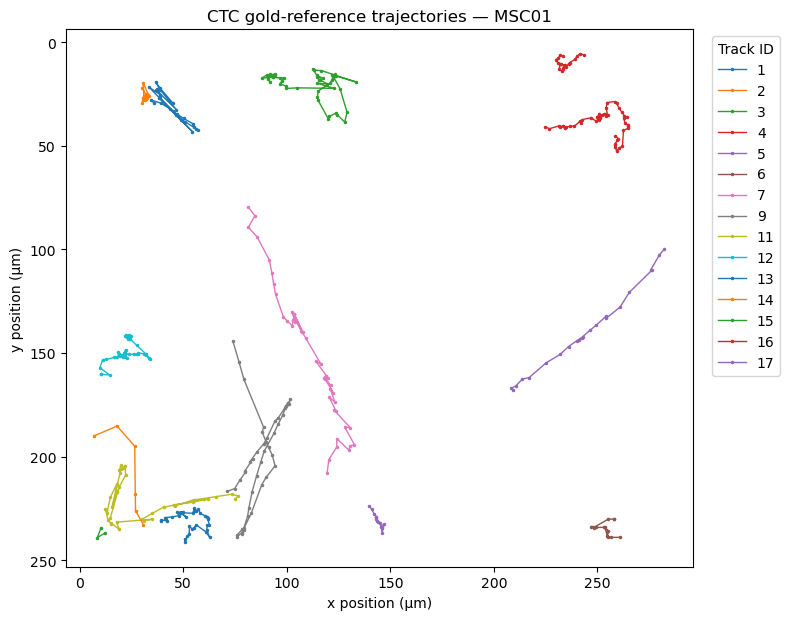

In [12]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

for track_id, group in (
    ctc_reference_tracks
    .groupby("track_id")
):

    ax.plot(
        group["x_um"],
        group["y_um"],
        marker=".",
        linewidth=1,
        markersize=3,
        label=str(track_id),
    )

ax.set_xlabel(
    "x position (µm)"
)

ax.set_ylabel(
    "y position (µm)"
)

ax.set_title(
    "CTC gold-reference trajectories — MSC01"
)

ax.set_aspect(
    "equal"
)

ax.invert_yaxis()

ax.legend(
    title="Track ID",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [13]:
TRACKMATE_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_clean.csv"
)

trackmate_tracks = pd.read_csv(
    TRACKMATE_PATH
)

print(
    "TrackMate shape:",
    trackmate_tracks.shape,
)

print(
    "\nTrackMate columns:"
)

print(
    trackmate_tracks.columns.tolist()
)

display(
    trackmate_tracks.head(10)
)

TrackMate shape: (474, 5)

TrackMate columns:
['cell_id', 'frame', 't_min', 'x_um', 'y_um']


,cell_id,frame,t_min,x_um,y_um
0,0,10,200.0,39.867660,224.393768
1,0,11,220.0,34.776408,227.566565
2,0,12,240.0,31.056212,229.721570
3,0,13,260.0,32.449259,230.256018
4,0,14,280.0,33.368621,230.260754
5,1,0,0.0,255.789912,232.878059
6,1,1,20.0,254.746064,232.889143
7,1,2,40.0,254.306492,232.719956
8,1,3,60.0,253.117025,232.841979
9,1,4,80.0,252.393917,233.327588


## CTC–TrackMate comparison strategy

The CTC reference and TrackMate tables use different track identifiers.

Therefore, track IDs cannot be compared directly.

A CTC reference trajectory may also correspond to multiple TrackMate track
fragments if the algorithm terminated and restarted a trajectory.

The comparison will therefore proceed in two stages.

### Stage 1 — frame-level spatial correspondence

At each frame, CTC reference centroids will be compared with TrackMate
detections observed at the same frame.

For a CTC point at position

$$
\mathbf{r}^{CTC}_{i,t}
$$

and a TrackMate point

$$
\mathbf{r}^{TM}_{j,t},
$$

their spatial separation is

$$
d_{ij}(t)
=
\left\|
\mathbf{r}^{CTC}_{i,t}
-
\mathbf{r}^{TM}_{j,t}
\right\|_2.
$$

Nearest-neighbour distances will first be inspected without imposing an
arbitrary matching threshold.

### Stage 2 — trajectory-level correspondence

After frame-level matches are understood, their TrackMate `cell_id` values
will be summarized across each CTC `track_id`.

This will allow us to detect:

- stable one-to-one tracking;
- fragmented TrackMate trajectories;
- missing detections;
- possible identity switches;
- and unmatched or additional TrackMate detections.

No CTC-to-TrackMate identity mapping will be assumed in advance.

In [14]:
trackmate_duplicates = (
    trackmate_tracks[
        ["cell_id", "frame"]
    ]
    .duplicated()
    .sum()
)

print(
    "TrackMate observations:",
    len(trackmate_tracks),
)

print(
    "TrackMate tracks:",
    trackmate_tracks[
        "cell_id"
    ].nunique(),
)

print(
    "TrackMate frames:",
    trackmate_tracks[
        "frame"
    ].nunique(),
)

print(
    "Duplicate (cell_id, frame) rows:",
    trackmate_duplicates,
)

print(
    "TrackMate frame range:",
    int(trackmate_tracks["frame"].min()),
    "to",
    int(trackmate_tracks["frame"].max()),
)


assert trackmate_duplicates == 0

assert np.isfinite(
    trackmate_tracks[
        [
            "frame",
            "t_min",
            "x_um",
            "y_um",
        ]
    ].to_numpy()
).all()

print(
    "TrackMate structural check: PASSED"
)

TrackMate observations: 474
TrackMate tracks: 35
TrackMate frames: 48
Duplicate (cell_id, frame) rows: 0
TrackMate frame range: 0 to 47
TrackMate structural check: PASSED


In [15]:
ctc_counts_by_frame = (
    ctc_reference_tracks
    .groupby("frame")
    .size()
    .rename("ctc_count")
)

trackmate_counts_by_frame = (
    trackmate_tracks
    .groupby("frame")
    .size()
    .rename("trackmate_count")
)

frame_count_comparison = (
    pd.concat(
        [
            ctc_counts_by_frame,
            trackmate_counts_by_frame,
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

frame_count_comparison[
    "trackmate_minus_ctc"
] = (
    frame_count_comparison[
        "trackmate_count"
    ]
    -
    frame_count_comparison[
        "ctc_count"
    ]
)

display(
    frame_count_comparison
)

print(
    "\nMean CTC objects/frame:",
    frame_count_comparison[
        "ctc_count"
    ].mean(),
)

print(
    "Mean TrackMate objects/frame:",
    frame_count_comparison[
        "trackmate_count"
    ].mean(),
)

print(
    "Mean TrackMate - CTC difference:",
    frame_count_comparison[
        "trackmate_minus_ctc"
    ].mean(),
)

,frame,ctc_count,trackmate_count,trackmate_minus_ctc
0,0,9,8,-1
1,1,9,8,-1
2,2,9,7,-2
3,3,8,9,1
4,4,8,9,1
5,5,8,9,1
6,6,8,9,1
7,7,8,9,1
8,8,8,9,1
9,9,8,8,0



Mean CTC objects/frame: 8.916666666666666
Mean TrackMate objects/frame: 9.875
Mean TrackMate - CTC difference: 0.9583333333333334


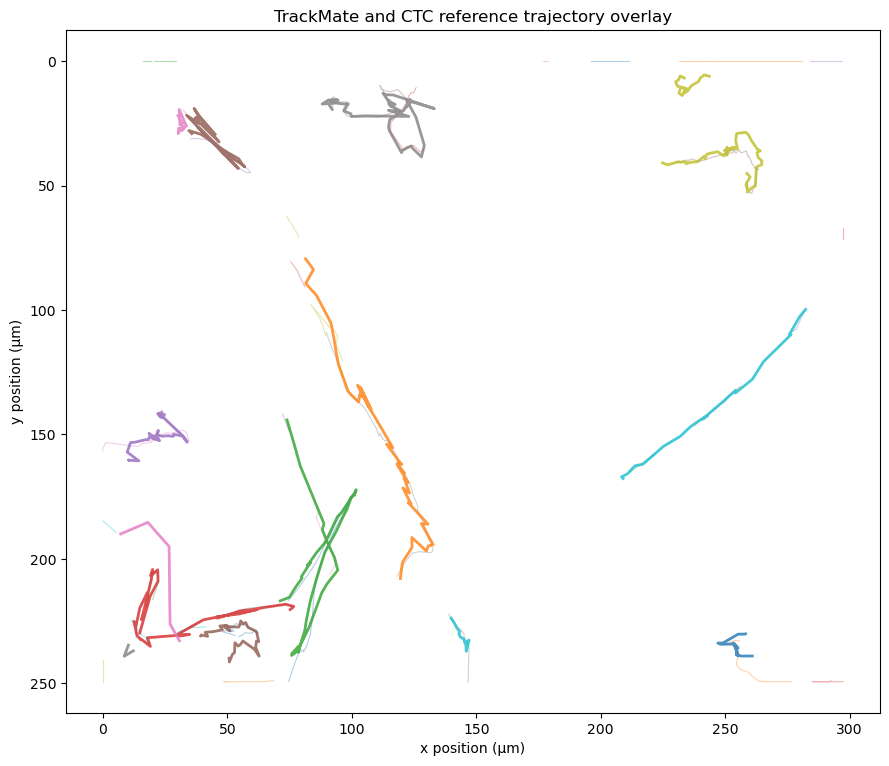

In [16]:
fig, ax = plt.subplots(
    figsize=(9, 8)
)

for _, group in (
    trackmate_tracks
    .groupby("cell_id")
):
    ax.plot(
        group["x_um"],
        group["y_um"],
        linewidth=0.8,
        alpha=0.35,
    )

for _, group in (
    ctc_reference_tracks
    .groupby("track_id")
):
    ax.plot(
        group["x_um"],
        group["y_um"],
        linewidth=2.0,
        alpha=0.8,
    )

ax.set_xlabel(
    "x position (µm)"
)

ax.set_ylabel(
    "y position (µm)"
)

ax.set_title(
    "TrackMate and CTC reference trajectory overlay"
)

ax.set_aspect(
    "equal"
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
def nearest_trackmate_matches_for_frame(
    ctc_frame,
    trackmate_frame,
):
    ctc_xy = (
        ctc_frame[
            ["x_um", "y_um"]
        ]
        .to_numpy()
    )

    trackmate_xy = (
        trackmate_frame[
            ["x_um", "y_um"]
        ]
        .to_numpy()
    )

    if len(trackmate_xy) == 0:
        return pd.DataFrame()

    coordinate_differences = (
        ctc_xy[:, None, :]
        -
        trackmate_xy[None, :, :]
    )

    distance_matrix = np.sqrt(
        np.sum(
            coordinate_differences ** 2,
            axis=2,
        )
    )

    nearest_indices = (
        np.argmin(
            distance_matrix,
            axis=1,
        )
    )

    nearest_distances = (
        distance_matrix[
            np.arange(
                len(ctc_xy)
            ),
            nearest_indices,
        ]
    )

    records = []

    for ctc_row_index, (
        nearest_index,
        distance_um,
    ) in enumerate(
        zip(
            nearest_indices,
            nearest_distances,
        )
    ):

        ctc_row = (
            ctc_frame
            .iloc[
                ctc_row_index
            ]
        )

        trackmate_row = (
            trackmate_frame
            .iloc[
                nearest_index
            ]
        )

        records.append(
            {
                "frame": int(
                    ctc_row["frame"]
                ),
                "ctc_track_id": int(
                    ctc_row["track_id"]
                ),
                "trackmate_cell_id": int(
                    trackmate_row["cell_id"]
                ),
                "ctc_x_um": float(
                    ctc_row["x_um"]
                ),
                "ctc_y_um": float(
                    ctc_row["y_um"]
                ),
                "trackmate_x_um": float(
                    trackmate_row["x_um"]
                ),
                "trackmate_y_um": float(
                    trackmate_row["y_um"]
                ),
                "distance_um": float(
                    distance_um
                ),
            }
        )

    return pd.DataFrame(
        records
    )

In [18]:
nearest_match_tables = []

common_frames = sorted(
    set(
        ctc_reference_tracks[
            "frame"
        ].unique()
    )
    &
    set(
        trackmate_tracks[
            "frame"
        ].unique()
    )
)

for frame in common_frames:

    ctc_frame = (
        ctc_reference_tracks[
            ctc_reference_tracks[
                "frame"
            ]
            == frame
        ]
        .reset_index(
            drop=True
        )
    )

    trackmate_frame = (
        trackmate_tracks[
            trackmate_tracks[
                "frame"
            ]
            == frame
        ]
        .reset_index(
            drop=True
        )
    )

    frame_matches = (
        nearest_trackmate_matches_for_frame(
            ctc_frame=ctc_frame,
            trackmate_frame=trackmate_frame,
        )
    )

    nearest_match_tables.append(
        frame_matches
    )


ctc_nearest_trackmate = pd.concat(
    nearest_match_tables,
    ignore_index=True,
)

display(
    ctc_nearest_trackmate.head(20)
)

print(
    "Reference points evaluated:",
    len(ctc_nearest_trackmate),
)

print(
    "\nNearest-distance summary (µm):"
)

display(
    ctc_nearest_trackmate[
        "distance_um"
    ].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

,frame,ctc_track_id,trackmate_cell_id,ctc_x_um,ctc_y_um,trackmate_x_um,trackmate_y_um,distance_um
0,0,1,4,35.711383,29.152859,35.263574,31.171818,2.068026
1,0,3,3,122.034783,18.321070,125.814956,10.679019,8.525881
2,0,4,5,258.678189,45.127402,258.814990,48.823354,3.698484
3,0,6,1,258.177352,230.071629,255.789912,232.878059,3.684551
4,0,7,7,119.485580,207.835711,118.243654,206.947345,1.526949
5,0,9,34,73.960959,144.174873,72.156222,141.751485,3.021570
6,0,11,17,75.225680,220.325680,76.034381,220.046813,0.855432
7,0,12,6,23.622205,141.164752,23.511274,139.972312,1.197588
8,0,15,17,10.261065,234.593609,76.034381,220.046813,67.362737
9,1,1,4,34.499335,27.897561,37.654853,31.072565,4.476377


Reference points evaluated: 428

Nearest-distance summary (µm):


count    428.000000
mean       9.982895
std       17.217899
min        0.053873
25%        1.508721
50%        3.379122
75%        9.737918
90%       25.974677
95%       61.084777
99%       79.110943
max      109.947533
Name: distance_um, dtype: float64

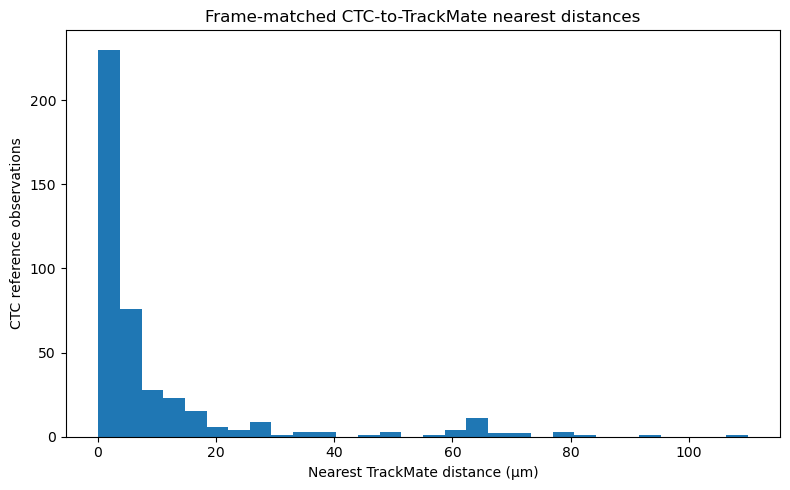

In [19]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    ctc_nearest_trackmate[
        "distance_um"
    ],
    bins=30,
)

ax.set_xlabel(
    "Nearest TrackMate distance (µm)"
)

ax.set_ylabel(
    "CTC reference observations"
)

ax.set_title(
    "Frame-matched CTC-to-TrackMate nearest distances"
)

plt.tight_layout()
plt.show()

## One-to-one frame-level assignment

Independent nearest-neighbour matching can assign the same TrackMate
detection to more than one CTC reference point.

To construct candidate correspondences, each frame is therefore treated as
a bipartite assignment problem.

For a given frame, the Euclidean distance matrix between all CTC reference
points and all TrackMate detections is constructed.

The Hungarian assignment algorithm then finds the one-to-one pairing that
minimizes the total spatial distance.

Because the number of CTC and TrackMate detections can differ, only

$$
\min(N_{CTC},N_{TM})
$$

candidate pairs are assigned in a frame.

Importantly, the assignment algorithm always returns a pairing when possible,
even if the spatial distance is very large.

Therefore, assignment does not by itself establish a valid biological match.

Candidate assignments will subsequently be evaluated using their empirical
distance distribution and multiple distance thresholds rather than accepting
all assigned pairs automatically.

In [20]:
from scipy.optimize import linear_sum_assignment

print(
    "Hungarian assignment import: PASSED"
)

Hungarian assignment import: PASSED


In [21]:
def assign_ctc_to_trackmate_for_frame(
    ctc_frame,
    trackmate_frame,
):
    if (
        len(ctc_frame) == 0
        or len(trackmate_frame) == 0
    ):
        return pd.DataFrame()

    ctc_xy = (
        ctc_frame[
            ["x_um", "y_um"]
        ]
        .to_numpy()
    )

    trackmate_xy = (
        trackmate_frame[
            ["x_um", "y_um"]
        ]
        .to_numpy()
    )

    coordinate_differences = (
        ctc_xy[:, None, :]
        -
        trackmate_xy[None, :, :]
    )

    distance_matrix = np.sqrt(
        np.sum(
            coordinate_differences ** 2,
            axis=2,
        )
    )

    ctc_indices, trackmate_indices = (
        linear_sum_assignment(
            distance_matrix
        )
    )

    records = []

    for ctc_index, trackmate_index in zip(
        ctc_indices,
        trackmate_indices,
    ):
        ctc_row = (
            ctc_frame
            .iloc[ctc_index]
        )

        trackmate_row = (
            trackmate_frame
            .iloc[trackmate_index]
        )

        records.append(
            {
                "frame": int(
                    ctc_row["frame"]
                ),
                "ctc_track_id": int(
                    ctc_row["track_id"]
                ),
                "trackmate_cell_id": int(
                    trackmate_row["cell_id"]
                ),
                "ctc_x_um": float(
                    ctc_row["x_um"]
                ),
                "ctc_y_um": float(
                    ctc_row["y_um"]
                ),
                "trackmate_x_um": float(
                    trackmate_row["x_um"]
                ),
                "trackmate_y_um": float(
                    trackmate_row["y_um"]
                ),
                "distance_um": float(
                    distance_matrix[
                        ctc_index,
                        trackmate_index,
                    ]
                ),
            }
        )

    return pd.DataFrame(
        records
    )

In [22]:
assignment_tables = []

for frame in common_frames:

    ctc_frame = (
        ctc_reference_tracks[
            ctc_reference_tracks[
                "frame"
            ]
            == frame
        ]
        .reset_index(
            drop=True
        )
    )

    trackmate_frame = (
        trackmate_tracks[
            trackmate_tracks[
                "frame"
            ]
            == frame
        ]
        .reset_index(
            drop=True
        )
    )

    frame_assignment = (
        assign_ctc_to_trackmate_for_frame(
            ctc_frame=ctc_frame,
            trackmate_frame=trackmate_frame,
        )
    )

    assignment_tables.append(
        frame_assignment
    )


ctc_trackmate_assignments = pd.concat(
    assignment_tables,
    ignore_index=True,
)

display(
    ctc_trackmate_assignments.head(20)
)

print(
    "Candidate one-to-one assignments:",
    len(ctc_trackmate_assignments),
)

print(
    "\nAssigned-distance summary (µm):"
)

display(
    ctc_trackmate_assignments[
        "distance_um"
    ].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

,frame,ctc_track_id,trackmate_cell_id,ctc_x_um,ctc_y_um,trackmate_x_um,trackmate_y_um,distance_um
0,0,1,4,35.711383,29.152859,35.263574,31.171818,2.068026
1,0,3,3,122.034783,18.321070,125.814956,10.679019,8.525881
2,0,4,5,258.678189,45.127402,258.814990,48.823354,3.698484
3,0,6,1,258.177352,230.071629,255.789912,232.878059,3.684551
4,0,7,7,119.485580,207.835711,118.243654,206.947345,1.526949
5,0,9,34,73.960959,144.174873,72.156222,141.751485,3.021570
6,0,11,17,75.225680,220.325680,76.034381,220.046813,0.855432
7,0,12,6,23.622205,141.164752,23.511274,139.972312,1.197588
8,1,1,4,34.499335,27.897561,37.654853,31.072565,4.476377
9,1,3,3,123.918557,16.292784,124.653196,12.866678,3.503983


Candidate one-to-one assignments: 420

Assigned-distance summary (µm):


count    420.000000
mean      16.993854
std       36.382363
min        0.053873
25%        1.581594
50%        3.656644
75%       11.300252
90%       60.813782
95%       88.364929
99%      188.871894
max      264.040033
Name: distance_um, dtype: float64

In [23]:
MATCH_THRESHOLDS_UM = [
    5.0,
    10.0,
    15.0,
    20.0,
]

threshold_records = []

for threshold_um in MATCH_THRESHOLDS_UM:

    accepted = (
        ctc_trackmate_assignments[
            "distance_um"
        ]
        <= threshold_um
    )

    n_matches = int(
        accepted.sum()
    )

    threshold_records.append(
        {
            "threshold_um": threshold_um,
            "accepted_matches": n_matches,
            "fraction_of_ctc_observations": (
                n_matches
                / len(ctc_reference_tracks)
            ),
            "median_distance_um": (
                ctc_trackmate_assignments.loc[
                    accepted,
                    "distance_um",
                ]
                .median()
            ),
        }
    )


threshold_summary = pd.DataFrame(
    threshold_records
)

display(
    threshold_summary
)

,threshold_um,accepted_matches,fraction_of_ctc_observations,median_distance_um
0,5.0,248,0.579439,1.887765
1,10.0,303,0.707944,2.490022
2,15.0,337,0.787383,2.803802
3,20.0,350,0.817757,2.881009


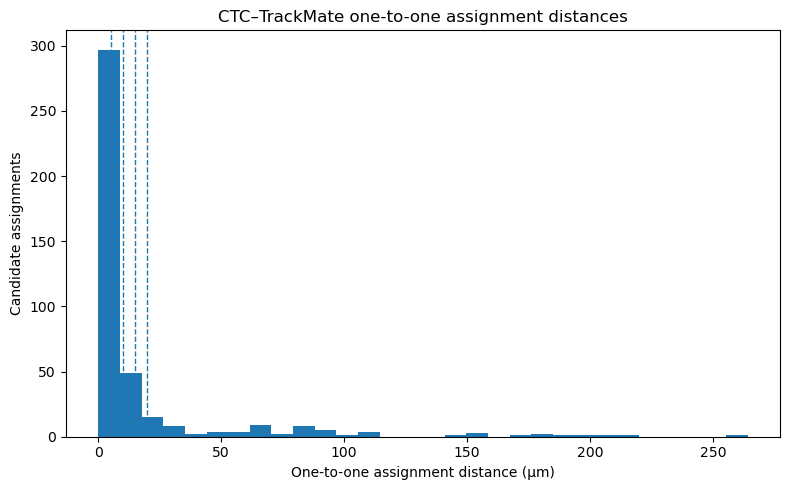

In [24]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    ctc_trackmate_assignments[
        "distance_um"
    ],
    bins=30,
)

for threshold_um in MATCH_THRESHOLDS_UM:
    ax.axvline(
        threshold_um,
        linestyle="--",
        linewidth=1,
    )

ax.set_xlabel(
    "One-to-one assignment distance (µm)"
)

ax.set_ylabel(
    "Candidate assignments"
)

ax.set_title(
    "CTC–TrackMate one-to-one assignment distances"
)

plt.tight_layout()
plt.show()

In [25]:
PRIMARY_MATCH_THRESHOLD_UM = 10.0

high_confidence_matches = (
    ctc_trackmate_assignments[
        ctc_trackmate_assignments[
            "distance_um"
        ]
        <= PRIMARY_MATCH_THRESHOLD_UM
    ]
    .copy()
)


fragmentation_summary = (
    high_confidence_matches
    .groupby("ctc_track_id")
    .agg(
        matched_observations=(
            "frame",
            "size",
        ),
        distinct_trackmate_ids=(
            "trackmate_cell_id",
            "nunique",
        ),
        median_match_distance_um=(
            "distance_um",
            "median",
        ),
    )
    .reset_index()
)


ctc_expected_counts = (
    track_metadata[
        [
            "track_id",
            "expected_observations",
        ]
    ]
    .rename(
        columns={
            "track_id": "ctc_track_id"
        }
    )
)


fragmentation_summary = (
    ctc_expected_counts
    .merge(
        fragmentation_summary,
        on="ctc_track_id",
        how="left",
    )
)


fragmentation_summary[
    "matched_observations"
] = (
    fragmentation_summary[
        "matched_observations"
    ]
    .fillna(0)
    .astype(int)
)


fragmentation_summary[
    "distinct_trackmate_ids"
] = (
    fragmentation_summary[
        "distinct_trackmate_ids"
    ]
    .fillna(0)
    .astype(int)
)


fragmentation_summary[
    "match_fraction"
] = (
    fragmentation_summary[
        "matched_observations"
    ]
    /
    fragmentation_summary[
        "expected_observations"
    ]
)


display(
    fragmentation_summary
)

,ctc_track_id,expected_observations,matched_observations,distinct_trackmate_ids,median_match_distance_um,match_fraction
0,1,27,16,1,3.000255,0.592593
1,2,20,0,0,NaN,0.000000
2,3,48,33,2,1.317266,0.687500
3,4,48,48,1,3.342821,1.000000
4,5,22,17,3,4.140221,0.772727
5,6,14,14,1,3.929563,1.000000
6,7,48,33,2,3.857974,0.687500
7,9,48,35,3,3.034054,0.729167
8,11,37,34,4,1.079125,0.918919
9,12,40,34,1,1.191785,0.850000


## Track-specific correspondence diagnostics

The global distance distribution indicates a mixture of close CTC–TrackMate
correspondences and poorly aligned candidate assignments.

A single distance threshold would therefore hide important track-level
heterogeneity.

The next analysis evaluates each CTC reference track separately.

For every CTC track we summarize:

- the number of expected observations;
- the number of candidate one-to-one assignments;
- median assignment distance;
- upper-distance quantiles;
- the fraction of observations within several candidate distance thresholds;
- and the number of distinct TrackMate track IDs represented among accepted
  matches.

This allows stable one-to-one correspondence, fragmentation, incomplete
coverage, and poor correspondence to be distinguished.

In [26]:
track_distance_summary = (
    ctc_trackmate_assignments
    .groupby("ctc_track_id")
    .agg(
        assigned_observations=(
            "frame",
            "size",
        ),
        median_distance_um=(
            "distance_um",
            "median",
        ),
        mean_distance_um=(
            "distance_um",
            "mean",
        ),
        q90_distance_um=(
            "distance_um",
            lambda x: x.quantile(0.90),
        ),
        max_distance_um=(
            "distance_um",
            "max",
        ),
    )
    .reset_index()
)

track_distance_summary = (
    ctc_expected_counts
    .merge(
        track_distance_summary,
        on="ctc_track_id",
        how="left",
    )
)

display(
    track_distance_summary
)

,ctc_track_id,expected_observations,assigned_observations,median_distance_um,mean_distance_um,q90_distance_um,max_distance_um
0,1,27,27.0,4.476377,14.586880,35.113261,51.169794
1,2,20,20.0,61.823345,59.458363,68.941213,183.149198
2,3,48,48.0,2.078796,26.231830,86.743925,113.234483
3,4,48,48.0,3.342821,3.327387,5.656539,8.008844
4,5,22,21.0,5.579796,23.502456,102.730333,157.134928
5,6,14,14.0,3.929563,3.568962,5.365808,6.704181
6,7,48,48.0,5.944780,11.461909,19.775811,177.340446
7,9,48,46.0,4.319108,26.758075,109.297207,211.802237
8,11,37,36.0,1.182867,5.008341,3.852565,90.188728
9,12,40,40.0,1.315732,13.892209,22.442575,150.833520


In [27]:
track_threshold_records = []

for ctc_track_id in sorted(
    ctc_reference_tracks[
        "track_id"
    ].unique()
):

    expected = int(
        ctc_expected_counts.loc[
            ctc_expected_counts[
                "ctc_track_id"
            ]
            == ctc_track_id,
            "expected_observations",
        ].iloc[0]
    )

    track_assignments = (
        ctc_trackmate_assignments[
            ctc_trackmate_assignments[
                "ctc_track_id"
            ]
            == ctc_track_id
        ]
    )

    record = {
        "ctc_track_id": int(
            ctc_track_id
        ),
        "expected_observations": expected,
    }

    for threshold_um in MATCH_THRESHOLDS_UM:

        accepted = (
            track_assignments[
                track_assignments[
                    "distance_um"
                ]
                <= threshold_um
            ]
        )

        record[
            f"match_fraction_le_{int(threshold_um)}um"
        ] = (
            len(accepted)
            / expected
        )

        record[
            f"trackmate_ids_le_{int(threshold_um)}um"
        ] = (
            accepted[
                "trackmate_cell_id"
            ]
            .nunique()
        )

    track_threshold_records.append(
        record
    )


track_threshold_sensitivity = (
    pd.DataFrame(
        track_threshold_records
    )
)

display(
    track_threshold_sensitivity
)

,ctc_track_id,expected_observations,match_fraction_le_5um,trackmate_ids_le_5um,match_fraction_le_10um,trackmate_ids_le_10um,match_fraction_le_15um,trackmate_ids_le_15um,match_fraction_le_20um,trackmate_ids_le_20um
0,1,27,0.555556,1,0.592593,1,0.592593,1,0.592593,1
1,2,20,0.000000,0,0.000000,0,0.000000,0,0.050000,1
2,3,48,0.666667,2,0.687500,2,0.708333,2,0.729167,2
3,4,48,0.812500,1,1.000000,1,1.000000,1,1.000000,1
4,5,22,0.409091,3,0.772727,3,0.818182,3,0.818182,3
5,6,14,0.714286,1,1.000000,1,1.000000,1,1.000000,1
6,7,48,0.458333,2,0.687500,2,0.791667,2,0.916667,2
7,9,48,0.541667,3,0.729167,3,0.812500,3,0.812500,3
8,11,37,0.891892,4,0.918919,4,0.918919,4,0.918919,4
9,12,40,0.825000,1,0.850000,1,0.900000,1,0.900000,1


In [28]:
accepted_10um = (
    ctc_trackmate_assignments[
        ctc_trackmate_assignments[
            "distance_um"
        ]
        <= 10.0
    ]
    .copy()
)


ctc_to_trackmate_identity = (
    accepted_10um
    .groupby(
        [
            "ctc_track_id",
            "trackmate_cell_id",
        ]
    )
    .agg(
        first_matched_frame=(
            "frame",
            "min",
        ),
        last_matched_frame=(
            "frame",
            "max",
        ),
        matched_frames=(
            "frame",
            "size",
        ),
        median_distance_um=(
            "distance_um",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "ctc_track_id",
            "first_matched_frame",
        ]
    )
)

display(
    ctc_to_trackmate_identity
)

,ctc_track_id,trackmate_cell_id,first_matched_frame,last_matched_frame,matched_frames,median_distance_um
0,1,4,0,18,16,3.000255
1,3,3,0,14,15,1.663544
2,3,15,16,44,18,1.290643
3,4,5,0,47,48,3.342821
4,5,24,27,29,3,2.600283
5,5,25,32,41,9,6.291566
6,5,32,43,47,5,4.140221
7,6,1,0,13,14,3.929563
8,7,7,0,43,30,3.776421
9,7,33,45,47,3,6.090101


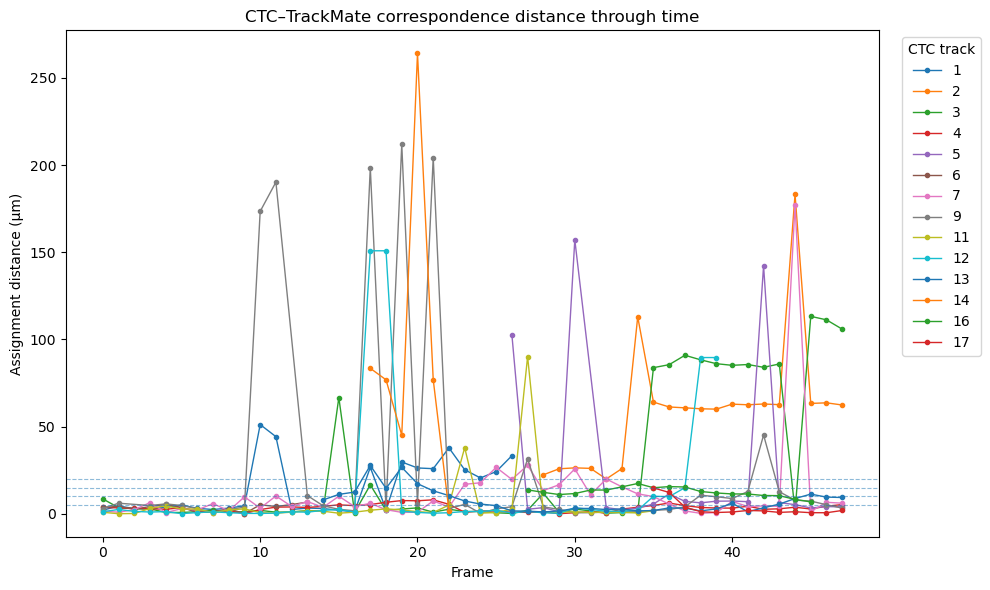

In [29]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for ctc_track_id, group in (
    ctc_trackmate_assignments
    .groupby("ctc_track_id")
):

    ax.plot(
        group["frame"],
        group["distance_um"],
        marker=".",
        linewidth=1,
        label=str(ctc_track_id),
    )

for threshold_um in MATCH_THRESHOLDS_UM:
    ax.axhline(
        threshold_um,
        linestyle="--",
        linewidth=0.8,
        alpha=0.5,
    )

ax.set_xlabel(
    "Frame"
)

ax.set_ylabel(
    "Assignment distance (µm)"
)

ax.set_title(
    "CTC–TrackMate correspondence distance through time"
)

ax.legend(
    title="CTC track",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

## Temporal continuity of CTC–TrackMate correspondence

Multiple TrackMate IDs associated with one CTC reference track do not
automatically prove trajectory fragmentation.

A stronger fragmentation pattern occurs when different TrackMate IDs match
the same CTC trajectory during consecutive or nearly consecutive temporal
intervals.

The correspondence analysis therefore distinguishes:

- stable one-to-one correspondence;
- candidate fragmentation with temporally ordered TrackMate segments;
- incomplete or missing correspondence;
- and systematic spatial offsets between CTC tracking markers and TrackMate
  detections.

Because CTC tracking annotations provide reference track identities but only
limited cell-region information, spatial centroid differences are interpreted
cautiously.

Both strict (`10 µm`) and moderate (`15 µm`) correspondence thresholds are
retained as sensitivity diagnostics rather than treated as absolute biological
matching boundaries.

In [30]:
def summarize_identity_at_threshold(
    assignments,
    expected_counts,
    threshold_um,
):
    accepted = (
        assignments[
            assignments[
                "distance_um"
            ]
            <= threshold_um
        ]
        .copy()
    )

    records = []

    for ctc_track_id in sorted(
        expected_counts[
            "ctc_track_id"
        ].unique()
    ):

        expected = int(
            expected_counts.loc[
                expected_counts[
                    "ctc_track_id"
                ]
                == ctc_track_id,
                "expected_observations",
            ].iloc[0]
        )

        track_matches = (
            accepted[
                accepted[
                    "ctc_track_id"
                ]
                == ctc_track_id
            ]
        )

        if len(track_matches) == 0:

            records.append(
                {
                    "ctc_track_id": int(
                        ctc_track_id
                    ),
                    "threshold_um": threshold_um,
                    "matched_observations": 0,
                    "match_fraction": 0.0,
                    "distinct_trackmate_ids": 0,
                    "dominant_trackmate_id": np.nan,
                    "dominant_id_matches": 0,
                    "dominant_id_fraction_of_matches": np.nan,
                    "median_distance_um": np.nan,
                }
            )

            continue

        id_counts = (
            track_matches[
                "trackmate_cell_id"
            ]
            .value_counts()
        )

        dominant_id = int(
            id_counts.index[0]
        )

        dominant_count = int(
            id_counts.iloc[0]
        )

        records.append(
            {
                "ctc_track_id": int(
                    ctc_track_id
                ),
                "threshold_um": threshold_um,
                "matched_observations": len(
                    track_matches
                ),
                "match_fraction": (
                    len(track_matches)
                    / expected
                ),
                "distinct_trackmate_ids": (
                    track_matches[
                        "trackmate_cell_id"
                    ]
                    .nunique()
                ),
                "dominant_trackmate_id": dominant_id,
                "dominant_id_matches": dominant_count,
                "dominant_id_fraction_of_matches": (
                    dominant_count
                    / len(track_matches)
                ),
                "median_distance_um": (
                    track_matches[
                        "distance_um"
                    ]
                    .median()
                ),
            }
        )

    return pd.DataFrame(
        records
    )

In [31]:
identity_summary_10um = (
    summarize_identity_at_threshold(
        assignments=ctc_trackmate_assignments,
        expected_counts=ctc_expected_counts,
        threshold_um=10.0,
    )
)

identity_summary_15um = (
    summarize_identity_at_threshold(
        assignments=ctc_trackmate_assignments,
        expected_counts=ctc_expected_counts,
        threshold_um=15.0,
    )
)

identity_threshold_comparison = (
    pd.concat(
        [
            identity_summary_10um,
            identity_summary_15um,
        ],
        ignore_index=True,
    )
)

display(
    identity_threshold_comparison
)

,ctc_track_id,threshold_um,matched_observations,match_fraction,distinct_trackmate_ids,dominant_trackmate_id,dominant_id_matches,dominant_id_fraction_of_matches,median_distance_um
0,1,10.0,16,0.592593,1,4.0,16,1.000000,3.000255
1,2,10.0,0,0.000000,0,NaN,0,NaN,NaN
2,3,10.0,33,0.687500,2,15.0,18,0.545455,1.317266
3,4,10.0,48,1.000000,1,5.0,48,1.000000,3.342821
4,5,10.0,17,0.772727,3,25.0,9,0.529412,4.140221
5,6,10.0,14,1.000000,1,1.0,14,1.000000,3.929563
6,7,10.0,33,0.687500,2,7.0,30,0.909091,3.857974
7,9,10.0,35,0.729167,3,10.0,26,0.742857,3.034054
8,11,10.0,34,0.918919,4,22.0,11,0.323529,1.079125
9,12,10.0,34,0.850000,1,6.0,34,1.000000,1.191785


In [32]:
def summarize_contiguous_match_runs(
    assignments,
    threshold_um,
):
    accepted = (
        assignments[
            assignments[
                "distance_um"
            ]
            <= threshold_um
        ]
        .sort_values(
            [
                "ctc_track_id",
                "trackmate_cell_id",
                "frame",
            ]
        )
        .copy()
    )

    run_records = []

    for (
        ctc_track_id,
        trackmate_cell_id,
    ), group in accepted.groupby(
        [
            "ctc_track_id",
            "trackmate_cell_id",
        ]
    ):

        frames = (
            group["frame"]
            .astype(int)
            .sort_values()
            .tolist()
        )

        if len(frames) == 0:
            continue

        run_start = frames[0]
        previous_frame = frames[0]

        for frame in frames[1:]:

            if frame != previous_frame + 1:

                run_records.append(
                    {
                        "ctc_track_id": int(
                            ctc_track_id
                        ),
                        "trackmate_cell_id": int(
                            trackmate_cell_id
                        ),
                        "run_start_frame": int(
                            run_start
                        ),
                        "run_end_frame": int(
                            previous_frame
                        ),
                        "run_length": int(
                            previous_frame
                            - run_start
                            + 1
                        ),
                    }
                )

                run_start = frame

            previous_frame = frame

        run_records.append(
            {
                "ctc_track_id": int(
                    ctc_track_id
                ),
                "trackmate_cell_id": int(
                    trackmate_cell_id
                ),
                "run_start_frame": int(
                    run_start
                ),
                "run_end_frame": int(
                    previous_frame
                ),
                "run_length": int(
                    previous_frame
                    - run_start
                    + 1
                ),
            }
        )

    return (
        pd.DataFrame(
            run_records
        )
        .sort_values(
            [
                "ctc_track_id",
                "run_start_frame",
                "trackmate_cell_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

In [33]:
match_runs_10um = (
    summarize_contiguous_match_runs(
        assignments=ctc_trackmate_assignments,
        threshold_um=10.0,
    )
)

display(
    match_runs_10um
)

,ctc_track_id,trackmate_cell_id,run_start_frame,run_end_frame,run_length
0,1,4,0,9,10
1,1,4,12,16,5
2,1,4,18,18,1
3,3,3,0,14,15
4,3,15,16,16,1
5,3,15,18,27,10
6,3,15,29,34,6
7,3,15,44,44,1
8,4,5,0,47,48
9,5,24,27,29,3


In [34]:
candidate_fragmented_ctc_ids = (
    identity_summary_10um.loc[
        identity_summary_10um[
            "distinct_trackmate_ids"
        ]
        > 1,
        "ctc_track_id",
    ]
    .astype(int)
    .tolist()
)

print(
    "Candidate fragmented CTC tracks:",
    candidate_fragmented_ctc_ids,
)

candidate_fragmentation_runs = (
    match_runs_10um[
        match_runs_10um[
            "ctc_track_id"
        ]
        .isin(
            candidate_fragmented_ctc_ids
        )
    ]
)

display(
    candidate_fragmentation_runs
)

Candidate fragmented CTC tracks: [3, 5, 7, 9, 11, 13]


,ctc_track_id,trackmate_cell_id,run_start_frame,run_end_frame,run_length
3,3,3,0,14,15
4,3,15,16,16,1
5,3,15,18,27,10
6,3,15,29,34,6
7,3,15,44,44,1
9,5,24,27,29,3
10,5,25,32,35,4
11,5,25,37,41,5
12,5,32,43,47,5
14,7,7,0,10,11


## Targeted visual audit of correspondence patterns

The numerical correspondence analysis identified several qualitatively
different cases.

A small targeted visual audit is performed before closing the tracking
comparison section.

Four representative cases are examined:

1. **CTC track 4** — strong one-to-one correspondence;
2. **CTC track 11** — strong candidate TrackMate fragmentation;
3. **CTC track 16** — probable systematic centroid/localization offset;
4. **CTC track 2** — poor or absent correspondence.

This audit is not used to redefine thresholds or select favourable examples.

Its purpose is only to verify that the numerical correspondence patterns are
consistent with the underlying microscopy images and tracking annotations.

In [35]:
RAW_SEQUENCE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Fluo-C2DL-MSC"
    / "01"
)

raw_image_paths = sorted(
    RAW_SEQUENCE_DIR.glob("*.tif")
)

print(
    "Raw image files:",
    len(raw_image_paths),
)

print(
    "First five files:"
)

for path in raw_image_paths[:5]:
    print(
        path.name
    )

print(
    "Last five files:"
)

for path in raw_image_paths[-5:]:
    print(
        path.name
    )

Raw image files: 48
First five files:
t000.tif
t001.tif
t002.tif
t003.tif
t004.tif
Last five files:
t043.tif
t044.tif
t045.tif
t046.tif
t047.tif


In [36]:
def show_correspondence_frame(
    frame,
    ctc_track_id,
    trackmate_cell_id=None,
):

    raw_path = raw_image_paths[
        frame
    ]

    tracking_mask_path = (
        CTC_TRA_DIR
        / f"man_track{frame:03d}.tif"
    )

    raw_image = np.array(
        Image.open(raw_path)
    )

    tracking_mask = np.array(
        Image.open(
            tracking_mask_path
        )
    )

    lower = np.percentile(
        raw_image,
        1
    )

    upper = np.percentile(
        raw_image,
        99
    )

    fig, ax = plt.subplots(
        figsize=(8, 7)
    )

    ax.imshow(
        raw_image,
        cmap="gray",
        vmin=lower,
        vmax=upper,
    )

    ctc_region = (
        tracking_mask
        == ctc_track_id
    )

    ax.contour(
        ctc_region,
        levels=[0.5],
        linewidths=2,
    )

    ctc_point = (
        ctc_reference_tracks[
            (
                ctc_reference_tracks[
                    "track_id"
                ]
                == ctc_track_id
            )
            &
            (
                ctc_reference_tracks[
                    "frame"
                ]
                == frame
            )
        ]
    )

    if len(ctc_point) == 1:

        x_px = (
            ctc_point.iloc[0][
                "x_px"
            ]
        )

        y_px = (
            ctc_point.iloc[0][
                "y_px"
            ]
        )

        ax.scatter(
            x_px,
            y_px,
            marker="x",
            s=80,
            label="CTC centroid",
        )

    if trackmate_cell_id is not None:

        tm_point = (
            trackmate_tracks[
                (
                    trackmate_tracks[
                        "cell_id"
                    ]
                    == trackmate_cell_id
                )
                &
                (
                    trackmate_tracks[
                        "frame"
                    ]
                    == frame
                )
            ]
        )

        if len(tm_point) == 1:

            tm_x_px = (
                tm_point.iloc[0][
                    "x_um"
                ]
                / PIXEL_SIZE_UM
            )

            tm_y_px = (
                tm_point.iloc[0][
                    "y_um"
                ]
                / PIXEL_SIZE_UM
            )

            ax.scatter(
                tm_x_px,
                tm_y_px,
                marker="+",
                s=100,
                label=(
                    f"TrackMate {trackmate_cell_id}"
                ),
            )

    ax.set_title(
        (
            f"Frame {frame} — "
            f"CTC track {ctc_track_id}"
        )
    )

    ax.set_axis_off()

    ax.legend()

    plt.tight_layout()
    plt.show()

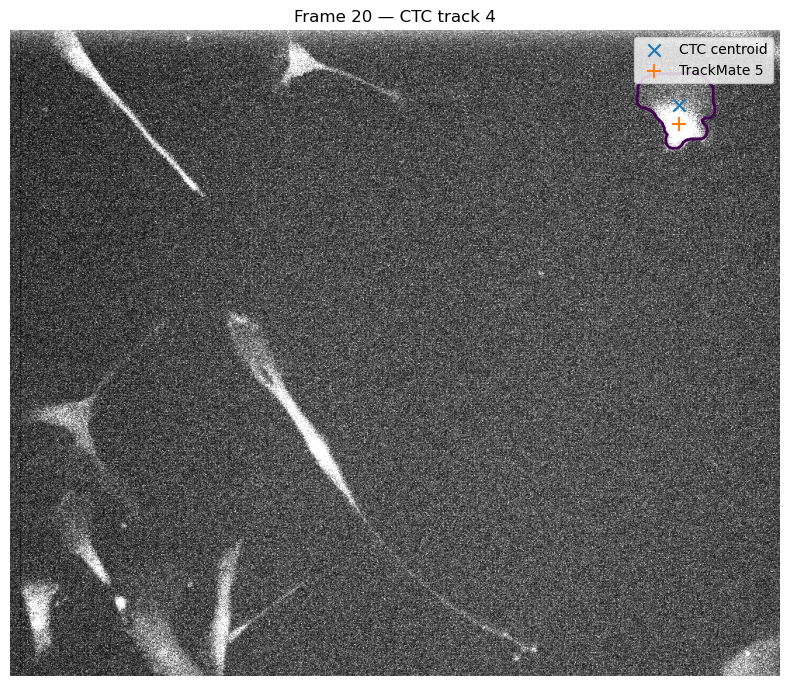

In [37]:
show_correspondence_frame(
    frame=20,
    ctc_track_id=4,
    trackmate_cell_id=5,
)

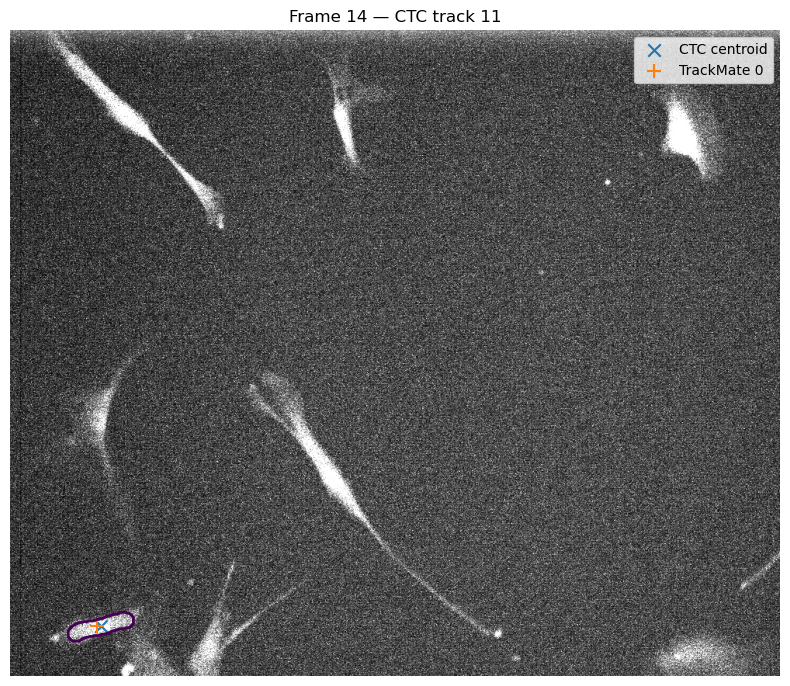

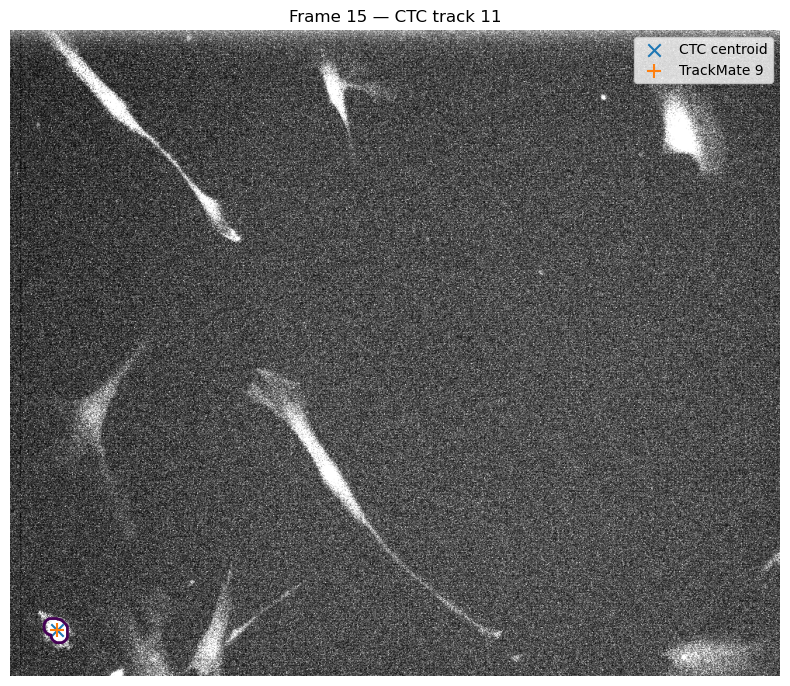

In [38]:
show_correspondence_frame(
    frame=14,
    ctc_track_id=11,
    trackmate_cell_id=0,
)

show_correspondence_frame(
    frame=15,
    ctc_track_id=11,
    trackmate_cell_id=9,
)

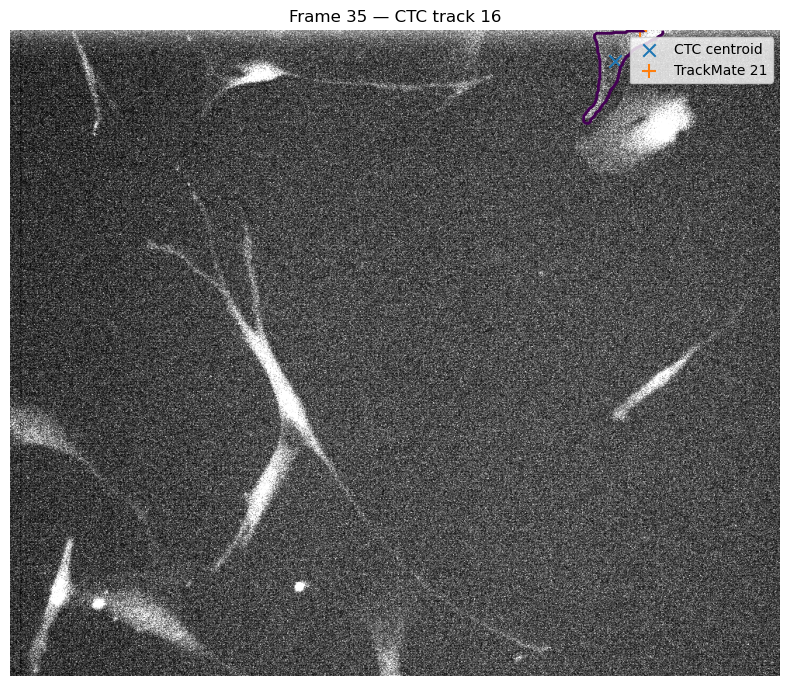

In [39]:
show_correspondence_frame(
    frame=35,
    ctc_track_id=16,
    trackmate_cell_id=21,
)

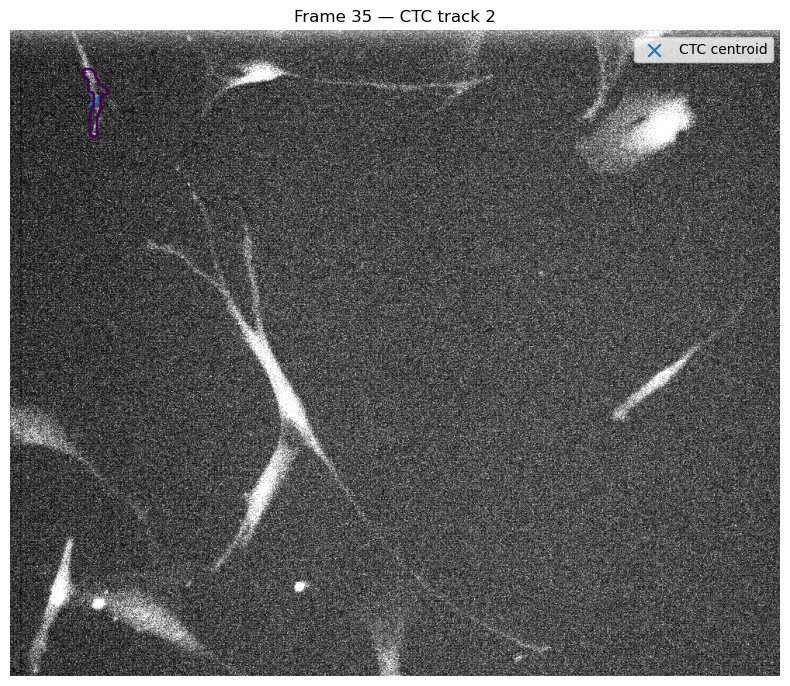

In [40]:
show_correspondence_frame(
    frame=35,
    ctc_track_id=2,
)

## Tracking-correspondence conclusion

The CTC–TrackMate comparison revealed substantial but heterogeneous
agreement between the two tracking sources.

Several CTC reference trajectories showed strong one-to-one correspondence
with a single TrackMate trajectory, while others were represented by
multiple temporally ordered TrackMate IDs.

Targeted visual inspection supported the interpretation that at least some
of these multi-ID cases reflect TrackMate trajectory fragmentation or
restart events rather than distinct biological cells.

The comparison also identified cases in which CTC tracking-marker centroids
and TrackMate spot locations were systematically offset despite apparently
referring to the same biological object. Therefore, spatial matching
thresholds are treated as diagnostic sensitivity parameters rather than
absolute definitions of tracking correctness.

Overall, the difference between 15 CTC reference tracks and 35 cleaned
TrackMate tracks cannot be explained simply by a difference in the number
of cells present in each frame. Track fragmentation, incomplete
correspondence, localization differences, and additional/missing detections
all contribute.

The remainder of Phase 8A therefore treats the two trajectory sources
independently.

The central question is no longer whether every TrackMate ID can be mapped
perfectly to a CTC ID, but whether the major biophysical conclusions obtained
from the TrackMate trajectories are reproduced when the CTC gold-reference
tracking source is analyzed using the same computational framework.

In [41]:
ctc_tracks_analysis = (
    ctc_reference_tracks[
        [
            "track_id",
            "frame",
            "time_min",
            "x_um",
            "y_um",
        ]
    ]
    .rename(
        columns={
            "track_id": "cell_id",
            "time_min": "t_min",
        }
    )
    .sort_values(
        [
            "cell_id",
            "frame",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    ctc_tracks_analysis.head(10)
)

print(
    "CTC analysis rows:",
    len(ctc_tracks_analysis),
)

print(
    "CTC analysis cells:",
    ctc_tracks_analysis[
        "cell_id"
    ].nunique(),
)

print(
    "CTC analysis frames:",
    ctc_tracks_analysis[
        "frame"
    ].nunique(),
)

,cell_id,frame,t_min,x_um,y_um
0,1,0,0.0,35.711383,29.152859
1,1,1,20.0,34.499335,27.897561
2,1,2,40.0,39.332202,29.401666
3,1,3,60.0,43.594801,32.116121
4,1,4,80.0,46.856155,34.619543
5,1,5,100.0,50.232445,36.783355
6,1,6,120.0,54.556766,39.241301
7,1,7,140.0,56.157556,41.614667
8,1,8,160.0,57.014424,42.499029
9,1,9,180.0,55.158469,41.021336


CTC analysis rows: 428
CTC analysis cells: 15
CTC analysis frames: 48


In [42]:
import inspect

from src.steps import (
    validate_tracks,
    compute_steps_for_tau,
    compute_steps_multi_tau,
)

print(
    "validate_tracks:",
    inspect.signature(
        validate_tracks
    ),
)

print(
    "compute_steps_for_tau:",
    inspect.signature(
        compute_steps_for_tau
    ),
)

print(
    "compute_steps_multi_tau:",
    inspect.signature(
        compute_steps_multi_tau
    ),
)

validate_tracks: (tracks: 'pd.DataFrame') -> 'None'
compute_steps_for_tau: (tracks: 'pd.DataFrame', tau_frames: 'int') -> 'pd.DataFrame'
compute_steps_multi_tau: (tracks: 'pd.DataFrame', taus: 'list[int]') -> 'pd.DataFrame'


In [43]:
validate_tracks(
    ctc_tracks_analysis
)

print(
    "CTC analysis-table validation: PASSED"
)

CTC analysis-table validation: PASSED


## Exact-lag displacement reconstruction from CTC reference tracks

The CTC reference trajectories are now passed through the same tested
exact-lag displacement implementation used in Phase 3.

For a trajectory position

$$
\mathbf{r}(t),
$$

the displacement at lag $\tau$ is

$$
\Delta_{\tau}\mathbf{r}(t)
=
\mathbf{r}(t+\tau)-\mathbf{r}(t).
$$

The analysis uses

$$
\tau \in \{1,2,4\}\ \text{frames},
$$

corresponding to

$$
20,\ 40,\ 80\ \text{minutes}.
$$

The implementation matches observations by exact frame number rather than
by row position.

This distinction is essential when trajectories contain missing frames or
different track durations.

Using the identical displacement code for both TrackMate-derived and CTC
reference trajectories isolates the tracking source as the main variable
being compared.

In [44]:
CTC_TAUS = [
    1,
    2,
    4,
]

ctc_steps_tau124 = (
    compute_steps_multi_tau(
        tracks=ctc_tracks_analysis,
        taus=CTC_TAUS,
    )
)

print(
    "CTC multi-tau step table shape:",
    ctc_steps_tau124.shape,
)

print(
    "\nColumns:"
)

print(
    ctc_steps_tau124.columns.tolist()
)

display(
    ctc_steps_tau124.head(15)
)

CTC multi-tau step table shape: (1180, 9)

Columns:
['cell_id', 'frame_start', 't_start_min', 'frame_end', 't_end_min', 'dx_um', 'dy_um', 'tau_frames', 'tau_min']


,cell_id,frame_start,t_start_min,frame_end,t_end_min,dx_um,dy_um,tau_frames,tau_min
0,1,0,0.0,1,20.0,-1.212048,-1.255298,1,20.0
1,1,1,20.0,2,40.0,4.832868,1.504105,1,20.0
2,1,2,40.0,3,60.0,4.262599,2.714456,1,20.0
3,1,3,60.0,4,80.0,3.261353,2.503422,1,20.0
4,1,4,80.0,5,100.0,3.376290,2.163812,1,20.0
5,1,5,100.0,6,120.0,4.324322,2.457946,1,20.0
6,1,6,120.0,7,140.0,1.600789,2.373366,1,20.0
7,1,7,140.0,8,160.0,0.856869,0.884362,1,20.0
8,1,8,160.0,9,180.0,-1.855955,-1.477693,1,20.0
9,1,9,180.0,10,200.0,-4.270475,-2.593230,1,20.0


In [45]:
print(
    "Data types:"
)

display(
    ctc_steps_tau124.dtypes
)

print(
    "\nFirst rows:"
)

display(
    ctc_steps_tau124.head()
)

print(
    "\nLast rows:"
)

display(
    ctc_steps_tau124.tail()
)

Data types:


cell_id          int64
frame_start      int64
t_start_min    float64
frame_end        int64
t_end_min      float64
dx_um          float64
dy_um          float64
tau_frames       int64
tau_min        float64
dtype: object


First rows:


,cell_id,frame_start,t_start_min,frame_end,t_end_min,dx_um,dy_um,tau_frames,tau_min
0,1,0,0.0,1,20.0,-1.212048,-1.255298,1,20.0
1,1,1,20.0,2,40.0,4.832868,1.504105,1,20.0
2,1,2,40.0,3,60.0,4.262599,2.714456,1,20.0
3,1,3,60.0,4,80.0,3.261353,2.503422,1,20.0
4,1,4,80.0,5,100.0,3.376290,2.163812,1,20.0



Last rows:


,cell_id,frame_start,t_start_min,frame_end,t_end_min,dx_um,dy_um,tau_frames,tau_min
1175,17,39,780.0,43,860.0,-1.729786,-2.817887,4,80.0
1176,17,40,800.0,44,880.0,-0.929929,-2.520358,4,80.0
1177,17,41,820.0,45,900.0,-1.305164,-3.526392,4,80.0
1178,17,42,840.0,46,920.0,-1.995748,-4.463473,4,80.0
1179,17,43,860.0,47,940.0,-3.418331,-5.586688,4,80.0


## Exact-lag count validation

Because every reconstructed CTC reference track contains a continuous sequence
of frames between its annotated start and end times, the expected number of
exact-lag displacements can be calculated analytically.

For a track containing \(N\) observations, the number of valid displacements
at lag \(\tau\) is

$$
N_{\tau}
=
\max(N-\tau,0).
$$

For example, a track containing 27 observations contributes

$$
26,\ 25,\ 23
$$

steps at lags

$$
\tau=1,\ 2,\ 4,
$$

respectively.

The analytically expected counts will now be compared with the output of the
tested exact-frame displacement implementation.

In [46]:
expected_ctc_step_records = []

for tau in CTC_TAUS:

    expected_count = (
        track_metadata[
            "expected_observations"
        ]
        .apply(
            lambda n: max(
                int(n) - tau,
                0,
            )
        )
        .sum()
    )

    expected_ctc_step_records.append(
        {
            "tau_frames": tau,
            "tau_min": (
                tau
                * FRAME_INTERVAL_MIN
            ),
            "expected_steps": int(
                expected_count
            ),
        }
    )


expected_ctc_steps = pd.DataFrame(
    expected_ctc_step_records
)


observed_ctc_steps = (
    ctc_steps_tau124
    .groupby(
        [
            "tau_frames",
            "tau_min",
        ]
    )
    .size()
    .rename(
        "observed_steps"
    )
    .reset_index()
)


ctc_step_count_validation = (
    expected_ctc_steps
    .merge(
        observed_ctc_steps,
        on=[
            "tau_frames",
            "tau_min",
        ],
        how="left",
    )
)


ctc_step_count_validation[
    "count_matches"
] = (
    ctc_step_count_validation[
        "expected_steps"
    ]
    ==
    ctc_step_count_validation[
        "observed_steps"
    ]
)


display(
    ctc_step_count_validation
)

print(
    "Total expected steps:",
    ctc_step_count_validation[
        "expected_steps"
    ].sum(),
)

print(
    "Total observed steps:",
    len(
        ctc_steps_tau124
    ),
)

,tau_frames,tau_min,expected_steps,observed_steps,count_matches
0,1,20,413,413,True
1,2,40,398,398,True
2,4,80,369,369,True


Total expected steps: 1180
Total observed steps: 1180


In [47]:
frame_lag_error = (
    ctc_steps_tau124[
        "frame_end"
    ]
    -
    ctc_steps_tau124[
        "frame_start"
    ]
    -
    ctc_steps_tau124[
        "tau_frames"
    ]
)


time_lag_error = (
    ctc_steps_tau124[
        "t_end_min"
    ]
    -
    ctc_steps_tau124[
        "t_start_min"
    ]
    -
    ctc_steps_tau124[
        "tau_min"
    ]
)


tau_conversion_error = (
    ctc_steps_tau124[
        "tau_min"
    ]
    -
    (
        ctc_steps_tau124[
            "tau_frames"
        ]
        * FRAME_INTERVAL_MIN
    )
)


print(
    "Frame-lag mismatches:",
    int(
        (
            frame_lag_error != 0
        ).sum()
    ),
)

print(
    "Time-lag mismatches:",
    int(
        (
            time_lag_error != 0
        ).sum()
    ),
)

print(
    "Tau-conversion mismatches:",
    int(
        (
            tau_conversion_error != 0
        ).sum()
    ),
)


assert (
    ctc_step_count_validation[
        "count_matches"
    ]
    .all()
)

assert (
    frame_lag_error == 0
).all()

assert np.allclose(
    time_lag_error,
    0.0,
)

assert np.allclose(
    tau_conversion_error,
    0.0,
)

assert len(
    ctc_steps_tau124
) == 1180

print(
    "CTC exact-lag validation: PASSED"
)

Frame-lag mismatches: 0
Time-lag mismatches: 0
Tau-conversion mismatches: 0
CTC exact-lag validation: PASSED


In [48]:
TRACKMATE_STEPS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_steps_tau124.csv"
)

trackmate_steps_tau124 = pd.read_csv(
    TRACKMATE_STEPS_PATH
)


trackmate_step_counts = (
    trackmate_steps_tau124
    .groupby("tau_frames")
    .size()
    .rename(
        "trackmate_steps"
    )
    .reset_index()
)


ctc_step_counts = (
    ctc_steps_tau124
    .groupby("tau_frames")
    .size()
    .rename(
        "ctc_reference_steps"
    )
    .reset_index()
)


step_source_comparison = (
    ctc_step_counts
    .merge(
        trackmate_step_counts,
        on="tau_frames",
        how="outer",
    )
)


step_source_comparison[
    "ctc_minus_trackmate"
] = (
    step_source_comparison[
        "ctc_reference_steps"
    ]
    -
    step_source_comparison[
        "trackmate_steps"
    ]
)


display(
    step_source_comparison
)

print(
    "CTC total steps:",
    len(ctc_steps_tau124),
)

print(
    "TrackMate total steps:",
    len(trackmate_steps_tau124),
)

,tau_frames,ctc_reference_steps,trackmate_steps,ctc_minus_trackmate
0,1,413,433,-20
1,2,398,398,0
2,4,369,343,26


CTC total steps: 1180
TrackMate total steps: 1174


In [49]:
def summarize_steps_by_tau(
    steps,
    source_name,
):
    summary = (
        steps
        .groupby(
            "tau_frames"
        )
        .agg(
            n_steps=(
                "dx_um",
                "size",
            ),
            mean_dx_um=(
                "dx_um",
                "mean",
            ),
            median_dx_um=(
                "dx_um",
                "median",
            ),
            mean_dy_um=(
                "dy_um",
                "mean",
            ),
            median_dy_um=(
                "dy_um",
                "median",
            ),
        )
        .reset_index()
    )

    summary.insert(
        0,
        "source",
        source_name,
    )

    return summary

In [50]:
ctc_raw_step_summary = (
    summarize_steps_by_tau(
        ctc_steps_tau124,
        "CTC reference",
    )
)

trackmate_raw_step_summary = (
    summarize_steps_by_tau(
        trackmate_steps_tau124,
        "TrackMate",
    )
)


raw_step_source_summary = (
    pd.concat(
        [
            ctc_raw_step_summary,
            trackmate_raw_step_summary,
        ],
        ignore_index=True,
    )
)


display(
    raw_step_source_summary
)

,source,tau_frames,n_steps,mean_dx_um,median_dx_um,mean_dy_um,median_dy_um
0,CTC reference,1,413,-0.698024,-0.423340,-0.016890,0.149625
1,CTC reference,2,398,-1.430406,-1.089134,-0.113559,0.186781
2,CTC reference,4,369,-2.917329,-2.044786,-0.290467,0.080871
3,TrackMate,1,433,-0.449440,-0.483247,-0.064475,0.000000
4,TrackMate,2,398,-0.885750,-1.043047,-0.273071,0.000000
5,TrackMate,4,343,-1.686608,-1.747158,-0.772733,0.000000


## Common-motion analysis of CTC reference trajectories

Earlier analysis of the TrackMate trajectories identified a population-level
directional component shared across cells.

To determine whether this component depends on the TrackMate reconstruction,
the same common-motion estimator is now applied independently to the CTC
reference trajectories.

For each one-frame transition \(t \rightarrow t+1\), the population common
displacement is estimated using the component-wise median across all
available cell displacements:

$$
\mathbf{c}(t)
=
\left(
\operatorname{median}_i \Delta x_i(t),
\operatorname{median}_i \Delta y_i(t)
\right).
$$

The median is used because it is less sensitive than the mean to individual
cells with unusually large displacements.

This common-motion estimate does not by itself distinguish microscope/stage
drift from collective biological migration.

It is therefore interpreted only as a population-level shared translation.

In [51]:
def estimate_framewise_common_motion(
    steps_tau1,
):
    common_motion = (
        steps_tau1
        .groupby(
            [
                "frame_start",
                "frame_end",
            ]
        )
        .agg(
            common_dx_um=(
                "dx_um",
                "median",
            ),
            common_dy_um=(
                "dy_um",
                "median",
            ),
            n_cells=(
                "cell_id",
                "nunique",
            ),
        )
        .reset_index()
        .sort_values(
            "frame_start"
        )
        .reset_index(
            drop=True
        )
    )

    return common_motion

In [52]:
ctc_steps_tau1 = (
    ctc_steps_tau124[
        ctc_steps_tau124[
            "tau_frames"
        ]
        == 1
    ]
    .copy()
)

trackmate_steps_tau1 = (
    trackmate_steps_tau124[
        trackmate_steps_tau124[
            "tau_frames"
        ]
        == 1
    ]
    .copy()
)


ctc_common_motion = (
    estimate_framewise_common_motion(
        ctc_steps_tau1
    )
)

trackmate_common_motion = (
    estimate_framewise_common_motion(
        trackmate_steps_tau1
    )
)


print(
    "CTC transitions:",
    len(ctc_common_motion),
)

print(
    "TrackMate transitions:",
    len(trackmate_common_motion),
)

display(
    ctc_common_motion.head(10)
)

CTC transitions: 47
TrackMate transitions: 47


,frame_start,frame_end,common_dx_um,common_dy_um,n_cells
0,0,1,0.821216,0.110425,9
1,1,2,0.474337,-0.870919,9
2,2,3,-1.014666,1.524578,8
3,3,4,0.010185,1.149877,8
4,4,5,0.203566,0.529173,8
5,5,6,1.045456,2.585271,8
6,6,7,1.009276,1.588833,8
7,7,8,1.099165,0.192043,8
8,8,9,0.560922,-0.700750,8
9,9,10,-0.138928,-0.125968,8


In [53]:
expected_transitions = list(
    range(47)
)

assert (
    ctc_common_motion[
        "frame_start"
    ]
    .astype(int)
    .tolist()
    == expected_transitions
)

assert (
    ctc_common_motion[
        "frame_end"
    ]
    .astype(int)
    .tolist()
    == list(
        range(1, 48)
    )
)

assert (
    trackmate_common_motion[
        "frame_start"
    ]
    .astype(int)
    .tolist()
    == expected_transitions
)

print(
    "Common-motion transition coverage: PASSED"
)

Common-motion transition coverage: PASSED


In [54]:
def summarize_common_motion(
    common_motion,
    source_name,
):
    return {
        "source": source_name,
        "n_transitions": len(
            common_motion
        ),
        "median_common_dx_um": (
            common_motion[
                "common_dx_um"
            ].median()
        ),
        "mean_common_dx_um": (
            common_motion[
                "common_dx_um"
            ].mean()
        ),
        "median_common_dy_um": (
            common_motion[
                "common_dy_um"
            ].median()
        ),
        "mean_common_dy_um": (
            common_motion[
                "common_dy_um"
            ].mean()
        ),
        "median_cells_per_transition": (
            common_motion[
                "n_cells"
            ].median()
        ),
        "min_cells_per_transition": (
            common_motion[
                "n_cells"
            ].min()
        ),
        "max_cells_per_transition": (
            common_motion[
                "n_cells"
            ].max()
        ),
    }


common_motion_summary = pd.DataFrame(
    [
        summarize_common_motion(
            ctc_common_motion,
            "CTC reference",
        ),
        summarize_common_motion(
            trackmate_common_motion,
            "TrackMate",
        ),
    ]
)

display(
    common_motion_summary
)

,source,n_transitions,median_common_dx_um,mean_common_dx_um,median_common_dy_um,mean_common_dy_um,median_cells_per_transition,min_cells_per_transition,max_cells_per_transition
0,CTC reference,47,-0.486313,-0.398617,0.082786,0.001140,9.0,8,11
1,TrackMate,47,-0.300000,-0.356315,0.000000,0.065352,9.0,6,12


In [55]:
def build_cumulative_common_motion(
    common_motion,
    n_frames,
):
    cumulative_records = [
        {
            "frame": 0,
            "common_x_um": 0.0,
            "common_y_um": 0.0,
        }
    ]

    cumulative_x = 0.0
    cumulative_y = 0.0

    for _, row in (
        common_motion
        .sort_values(
            "frame_start"
        )
        .iterrows()
    ):

        cumulative_x += (
            row["common_dx_um"]
        )

        cumulative_y += (
            row["common_dy_um"]
        )

        cumulative_records.append(
            {
                "frame": int(
                    row["frame_end"]
                ),
                "common_x_um": float(
                    cumulative_x
                ),
                "common_y_um": float(
                    cumulative_y
                ),
            }
        )

    cumulative = pd.DataFrame(
        cumulative_records
    )

    assert len(
        cumulative
    ) == n_frames

    return cumulative

In [56]:
ctc_cumulative_common_motion = (
    build_cumulative_common_motion(
        ctc_common_motion,
        n_frames=48,
    )
)

trackmate_cumulative_common_motion = (
    build_cumulative_common_motion(
        trackmate_common_motion,
        n_frames=48,
    )
)


print(
    "CTC final cumulative translation:"
)

display(
    ctc_cumulative_common_motion.tail()
)

print(
    "\nTrackMate final cumulative translation:"
)

display(
    trackmate_cumulative_common_motion.tail()
)

CTC final cumulative translation:


,frame,common_x_um,common_y_um
43,43,-15.340788,-1.450398
44,44,-15.536771,-1.650526
45,45,-16.301015,-0.946080
46,46,-18.055013,0.294401
47,47,-18.735017,0.053560



TrackMate final cumulative translation:


,frame,common_x_um,common_y_um
43,43,-11.726306,2.266266
44,44,-12.326306,2.740747
45,45,-14.159077,2.740747
46,46,-15.546817,3.071543
47,47,-16.746817,3.071543


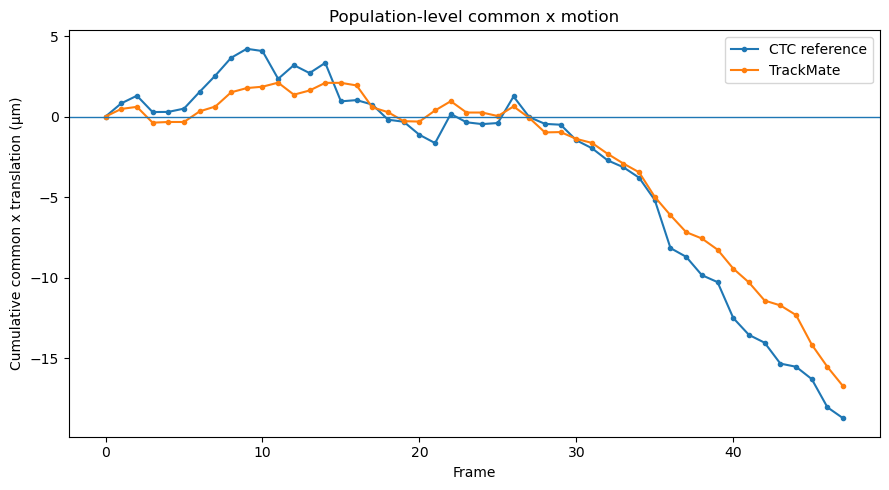

In [57]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    ctc_cumulative_common_motion[
        "frame"
    ],
    ctc_cumulative_common_motion[
        "common_x_um"
    ],
    marker=".",
    label="CTC reference",
)

ax.plot(
    trackmate_cumulative_common_motion[
        "frame"
    ],
    trackmate_cumulative_common_motion[
        "common_x_um"
    ],
    marker=".",
    label="TrackMate",
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xlabel(
    "Frame"
)

ax.set_ylabel(
    "Cumulative common x translation (µm)"
)

ax.set_title(
    "Population-level common x motion"
)

ax.legend()

plt.tight_layout()
plt.show()

In [58]:
ctc_tracks_comoving = (
    ctc_tracks_analysis
    .merge(
        ctc_cumulative_common_motion,
        on="frame",
        how="left",
        validate="many_to_one",
    )
)


ctc_tracks_comoving[
    "x_um"
] = (
    ctc_tracks_comoving[
        "x_um"
    ]
    -
    ctc_tracks_comoving[
        "common_x_um"
    ]
)


ctc_tracks_comoving[
    "y_um"
] = (
    ctc_tracks_comoving[
        "y_um"
    ]
    -
    ctc_tracks_comoving[
        "common_y_um"
    ]
)


ctc_tracks_comoving = (
    ctc_tracks_comoving[
        [
            "cell_id",
            "frame",
            "t_min",
            "x_um",
            "y_um",
        ]
    ]
    .sort_values(
        [
            "cell_id",
            "frame",
        ]
    )
    .reset_index(
        drop=True
    )
)


validate_tracks(
    ctc_tracks_comoving
)

print(
    "CTC co-moving trajectory validation: PASSED"
)

display(
    ctc_tracks_comoving.head()
)

CTC co-moving trajectory validation: PASSED


,cell_id,frame,t_min,x_um,y_um
0,1,0,0.0,35.711383,29.152859
1,1,1,20.0,33.678119,27.787136
2,1,2,40.0,38.036649,30.162160
3,1,3,60.0,43.313914,31.352038
4,1,4,80.0,46.565083,32.705583


In [59]:
ctc_steps_comoving_tau124 = (
    compute_steps_multi_tau(
        tracks=ctc_tracks_comoving,
        taus=CTC_TAUS,
    )
)


assert len(
    ctc_steps_comoving_tau124
) == len(
    ctc_steps_tau124
)


ctc_comoving_step_summary = (
    summarize_steps_by_tau(
        ctc_steps_comoving_tau124,
        "CTC co-moving",
    )
)


ctc_raw_vs_comoving_summary = (
    pd.concat(
        [
            ctc_raw_step_summary,
            ctc_comoving_step_summary,
        ],
        ignore_index=True,
    )
)


display(
    ctc_raw_vs_comoving_summary
)

print(
    "CTC co-moving step reconstruction: PASSED"
)

,source,tau_frames,n_steps,mean_dx_um,median_dx_um,mean_dy_um,median_dy_um
0,CTC reference,1,413,-0.698024,-0.423340,-0.016890,0.149625
1,CTC reference,2,398,-1.430406,-1.089134,-0.113559,0.186781
2,CTC reference,4,369,-2.917329,-2.044786,-0.290467,0.080871
3,CTC co-moving,1,413,-0.266431,0.000000,-0.037088,0.000000
4,CTC co-moving,2,398,-0.544310,-0.158392,-0.148853,-0.142685
5,CTC co-moving,4,369,-1.166852,-0.184757,-0.313020,-0.211544


CTC co-moving step reconstruction: PASSED


## Tracking-source robustness of common directional motion

The CTC reference trajectories reproduce the major negative x-directed
population-motion component previously observed in the TrackMate-derived
trajectories.

The final cumulative common x translation is similar between the two
tracking sources, and the temporal trajectories show closely related
large-scale behaviour.

This indicates that the previously observed common x-direction motion is
not explained solely by TrackMate trajectory fragmentation or tracking
reconstruction.

However, the common y component is less consistent between tracking
sources.

Furthermore, agreement between independent tracking reconstructions does
not establish whether the shared x motion represents biological collective
migration, technical image drift, or a mixture of both.

The CTC co-moving transformation substantially reduces the raw negative
x-displacement bias but does not force the global mean displacement to zero,
because the correction subtracts a frame-wise population median rather than
a global mean.

In [60]:
TRACKMATE_COMOVING_STEPS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_steps_comoving_tau124.csv"
)

trackmate_steps_comoving_tau124 = pd.read_csv(
    TRACKMATE_COMOVING_STEPS_PATH
)


trackmate_comoving_step_summary = (
    summarize_steps_by_tau(
        trackmate_steps_comoving_tau124,
        "TrackMate co-moving",
    )
)


four_representation_step_summary = (
    pd.concat(
        [
            ctc_raw_step_summary,
            ctc_comoving_step_summary,
            trackmate_raw_step_summary,
            trackmate_comoving_step_summary,
        ],
        ignore_index=True,
    )
)


display(
    four_representation_step_summary
)

,source,tau_frames,n_steps,mean_dx_um,median_dx_um,mean_dy_um,median_dy_um
0,CTC reference,1,413,-0.698024,-0.423340,-0.016890,0.149625
1,CTC reference,2,398,-1.430406,-1.089134,-0.113559,0.186781
2,CTC reference,4,369,-2.917329,-2.044786,-0.290467,0.080871
3,CTC co-moving,1,413,-0.266431,0.000000,-0.037088,0.000000
4,CTC co-moving,2,398,-0.544310,-0.158392,-0.148853,-0.142685
5,CTC co-moving,4,369,-1.166852,-0.184757,-0.313020,-0.211544
6,TrackMate,1,433,-0.449440,-0.483247,-0.064475,0.000000
7,TrackMate,2,398,-0.885750,-1.043047,-0.273071,0.000000
8,TrackMate,4,343,-1.686608,-1.747158,-0.772733,0.000000
9,TrackMate co-moving,1,433,-0.072486,0.000000,-0.126184,0.000000


In [61]:
def calculate_dx_reduction(
    raw_summary,
    comoving_summary,
    source_name,
):

    comparison = (
        raw_summary[
            [
                "tau_frames",
                "mean_dx_um",
            ]
        ]
        .rename(
            columns={
                "mean_dx_um":
                    "raw_mean_dx_um"
            }
        )
        .merge(
            comoving_summary[
                [
                    "tau_frames",
                    "mean_dx_um",
                ]
            ]
            .rename(
                columns={
                    "mean_dx_um":
                        "comoving_mean_dx_um"
                }
            ),
            on="tau_frames",
            validate="one_to_one",
        )
    )

    comparison[
        "absolute_dx_reduction_fraction"
    ] = (
        1.0
        -
        (
            comparison[
                "comoving_mean_dx_um"
            ].abs()
            /
            comparison[
                "raw_mean_dx_um"
            ].abs()
        )
    )

    comparison.insert(
        0,
        "source",
        source_name,
    )

    return comparison


ctc_dx_reduction = (
    calculate_dx_reduction(
        ctc_raw_step_summary,
        ctc_comoving_step_summary,
        "CTC reference",
    )
)

trackmate_dx_reduction = (
    calculate_dx_reduction(
        trackmate_raw_step_summary,
        trackmate_comoving_step_summary,
        "TrackMate",
    )
)


dx_reduction_summary = pd.concat(
    [
        ctc_dx_reduction,
        trackmate_dx_reduction,
    ],
    ignore_index=True,
)


display(
    dx_reduction_summary
)

,source,tau_frames,raw_mean_dx_um,comoving_mean_dx_um,absolute_dx_reduction_fraction
0,CTC reference,1,-0.698024,-0.266431,0.618306
1,CTC reference,2,-1.430406,-0.544310,0.619471
2,CTC reference,4,-2.917329,-1.166852,0.600027
3,TrackMate,1,-0.449440,-0.072486,0.838719
4,TrackMate,2,-0.885750,-0.132785,0.850087
5,TrackMate,4,-1.686608,-0.293470,0.826000


In [62]:
framewise_common_comparison = (
    ctc_common_motion
    .merge(
        trackmate_common_motion,
        on=[
            "frame_start",
            "frame_end",
        ],
        suffixes=(
            "_ctc",
            "_trackmate",
        ),
        validate="one_to_one",
    )
)


framewise_dx_correlation = (
    framewise_common_comparison[
        "common_dx_um_ctc"
    ]
    .corr(
        framewise_common_comparison[
            "common_dx_um_trackmate"
        ]
    )
)


framewise_dx_mae = np.mean(
    np.abs(
        framewise_common_comparison[
            "common_dx_um_ctc"
        ]
        -
        framewise_common_comparison[
            "common_dx_um_trackmate"
        ]
    )
)


framewise_dy_correlation = (
    framewise_common_comparison[
        "common_dy_um_ctc"
    ]
    .corr(
        framewise_common_comparison[
            "common_dy_um_trackmate"
        ]
    )
)


cumulative_common_comparison = (
    ctc_cumulative_common_motion
    .merge(
        trackmate_cumulative_common_motion,
        on="frame",
        suffixes=(
            "_ctc",
            "_trackmate",
        ),
        validate="one_to_one",
    )
)


cumulative_x_correlation = (
    cumulative_common_comparison[
        "common_x_um_ctc"
    ]
    .corr(
        cumulative_common_comparison[
            "common_x_um_trackmate"
        ]
    )
)


common_motion_agreement = pd.DataFrame(
    [
        {
            "metric": "framewise_dx_correlation",
            "value": framewise_dx_correlation,
        },
        {
            "metric": "framewise_dx_mae_um",
            "value": framewise_dx_mae,
        },
        {
            "metric": "framewise_dy_correlation",
            "value": framewise_dy_correlation,
        },
        {
            "metric": "cumulative_x_correlation",
            "value": cumulative_x_correlation,
        },
        {
            "metric": "final_ctc_common_x_um",
            "value": (
                cumulative_common_comparison[
                    "common_x_um_ctc"
                ].iloc[-1]
            ),
        },
        {
            "metric": "final_trackmate_common_x_um",
            "value": (
                cumulative_common_comparison[
                    "common_x_um_trackmate"
                ].iloc[-1]
            ),
        },
    ]
)


display(
    common_motion_agreement
)

,metric,value
0,framewise_dx_correlation,0.587446
1,framewise_dx_mae_um,0.593795
2,framewise_dy_correlation,0.596010
3,cumulative_x_correlation,0.989253
4,final_ctc_common_x_um,-18.735017
5,final_trackmate_common_x_um,-16.746817


In [63]:
CTC_COMOVING_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_ctc_reference_comoving.csv"
)

CTC_RAW_STEPS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_steps_ctc_reference_tau124.csv"
)

CTC_COMOVING_STEPS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_steps_ctc_reference_comoving_tau124.csv"
)


ctc_tracks_comoving.to_csv(
    CTC_COMOVING_TRACKS_PATH,
    index=False,
)

ctc_steps_tau124.to_csv(
    CTC_RAW_STEPS_PATH,
    index=False,
)

ctc_steps_comoving_tau124.to_csv(
    CTC_COMOVING_STEPS_PATH,
    index=False,
)


print(
    "Saved:",
    CTC_COMOVING_TRACKS_PATH.name,
)

print(
    "Saved:",
    CTC_RAW_STEPS_PATH.name,
)

print(
    "Saved:",
    CTC_COMOVING_STEPS_PATH.name,
)

print(
    "CTC derived-data export: PASSED"
)

Saved: MSC01_tracks_ctc_reference_comoving.csv
Saved: MSC01_steps_ctc_reference_tau124.csv
Saved: MSC01_steps_ctc_reference_comoving_tau124.csv
CTC derived-data export: PASSED


In [64]:
import src.density as density_module
import src.metrics as metrics_module


def list_module_functions(
    module,
    module_name,
):
    print(
        f"\n{module_name} functions:"
    )

    for name, function in (
        inspect.getmembers(
            module,
            inspect.isfunction,
        )
    ):
        if not name.startswith("_"):

            print(
                name,
                inspect.signature(
                    function
                ),
            )


list_module_functions(
    density_module,
    "src.density",
)

list_module_functions(
    metrics_module,
    "src.metrics",
)


src.density functions:
evaluate_kde_1d (values: pandas.core.series.Series, grid: numpy.ndarray, bandwidth: float) -> numpy.ndarray
evaluate_kde_2d (points: numpy.ndarray, x_grid: numpy.ndarray, y_grid: numpy.ndarray, bandwidth: float)
freedman_diaconis_bin_width (values: pandas.core.series.Series) -> float
get_displacement_points (data: pandas.core.frame.DataFrame, representation: str, tau_frames: int) -> numpy.ndarray
get_displacement_series (data: pandas.core.frame.DataFrame, representation: str, tau_frames: int, component: str) -> pandas.core.series.Series
make_fd_bins (first: pandas.core.series.Series, second: pandas.core.series.Series) -> numpy.ndarray
make_shared_bins (first: pandas.core.series.Series, second: pandas.core.series.Series, n_bins: int = 30) -> numpy.ndarray
make_symmetric_2d_grid (raw_points: numpy.ndarray, comoving_points: numpy.ndarray, bandwidth: float, n_grid: int = 101)
robust_scale_1d (values: numpy.ndarray) -> float
shared_bandwidth_2d (raw_points: numpy.nda

## Phase 5 estimator recovery and reusable-module refactor

The original Phase 5 density-estimation and spatial-inversion functions were
recovered from `05_displacement_density_MSC01.ipynb`.

Because these functions are now reused in Phase 8A, the reusable numerical
logic has been promoted into:

- `src/density.py`
- `src/metrics.py`

The original Phase 5 notebook remains unchanged as the historical executed
analysis record.

Synthetic unit tests were added for the reusable functions. The complete test
suite now reports:

`20 passed`

Before applying the recovered estimator to CTC reference trajectories, the
refactored implementation will be checked against the original TrackMate
Phase 5 numerical baseline.

The purpose of this regression check is to verify that the refactor changed
code organization, but did not change the scientific definition or numerical
behavior of the estimator.

In [65]:
from src.steps import (
    validate_tracks,
    compute_steps_multi_tau,
)

from src.density import (
    get_displacement_points,
    shared_bandwidth_2d,
    make_symmetric_2d_grid,
    evaluate_kde_2d,
)

from src.metrics import inversion_asymmetry_index


TRACKMATE_RAW_PATH = (
    PROJECT_ROOT / "data" / "MSC01_tracks_clean.csv"
)

TRACKMATE_COMOVING_PATH = (
    PROJECT_ROOT / "data" / "MSC01_tracks_comoving.csv"
)

TRACK_COLUMNS = [
    "cell_id",
    "frame",
    "t_min",
    "x_um",
    "y_um",
]

TAUS = [1, 2, 4]


trackmate_raw_regression = pd.read_csv(
    TRACKMATE_RAW_PATH
)[TRACK_COLUMNS].copy()

trackmate_comoving_regression = pd.read_csv(
    TRACKMATE_COMOVING_PATH
)[TRACK_COLUMNS].copy()


validate_tracks(trackmate_raw_regression)
validate_tracks(trackmate_comoving_regression)


raw_structure = (
    trackmate_raw_regression[
        ["cell_id", "frame", "t_min"]
    ]
    .sort_values(["cell_id", "frame"])
    .reset_index(drop=True)
)

comoving_structure = (
    trackmate_comoving_regression[
        ["cell_id", "frame", "t_min"]
    ]
    .sort_values(["cell_id", "frame"])
    .reset_index(drop=True)
)

assert raw_structure.equals(
    comoving_structure
)


trackmate_raw_steps_regression = (
    compute_steps_multi_tau(
        trackmate_raw_regression,
        taus=TAUS,
    )
)

trackmate_comoving_steps_regression = (
    compute_steps_multi_tau(
        trackmate_comoving_regression,
        taus=TAUS,
    )
)


raw_counts = (
    trackmate_raw_steps_regression
    .groupby("tau_frames")
    .size()
    .to_dict()
)

comoving_counts = (
    trackmate_comoving_steps_regression
    .groupby("tau_frames")
    .size()
    .to_dict()
)

print("Raw counts:", raw_counts)
print("Co-moving counts:", comoving_counts)

assert raw_counts == {
    1: 433,
    2: 398,
    4: 343,
}

assert comoving_counts == raw_counts


trackmate_raw_steps_regression[
    "representation"
] = "raw"

trackmate_comoving_steps_regression[
    "representation"
] = "comoving"

trackmate_phase5_regression = pd.concat(
    [
        trackmate_raw_steps_regression,
        trackmate_comoving_steps_regression,
    ],
    ignore_index=True,
)

print(
    "Combined regression rows:",
    len(trackmate_phase5_regression),
)

print(
    "TrackMate Phase 5 input reconstruction: PASSED"
)

Raw counts: {1: 433, 2: 398, 4: 343}
Co-moving counts: {1: 433, 2: 398, 4: 343}
Combined regression rows: 2348
TrackMate Phase 5 input reconstruction: PASSED


In [66]:
phase5_regression_records = []

for tau in TAUS:
    raw_points = get_displacement_points(
        data=trackmate_phase5_regression,
        representation="raw",
        tau_frames=tau,
    )

    comoving_points = get_displacement_points(
        data=trackmate_phase5_regression,
        representation="comoving",
        tau_frames=tau,
    )

    bandwidth = shared_bandwidth_2d(
        raw_points,
        comoving_points,
    )

    x_grid, y_grid = make_symmetric_2d_grid(
        raw_points,
        comoving_points,
        bandwidth=bandwidth,
        n_grid=101,
    )

    _, _, raw_density = evaluate_kde_2d(
        points=raw_points,
        x_grid=x_grid,
        y_grid=y_grid,
        bandwidth=bandwidth,
    )

    _, _, comoving_density = evaluate_kde_2d(
        points=comoving_points,
        x_grid=x_grid,
        y_grid=y_grid,
        bandwidth=bandwidth,
    )

    raw_asymmetry, raw_grid_mass = (
        inversion_asymmetry_index(
            density=raw_density,
            x_grid=x_grid,
            y_grid=y_grid,
        )
    )

    comoving_asymmetry, comoving_grid_mass = (
        inversion_asymmetry_index(
            density=comoving_density,
            x_grid=x_grid,
            y_grid=y_grid,
        )
    )

    phase5_regression_records.extend(
        [
            {
                "representation": "raw",
                "tau_frames": tau,
                "n": len(raw_points),
                "bandwidth_um": bandwidth,
                "grid_mass": raw_grid_mass,
                "inversion_asymmetry_nats": raw_asymmetry,
            },
            {
                "representation": "comoving",
                "tau_frames": tau,
                "n": len(comoving_points),
                "bandwidth_um": bandwidth,
                "grid_mass": comoving_grid_mass,
                "inversion_asymmetry_nats": comoving_asymmetry,
            },
        ]
    )


phase5_regression_results = pd.DataFrame(
    phase5_regression_records
)

display(
    phase5_regression_results
    .sort_values(
        ["tau_frames", "representation"]
    )
    .reset_index(drop=True)
)

,representation,tau_frames,n,bandwidth_um,grid_mass,inversion_asymmetry_nats
0,comoving,1,433,0.515968,0.999999,0.482956
1,raw,1,433,0.515968,0.999998,0.682156
2,comoving,2,398,0.955681,0.999997,0.437690
3,raw,2,398,0.955681,0.999998,0.568221
4,comoving,4,343,1.755631,0.999998,0.541848
5,raw,4,343,1.755631,0.999996,0.792825


In [67]:
EXPECTED_PHASE5_BASELINE = {
    ("raw", 1): {
        "n": 433,
        "bandwidth_um": 0.515968,
        "asymmetry": 0.682156,
    },
    ("comoving", 1): {
        "n": 433,
        "bandwidth_um": 0.515968,
        "asymmetry": 0.482956,
    },
    ("raw", 2): {
        "n": 398,
        "bandwidth_um": 0.955681,
        "asymmetry": 0.568221,
    },
    ("comoving", 2): {
        "n": 398,
        "bandwidth_um": 0.955681,
        "asymmetry": 0.437690,
    },
    ("raw", 4): {
        "n": 343,
        "bandwidth_um": 1.755631,
        "asymmetry": 0.792825,
    },
    ("comoving", 4): {
        "n": 343,
        "bandwidth_um": 1.755631,
        "asymmetry": 0.541848,
    },
}


for _, row in phase5_regression_results.iterrows():
    key = (
        row["representation"],
        int(row["tau_frames"]),
    )

    expected = EXPECTED_PHASE5_BASELINE[key]

    assert int(row["n"]) == expected["n"]

    assert np.isclose(
        row["bandwidth_um"],
        expected["bandwidth_um"],
        atol=5e-6,
    )

    assert np.isclose(
        row["inversion_asymmetry_nats"],
        expected["asymmetry"],
        atol=5e-6,
    )

    assert 0.9999 < row["grid_mass"] < 1.0001


print(
    "Phase 5 real-data regression validation: PASSED"
)

Phase 5 real-data regression validation: PASSED


## CTC replication of Phase 5 spatial inversion asymmetry

The validated Phase 5 estimator is now applied to the CTC reference-tracking
trajectories.

The scientific question is:

> Does the single-displacement spatial inversion asymmetry observed with
> TrackMate persist when trajectories are reconstructed from the independent
> CTC tracking-reference annotations?

For each lag, the CTC raw and CTC co-moving displacement samples are analyzed
using exactly the same numerical definition used in Phase 5:

1. extract two-dimensional displacement vectors;
2. estimate one shared KDE bandwidth for raw and co-moving samples;
3. construct a symmetric evaluation grid around the origin;
4. estimate the two-dimensional Gaussian KDE;
5. compare p(Δ) with p(-Δ);
6. calculate the KL-based inversion-asymmetry statistic.

The baseline calculation preserves the original Phase 5 design within each
tracking source. Therefore, CTC raw and co-moving samples share a bandwidth,
just as TrackMate raw and co-moving samples did.

Because the absolute asymmetry magnitude is bandwidth-dependent, direct
cross-tracking-source magnitude comparisons will later receive an additional
common-bandwidth sensitivity check.

This remains a measure of **single-displacement spatial inversion asymmetry**,
not full temporal irreversibility or entropy production.

In [68]:
from src.density import get_displacement_points
from src.metrics import compute_asymmetry_pair


ctc_steps_raw_phase5 = ctc_steps_tau124.copy()
ctc_steps_comoving_phase5 = ctc_steps_comoving_tau124.copy()

ctc_steps_raw_phase5["representation"] = "raw"
ctc_steps_comoving_phase5["representation"] = "comoving"

ctc_phase5_steps = pd.concat(
    [
        ctc_steps_raw_phase5,
        ctc_steps_comoving_phase5,
    ],
    ignore_index=True,
)


ctc_raw_counts_phase5 = (
    ctc_steps_raw_phase5
    .groupby("tau_frames")
    .size()
    .to_dict()
)

ctc_comoving_counts_phase5 = (
    ctc_steps_comoving_phase5
    .groupby("tau_frames")
    .size()
    .to_dict()
)


print("CTC raw counts:", ctc_raw_counts_phase5)
print("CTC co-moving counts:", ctc_comoving_counts_phase5)
print("Combined CTC Phase 5 rows:", len(ctc_phase5_steps))


EXPECTED_CTC_COUNTS = {
    1: 413,
    2: 398,
    4: 369,
}

assert ctc_raw_counts_phase5 == EXPECTED_CTC_COUNTS
assert ctc_comoving_counts_phase5 == EXPECTED_CTC_COUNTS

assert len(ctc_phase5_steps) == (
    2 * sum(EXPECTED_CTC_COUNTS.values())
)

print("CTC Phase 5 input validation: PASSED")

CTC raw counts: {1: 413, 2: 398, 4: 369}
CTC co-moving counts: {1: 413, 2: 398, 4: 369}
Combined CTC Phase 5 rows: 2360
CTC Phase 5 input validation: PASSED


In [69]:
ctc_phase5_baseline_tables = []

for tau in CTC_TAUS:
    raw_points = get_displacement_points(
        data=ctc_phase5_steps,
        representation="raw",
        tau_frames=tau,
    )

    comoving_points = get_displacement_points(
        data=ctc_phase5_steps,
        representation="comoving",
        tau_frames=tau,
    )

    tau_results = compute_asymmetry_pair(
        raw_points=raw_points,
        comoving_points=comoving_points,
        tau_frames=tau,
        bandwidth_multiplier=1.0,
        n_grid=101,
    )

    tau_results["n"] = [
        len(raw_points),
        len(comoving_points),
    ]

    ctc_phase5_baseline_tables.append(
        tau_results
    )


ctc_phase5_baseline = pd.concat(
    ctc_phase5_baseline_tables,
    ignore_index=True,
)

ctc_phase5_baseline = (
    ctc_phase5_baseline[
        [
            "tau_frames",
            "representation",
            "n",
            "bandwidth_um",
            "grid_mass",
            "inversion_asymmetry_nats",
        ]
    ]
    .sort_values(
        ["tau_frames", "representation"]
    )
    .reset_index(drop=True)
)

display(ctc_phase5_baseline)


assert np.isfinite(
    ctc_phase5_baseline[
        "inversion_asymmetry_nats"
    ]
).all()

assert (
    ctc_phase5_baseline[
        "inversion_asymmetry_nats"
    ] >= 0
).all()

assert np.allclose(
    ctc_phase5_baseline["grid_mass"],
    1.0,
    atol=1e-3,
)

print("CTC Phase 5 baseline calculation: PASSED")

,tau_frames,representation,n,bandwidth_um,grid_mass,inversion_asymmetry_nats
0,1,comoving,413,0.812072,0.999999,0.640837
1,1,raw,413,0.812072,0.999997,0.946288
2,2,comoving,398,1.270605,1.000000,0.684427
3,2,raw,398,1.270605,0.999998,1.013269
4,4,comoving,369,2.210311,1.000000,0.688485
5,4,raw,369,2.210311,0.999997,1.278303


CTC Phase 5 baseline calculation: PASSED


In [70]:
trackmate_phase5_for_comparison = (
    phase5_regression_results.copy()
)

trackmate_phase5_for_comparison[
    "tracking_source"
] = "TrackMate"


ctc_phase5_for_comparison = (
    ctc_phase5_baseline.copy()
)

ctc_phase5_for_comparison[
    "tracking_source"
] = "CTC reference"


phase5_tracking_comparison = pd.concat(
    [
        trackmate_phase5_for_comparison,
        ctc_phase5_for_comparison,
    ],
    ignore_index=True,
)


phase5_tracking_comparison = (
    phase5_tracking_comparison[
        [
            "tracking_source",
            "representation",
            "tau_frames",
            "n",
            "bandwidth_um",
            "grid_mass",
            "inversion_asymmetry_nats",
        ]
    ]
    .sort_values(
        [
            "tau_frames",
            "tracking_source",
            "representation",
        ]
    )
    .reset_index(drop=True)
)

display(phase5_tracking_comparison)

,tracking_source,representation,tau_frames,n,bandwidth_um,grid_mass,inversion_asymmetry_nats
0,CTC reference,comoving,1,413,0.812072,0.999999,0.640837
1,CTC reference,raw,1,413,0.812072,0.999997,0.946288
2,TrackMate,comoving,1,433,0.515968,0.999999,0.482956
3,TrackMate,raw,1,433,0.515968,0.999998,0.682156
4,CTC reference,comoving,2,398,1.270605,1.000000,0.684427
5,CTC reference,raw,2,398,1.270605,0.999998,1.013269
6,TrackMate,comoving,2,398,0.955681,0.999997,0.437690
7,TrackMate,raw,2,398,0.955681,0.999998,0.568221
8,CTC reference,comoving,4,369,2.210311,1.000000,0.688485
9,CTC reference,raw,4,369,2.210311,0.999997,1.278303


In [71]:
phase5_effect_records = []

for tracking_source in [
    "TrackMate",
    "CTC reference",
]:
    for tau in CTC_TAUS:

        subset = phase5_tracking_comparison.loc[
            (
                phase5_tracking_comparison[
                    "tracking_source"
                ].eq(tracking_source)
            )
            & (
                phase5_tracking_comparison[
                    "tau_frames"
                ].eq(tau)
            )
        ]

        raw_value = float(
            subset.loc[
                subset["representation"].eq("raw"),
                "inversion_asymmetry_nats",
            ].iloc[0]
        )

        comoving_value = float(
            subset.loc[
                subset["representation"].eq("comoving"),
                "inversion_asymmetry_nats",
            ].iloc[0]
        )

        difference = (
            raw_value
            - comoving_value
        )

        relative_reduction = (
            difference / raw_value
            if raw_value != 0
            else np.nan
        )

        phase5_effect_records.append(
            {
                "tracking_source": tracking_source,
                "tau_frames": tau,
                "raw_asymmetry": raw_value,
                "comoving_asymmetry": comoving_value,
                "raw_minus_comoving": difference,
                "relative_reduction": relative_reduction,
            }
        )


phase5_common_motion_effect = pd.DataFrame(
    phase5_effect_records
)

display(phase5_common_motion_effect)

,tracking_source,tau_frames,raw_asymmetry,comoving_asymmetry,raw_minus_comoving,relative_reduction
0,TrackMate,1,0.682156,0.482956,0.199199,0.292014
1,TrackMate,2,0.568221,0.437690,0.130532,0.229720
2,TrackMate,4,0.792825,0.541848,0.250977,0.316560
3,CTC reference,1,0.946288,0.640837,0.305451,0.322788
4,CTC reference,2,1.013269,0.684427,0.328842,0.324536
5,CTC reference,4,1.278303,0.688485,0.589818,0.461407


### Interim Phase 5 replication result

The CTC tracking-reference trajectories reproduce the principal qualitative
Phase 5 finding obtained from TrackMate.

At all three exact lags, the raw CTC displacement distribution has greater
spatial-inversion asymmetry than its co-moving counterpart.

The raw-to-co-moving reduction is:

- approximately 32% at τ = 1;
- approximately 32% at τ = 2;
- approximately 46% at τ = 4.

TrackMate showed the same direction of effect at all three lags.

Therefore, the conclusion that common population motion contributes
substantially to single-displacement spatial inversion asymmetry does not
appear to depend solely on the TrackMate trajectory reconstruction.

However, the CTC source-specific KDE bandwidths are larger than the TrackMate
bandwidths. Absolute CTC-versus-TrackMate asymmetry magnitudes should therefore
not yet be interpreted as directly comparable.

A cross-tracking-source common-bandwidth sensitivity analysis is performed
next.

In [72]:
from src.density import robust_scale_1d


def pooled_four_group_bandwidth(
    point_groups,
):
    """
    Estimate one Phase-5-style isotropic bandwidth
    shared across multiple displacement samples.
    """

    combined = np.vstack(point_groups)

    scale_x = robust_scale_1d(
        combined[:, 0]
    )

    scale_y = robust_scale_1d(
        combined[:, 1]
    )

    characteristic_scale = np.sqrt(
        scale_x * scale_y
    )

    n = min(
        len(points)
        for points in point_groups
    )

    bandwidth = (
        characteristic_scale
        * n ** (-1 / 6)
    )

    return float(bandwidth)


def make_pooled_symmetric_grid(
    point_groups,
    bandwidth,
    n_grid=101,
):
    """
    Construct one symmetric grid covering all
    tracking-source/representation samples.
    """

    combined = np.vstack(point_groups)

    x_limit = (
        np.max(
            np.abs(combined[:, 0])
        )
        + 3 * bandwidth
    )

    y_limit = (
        np.max(
            np.abs(combined[:, 1])
        )
        + 3 * bandwidth
    )

    x_grid = np.linspace(
        -x_limit,
        x_limit,
        n_grid,
    )

    y_grid = np.linspace(
        -y_limit,
        y_limit,
        n_grid,
    )

    return x_grid, y_grid

In [73]:
common_bandwidth_records = []

for tau in CTC_TAUS:

    tm_raw_points = get_displacement_points(
        data=trackmate_phase5_regression,
        representation="raw",
        tau_frames=tau,
    )

    tm_comoving_points = get_displacement_points(
        data=trackmate_phase5_regression,
        representation="comoving",
        tau_frames=tau,
    )

    ctc_raw_points = get_displacement_points(
        data=ctc_phase5_steps,
        representation="raw",
        tau_frames=tau,
    )

    ctc_comoving_points = get_displacement_points(
        data=ctc_phase5_steps,
        representation="comoving",
        tau_frames=tau,
    )

    point_groups = [
        tm_raw_points,
        tm_comoving_points,
        ctc_raw_points,
        ctc_comoving_points,
    ]

    common_bandwidth = pooled_four_group_bandwidth(
        point_groups
    )

    x_grid, y_grid = make_pooled_symmetric_grid(
        point_groups,
        bandwidth=common_bandwidth,
        n_grid=101,
    )

    analysis_groups = [
        ("TrackMate", "raw", tm_raw_points),
        ("TrackMate", "comoving", tm_comoving_points),
        ("CTC reference", "raw", ctc_raw_points),
        ("CTC reference", "comoving", ctc_comoving_points),
    ]

    for (
        tracking_source,
        representation,
        points,
    ) in analysis_groups:

        _, _, density = evaluate_kde_2d(
            points=points,
            x_grid=x_grid,
            y_grid=y_grid,
            bandwidth=common_bandwidth,
        )

        asymmetry, grid_mass = (
            inversion_asymmetry_index(
                density=density,
                x_grid=x_grid,
                y_grid=y_grid,
            )
        )

        common_bandwidth_records.append(
            {
                "tau_frames": tau,
                "tracking_source": tracking_source,
                "representation": representation,
                "n": len(points),
                "common_bandwidth_um": common_bandwidth,
                "grid_mass": grid_mass,
                "inversion_asymmetry_nats": asymmetry,
            }
        )


phase5_common_bandwidth = pd.DataFrame(
    common_bandwidth_records
)

phase5_common_bandwidth = (
    phase5_common_bandwidth
    .sort_values(
        [
            "tau_frames",
            "tracking_source",
            "representation",
        ]
    )
    .reset_index(drop=True)
)

display(phase5_common_bandwidth)


assert np.isfinite(
    phase5_common_bandwidth[
        "inversion_asymmetry_nats"
    ]
).all()

assert (
    phase5_common_bandwidth[
        "inversion_asymmetry_nats"
    ] >= 0
).all()

assert np.allclose(
    phase5_common_bandwidth["grid_mass"],
    1.0,
    atol=1e-3,
)

print(
    "Cross-source common-bandwidth analysis: PASSED"
)

,tau_frames,tracking_source,representation,n,common_bandwidth_um,grid_mass,inversion_asymmetry_nats
0,1,CTC reference,comoving,413,0.641364,1.000000,0.842041
1,1,CTC reference,raw,413,0.641364,0.999998,1.180152
2,1,TrackMate,comoving,433,0.641364,1.000000,0.355624
3,1,TrackMate,raw,433,0.641364,1.000000,0.521557
4,2,CTC reference,comoving,398,1.144118,1.000000,0.791451
5,2,CTC reference,raw,398,1.144118,0.999998,1.162708
6,2,TrackMate,comoving,398,1.144118,1.000000,0.328267
7,2,TrackMate,raw,398,1.144118,1.000000,0.440774
8,4,CTC reference,comoving,369,1.984879,1.000000,0.817348
9,4,CTC reference,raw,369,1.984879,0.999997,1.486420


Cross-source common-bandwidth analysis: PASSED


In [74]:
common_bandwidth_summary_records = []

for tau in CTC_TAUS:

    tau_table = (
        phase5_common_bandwidth.loc[
            phase5_common_bandwidth[
                "tau_frames"
            ].eq(tau)
        ]
    )

    for tracking_source in [
        "TrackMate",
        "CTC reference",
    ]:

        source_table = tau_table.loc[
            tau_table[
                "tracking_source"
            ].eq(tracking_source)
        ]

        raw_value = float(
            source_table.loc[
                source_table[
                    "representation"
                ].eq("raw"),
                "inversion_asymmetry_nats",
            ].iloc[0]
        )

        comoving_value = float(
            source_table.loc[
                source_table[
                    "representation"
                ].eq("comoving"),
                "inversion_asymmetry_nats",
            ].iloc[0]
        )

        common_bandwidth_summary_records.append(
            {
                "tau_frames": tau,
                "tracking_source": tracking_source,
                "raw_asymmetry": raw_value,
                "comoving_asymmetry": comoving_value,
                "raw_minus_comoving": (
                    raw_value
                    - comoving_value
                ),
                "raw_gt_comoving": (
                    raw_value
                    > comoving_value
                ),
            }
        )


phase5_common_bandwidth_summary = pd.DataFrame(
    common_bandwidth_summary_records
)

display(
    phase5_common_bandwidth_summary
)

,tau_frames,tracking_source,raw_asymmetry,comoving_asymmetry,raw_minus_comoving,raw_gt_comoving
0,1,TrackMate,0.521557,0.355624,0.165933,True
1,1,CTC reference,1.180152,0.842041,0.338111,True
2,2,TrackMate,0.440774,0.328267,0.112507,True
3,2,CTC reference,1.162708,0.791451,0.371257,True
4,4,TrackMate,0.681498,0.454353,0.227145,True
5,4,CTC reference,1.486420,0.817348,0.669072,True


In [75]:
BANDWIDTH_MULTIPLIERS = [
    0.5,
    1.0,
    2.0,
]

bandwidth_sensitivity_records = []


for tau in CTC_TAUS:

    tm_raw_points = get_displacement_points(
        trackmate_phase5_regression,
        "raw",
        tau,
    )

    tm_comoving_points = get_displacement_points(
        trackmate_phase5_regression,
        "comoving",
        tau,
    )

    ctc_raw_points = get_displacement_points(
        ctc_phase5_steps,
        "raw",
        tau,
    )

    ctc_comoving_points = get_displacement_points(
        ctc_phase5_steps,
        "comoving",
        tau,
    )

    point_groups = [
        tm_raw_points,
        tm_comoving_points,
        ctc_raw_points,
        ctc_comoving_points,
    ]

    baseline_common_bandwidth = (
        pooled_four_group_bandwidth(
            point_groups
        )
    )

    for multiplier in BANDWIDTH_MULTIPLIERS:

        bandwidth = (
            baseline_common_bandwidth
            * multiplier
        )

        x_grid, y_grid = (
            make_pooled_symmetric_grid(
                point_groups,
                bandwidth=bandwidth,
                n_grid=101,
            )
        )

        analysis_groups = [
            (
                "TrackMate",
                "raw",
                tm_raw_points,
            ),
            (
                "TrackMate",
                "comoving",
                tm_comoving_points,
            ),
            (
                "CTC reference",
                "raw",
                ctc_raw_points,
            ),
            (
                "CTC reference",
                "comoving",
                ctc_comoving_points,
            ),
        ]

        for (
            tracking_source,
            representation,
            points,
        ) in analysis_groups:

            _, _, density = evaluate_kde_2d(
                points,
                x_grid,
                y_grid,
                bandwidth,
            )

            asymmetry, grid_mass = (
                inversion_asymmetry_index(
                    density,
                    x_grid,
                    y_grid,
                )
            )

            bandwidth_sensitivity_records.append(
                {
                    "tau_frames": tau,
                    "bandwidth_multiplier": multiplier,
                    "tracking_source": tracking_source,
                    "representation": representation,
                    "bandwidth_um": bandwidth,
                    "inversion_asymmetry_nats": asymmetry,
                    "grid_mass": grid_mass,
                }
            )


phase5_cross_source_bandwidth_sensitivity = (
    pd.DataFrame(
        bandwidth_sensitivity_records
    )
)

display(
    phase5_cross_source_bandwidth_sensitivity
)

,tau_frames,bandwidth_multiplier,tracking_source,representation,bandwidth_um,inversion_asymmetry_nats,grid_mass
0,1,0.5,TrackMate,raw,0.320682,1.234256,1.000086
1,1,0.5,TrackMate,comoving,0.320682,0.933259,1.000062
2,1,0.5,CTC reference,raw,0.320682,2.419479,1.000002
3,1,0.5,CTC reference,comoving,0.320682,1.889267,1.000006
4,1,1.0,TrackMate,raw,0.641364,0.521557,1.000000
5,1,1.0,TrackMate,comoving,0.641364,0.355624,1.000000
6,1,1.0,CTC reference,raw,0.641364,1.180152,0.999998
7,1,1.0,CTC reference,comoving,0.641364,0.842041,1.000000
8,1,2.0,TrackMate,raw,1.282728,0.185191,1.000000
9,1,2.0,TrackMate,comoving,1.282728,0.102579,1.000000


### Tracking-source and bandwidth robustness of the Phase 5 result

The CTC and TrackMate reconstructions were next compared on exactly the same
KDE bandwidth and evaluation grid at each lag.

The qualitative raw-to-co-moving ordering was preserved for both tracking
sources:

`raw asymmetry > co-moving asymmetry`

at τ = 1, 2, and 4.

This ordering also remained unchanged when the common cross-source bandwidth
was multiplied by 0.5, 1.0, and 2.0.

Therefore, the conclusion that population-level common motion contributes to
single-displacement spatial inversion asymmetry is robust to both tracking
source and the tested KDE smoothing range.

However, CTC produced larger asymmetry estimates than TrackMate in both raw and
co-moving coordinates across the tested lags and bandwidths.

Thus, the **direction of the common-motion effect is tracking-source robust,
whereas the absolute magnitude of the inversion-asymmetry estimator is
tracking-source sensitive**.

The larger CTC values are not interpreted as greater physical irreversibility.
They may reflect differences in trajectory reconstruction, localization,
fragmentation, sampled track composition, or other tracking-source-dependent
features.

In [76]:
from src.metrics import bootstrap_cell_points


N_BOOTSTRAP_CTC = 100
BOOTSTRAP_SEED_CTC = 2026

ctc_bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED_CTC
)

ctc_bootstrap_records = []


for tau_frames in CTC_TAUS:

    raw_tau = (
        ctc_steps_raw_phase5
        .loc[
            ctc_steps_raw_phase5[
                "tau_frames"
            ].eq(tau_frames)
        ]
        .copy()
    )

    comoving_tau = (
        ctc_steps_comoving_phase5
        .loc[
            ctc_steps_comoving_phase5[
                "tau_frames"
            ].eq(tau_frames)
        ]
        .copy()
    )

    common_cells = sorted(
        set(raw_tau["cell_id"].unique())
        .intersection(
            set(
                comoving_tau[
                    "cell_id"
                ].unique()
            )
        )
    )

    print(
        f"tau={tau_frames}: "
        f"{len(common_cells)} contributing CTC tracks"
    )

    for bootstrap_id in range(
        N_BOOTSTRAP_CTC
    ):

        (
            raw_points,
            comoving_points,
        ) = bootstrap_cell_points(
            raw_tau,
            comoving_tau,
            ctc_bootstrap_rng,
        )

        result = compute_asymmetry_pair(
            raw_points=raw_points,
            comoving_points=comoving_points,
            tau_frames=tau_frames,
            bandwidth_multiplier=1.0,
            n_grid=81,
        )

        raw_value = float(
            result.loc[
                result[
                    "representation"
                ].eq("raw"),
                "inversion_asymmetry_nats",
            ].iloc[0]
        )

        comoving_value = float(
            result.loc[
                result[
                    "representation"
                ].eq("comoving"),
                "inversion_asymmetry_nats",
            ].iloc[0]
        )

        ctc_bootstrap_records.append(
            {
                "bootstrap_id": bootstrap_id,
                "tau_frames": tau_frames,
                "raw": raw_value,
                "comoving": comoving_value,
                "raw_minus_comoving": (
                    raw_value
                    - comoving_value
                ),
            }
        )


ctc_bootstrap_results = pd.DataFrame(
    ctc_bootstrap_records
)

print(
    "CTC bootstrap replicates:",
    len(ctc_bootstrap_results),
)

display(
    ctc_bootstrap_results.head()
)

assert len(ctc_bootstrap_results) == 300
print("CTC cell-level bootstrap: PASSED")

tau=1: 15 contributing CTC tracks
tau=2: 15 contributing CTC tracks
tau=4: 14 contributing CTC tracks
CTC bootstrap replicates: 300


,bootstrap_id,tau_frames,raw,comoving,raw_minus_comoving
0,0,1,0.973939,0.686249,0.287689
1,1,1,1.636240,1.123753,0.512487
2,2,1,0.950739,0.654861,0.295878
3,3,1,0.876786,0.557341,0.319445
4,4,1,1.042230,0.894764,0.147466


CTC cell-level bootstrap: PASSED


In [77]:
ctc_bootstrap_summary_records = []

for tau_frames in CTC_TAUS:

    tau_bootstrap = (
        ctc_bootstrap_results.loc[
            ctc_bootstrap_results[
                "tau_frames"
            ].eq(tau_frames)
        ]
    )

    for metric in [
        "raw",
        "comoving",
        "raw_minus_comoving",
    ]:

        values = (
            tau_bootstrap[metric]
            .to_numpy()
        )

        ctc_bootstrap_summary_records.append(
            {
                "tau_frames": tau_frames,
                "metric": metric,
                "bootstrap_mean": float(
                    np.mean(values)
                ),
                "ci025": float(
                    np.quantile(
                        values,
                        0.025,
                    )
                ),
                "ci975": float(
                    np.quantile(
                        values,
                        0.975,
                    )
                ),
            }
        )


ctc_bootstrap_summary = pd.DataFrame(
    ctc_bootstrap_summary_records
)

display(ctc_bootstrap_summary)

,tau_frames,metric,bootstrap_mean,ci025,ci975
0,1,raw,1.101072,0.708178,1.681499
1,1,comoving,0.821226,0.495037,1.384514
2,1,raw_minus_comoving,0.279846,0.014577,0.514919
3,2,raw,1.282401,0.784461,1.918020
4,2,comoving,0.941507,0.608306,1.496853
5,2,raw_minus_comoving,0.340894,0.082650,0.631671
6,4,raw,1.823264,0.813050,2.864457
7,4,comoving,1.116802,0.464909,2.018095
8,4,raw_minus_comoving,0.706462,0.242500,1.300356


### CTC inversion-symmetrized null control

Positive KL divergence can arise from finite sample size and KDE estimation
even when systematic inversion preference is absent.

The Phase 5 null control is therefore reproduced for CTC.

For each observed displacement vector, one random sign is selected:

`Δ → +Δ` or `Δ → -Δ`

with equal probability.

The entire two-dimensional displacement vector is inverted together; `dx` and
`dy` are not randomized independently.

This destroys systematic spatial-inversion preference in expectation while
preserving observed displacement magnitudes and much of the empirical sample
structure.

As in Phase 5, this is an exploratory finite-sample/KDE background reference,
not a definitive formal hypothesis test.

In [78]:
N_NULL_CTC = 100
NULL_SEED_CTC = 2027

ctc_null_rng = np.random.default_rng(
    NULL_SEED_CTC
)

ctc_null_records = []


for tau_frames in CTC_TAUS:

    raw_points = get_displacement_points(
        ctc_phase5_steps,
        representation="raw",
        tau_frames=tau_frames,
    )

    comoving_points = get_displacement_points(
        ctc_phase5_steps,
        representation="comoving",
        tau_frames=tau_frames,
    )

    bandwidth = shared_bandwidth_2d(
        raw_points,
        comoving_points,
    )

    x_grid, y_grid = make_symmetric_2d_grid(
        raw_points,
        comoving_points,
        bandwidth=bandwidth,
        n_grid=81,
    )

    for representation, points in [
        ("raw", raw_points),
        ("comoving", comoving_points),
    ]:

        for null_id in range(
            N_NULL_CTC
        ):

            signs = ctc_null_rng.choice(
                [-1.0, 1.0],
                size=(len(points), 1),
            )

            null_points = (
                points
                * signs
            )

            _, _, null_density = (
                evaluate_kde_2d(
                    null_points,
                    x_grid,
                    y_grid,
                    bandwidth,
                )
            )

            null_asymmetry, _ = (
                inversion_asymmetry_index(
                    null_density,
                    x_grid,
                    y_grid,
                )
            )

            ctc_null_records.append(
                {
                    "tau_frames": tau_frames,
                    "representation": representation,
                    "null_id": null_id,
                    "null_asymmetry_nats": null_asymmetry,
                }
            )


ctc_null_results = pd.DataFrame(
    ctc_null_records
)

print(
    "CTC null simulations:",
    len(ctc_null_results),
)

assert len(ctc_null_results) == 600

assert np.isfinite(
    ctc_null_results[
        "null_asymmetry_nats"
    ]
).all()

print("CTC inversion-symmetrized null: PASSED")

CTC null simulations: 600
CTC inversion-symmetrized null: PASSED


In [79]:
ctc_null_summary = (
    ctc_null_results
    .groupby(
        [
            "tau_frames",
            "representation",
        ],
        as_index=False,
    )
    .agg(
        null_mean=(
            "null_asymmetry_nats",
            "mean",
        ),
        null_q95=(
            "null_asymmetry_nats",
            lambda values: np.quantile(
                values,
                0.95,
            ),
        ),
    )
)


ctc_observed_for_null = (
    ctc_phase5_baseline[
        [
            "tau_frames",
            "representation",
            "inversion_asymmetry_nats",
        ]
    ]
    .rename(
        columns={
            "inversion_asymmetry_nats":
                "observed_asymmetry"
        }
    )
)


ctc_null_comparison = (
    ctc_observed_for_null
    .merge(
        ctc_null_summary,
        on=[
            "tau_frames",
            "representation",
        ],
        how="left",
        validate="one_to_one",
    )
)


ctc_null_comparison[
    "observed_minus_null_mean"
] = (
    ctc_null_comparison[
        "observed_asymmetry"
    ]
    - ctc_null_comparison[
        "null_mean"
    ]
)


ctc_null_comparison[
    "above_null_q95"
] = (
    ctc_null_comparison[
        "observed_asymmetry"
    ]
    > ctc_null_comparison[
        "null_q95"
    ]
)


display(
    ctc_null_comparison
    .sort_values(
        [
            "tau_frames",
            "representation",
        ]
    )
    .reset_index(drop=True)
)

,tau_frames,representation,observed_asymmetry,null_mean,null_q95,observed_minus_null_mean,above_null_q95
0,1,comoving,0.640837,0.650052,0.771705,-0.009214,False
1,1,raw,0.946288,0.678347,0.830913,0.267941,True
2,2,comoving,0.684427,0.559890,0.697872,0.124537,False
3,2,raw,1.013269,0.548426,0.700696,0.464842,True
4,4,comoving,0.688485,0.249628,0.369805,0.438857,True
5,4,raw,1.278303,0.255267,0.373319,1.023036,True


### Phase 5 replication conclusion for CTC reference tracking

The CTC reference-tracking reconstruction reproduces the principal qualitative
Phase 5 result obtained from TrackMate:

**single-displacement spatial inversion asymmetry is consistently larger in
raw coordinates than after common-motion correction.**

This raw-to-co-moving reduction is robust across:

- all three tested lags;
- tracking source;
- the pre-specified 0.5×, 1×, and 2× KDE bandwidth range;
- and paired cell/track-level bootstrap resampling.

For CTC, the 95% bootstrap interval of `raw - co-moving` remains above zero at
τ = 1, 2, and 4.

The inversion-symmetrized null provides a more selective result. Raw CTC
asymmetry exceeds the null 95th percentile at all three lags, whereas the
co-moving result exceeds the null 95th percentile only at τ = 4. Co-moving
τ = 1 and τ = 2 do not exceed that reference threshold.

This differs quantitatively from the historical TrackMate Phase 5 result,
where co-moving τ = 2 and τ = 4 exceeded the simple null reference.

Therefore:

1. the contribution of population-level common motion is strongly
   tracking-source robust;
2. the absolute magnitude of the displacement-asymmetry estimator is
   tracking-source sensitive;
3. the detailed lag dependence of residual co-moving asymmetry is also
   tracking-source sensitive.

These results remain measures of **single-displacement spatial inversion
asymmetry**, not full temporal irreversibility or entropy production.

## CTC replication of Phase 6 ordered two-step analysis

Phase 5 established that single-displacement spatial inversion asymmetry is
partly tracking-source robust but quantitatively tracking-source sensitive.

The next validation question concerns explicit temporal ordering.

The original Phase 6 analysis used exact consecutive two-step sequences:

`S = (d1, d2)`

with the correct time reverse:

`R(S) = (-d2, -d1)`

The CTC reference trajectories are now processed using the same exact sequence
construction and the same reduced time-odd feature representation used in
Phase 6.

No new sequence representation is introduced in response to the earlier null
result.

In [80]:
from src.sequences import (
    build_two_step_sequences,
    get_sequence_array,
    reverse_two_step_sequences,
    compute_two_step_features,
)


ctc_raw_sequences = build_two_step_sequences(
    ctc_tracks_analysis
)

ctc_comoving_sequences = build_two_step_sequences(
    ctc_tracks_comoving
)


ctc_sequence_summary = pd.DataFrame(
    [
        {
            "representation": "raw",
            "n_sequences": len(
                ctc_raw_sequences
            ),
            "n_tracks": ctc_raw_sequences[
                "cell_id"
            ].nunique(),
            "min_start_frame": ctc_raw_sequences[
                "frame_start"
            ].min(),
            "max_end_frame": ctc_raw_sequences[
                "frame_end"
            ].max(),
        },
        {
            "representation": "comoving",
            "n_sequences": len(
                ctc_comoving_sequences
            ),
            "n_tracks": ctc_comoving_sequences[
                "cell_id"
            ].nunique(),
            "min_start_frame": ctc_comoving_sequences[
                "frame_start"
            ].min(),
            "max_end_frame": ctc_comoving_sequences[
                "frame_end"
            ].max(),
        },
    ]
)

display(ctc_sequence_summary)

,representation,n_sequences,n_tracks,min_start_frame,max_end_frame
0,raw,398,15,0,47
1,comoving,398,15,0,47


In [81]:
SEQUENCE_STRUCTURE_COLUMNS = [
    "cell_id",
    "frame_start",
    "t_start_min",
    "frame_mid",
    "t_mid_min",
    "frame_end",
    "t_end_min",
]


pd.testing.assert_frame_equal(
    ctc_raw_sequences[
        SEQUENCE_STRUCTURE_COLUMNS
    ],
    ctc_comoving_sequences[
        SEQUENCE_STRUCTURE_COLUMNS
    ],
)


assert (
    ctc_raw_sequences[
        "sequence_span_frames"
    ] == 2
).all()

assert (
    ctc_comoving_sequences[
        "sequence_span_frames"
    ] == 2
).all()

assert np.allclose(
    ctc_raw_sequences[
        "sequence_span_min"
    ],
    40.0,
)

assert np.allclose(
    ctc_comoving_sequences[
        "sequence_span_min"
    ],
    40.0,
)


ctc_raw_sequence_array = get_sequence_array(
    ctc_raw_sequences
)

ctc_raw_reversed_array = (
    reverse_two_step_sequences(
        ctc_raw_sequence_array
    )
)

ctc_raw_double_reversed_array = (
    reverse_two_step_sequences(
        ctc_raw_reversed_array
    )
)

assert np.allclose(
    ctc_raw_double_reversed_array,
    ctc_raw_sequence_array,
)


print(
    "CTC exact two-step sequence validation: PASSED"
)

print(
    "CTC raw sequence-array shape:",
    ctc_raw_sequence_array.shape,
)

CTC exact two-step sequence validation: PASSED
CTC raw sequence-array shape: (398, 4)


In [82]:
ctc_comoving_sequence_array = (
    get_sequence_array(
        ctc_comoving_sequences
    )
)


ctc_raw_features = compute_two_step_features(
    ctc_raw_sequence_array
)

ctc_comoving_features = (
    compute_two_step_features(
        ctc_comoving_sequence_array
    )
)


ctc_raw_features[
    "signed_turn_sine"
] = np.sin(
    ctc_raw_features[
        "turning_angle_rad"
    ]
)

ctc_comoving_features[
    "signed_turn_sine"
] = np.sin(
    ctc_comoving_features[
        "turning_angle_rad"
    ]
)


for feature_table, sequences, label in [
    (
        ctc_raw_features,
        ctc_raw_sequences,
        "raw",
    ),
    (
        ctc_comoving_features,
        ctc_comoving_sequences,
        "comoving",
    ),
]:

    feature_table[
        "representation"
    ] = label

    feature_table[
        "cell_id"
    ] = sequences[
        "cell_id"
    ].to_numpy()

    feature_table[
        "frame_start"
    ] = sequences[
        "frame_start"
    ].to_numpy()


print(
    "CTC raw valid turns:",
    int(
        ctc_raw_features[
            "valid_turn"
        ].sum()
    ),
)

print(
    "CTC co-moving valid turns:",
    int(
        ctc_comoving_features[
            "valid_turn"
        ].sum()
    ),
)

print(
    "CTC raw invalid turns:",
    int(
        (
            ~ctc_raw_features[
                "valid_turn"
            ]
        ).sum()
    ),
)

print(
    "CTC co-moving invalid turns:",
    int(
        (
            ~ctc_comoving_features[
                "valid_turn"
            ]
        ).sum()
    ),
)

CTC raw valid turns: 398
CTC co-moving valid turns: 392
CTC raw invalid turns: 0
CTC co-moving invalid turns: 6


In [83]:
paired_valid_turn_ctc = (
    ctc_raw_features["valid_turn"]
    & ctc_comoving_features["valid_turn"]
)


ctc_raw_analysis_features = (
    ctc_raw_features
    .loc[paired_valid_turn_ctc]
    .reset_index(drop=True)
    .copy()
)

ctc_comoving_analysis_features = (
    ctc_comoving_features
    .loc[paired_valid_turn_ctc]
    .reset_index(drop=True)
    .copy()
)


assert np.array_equal(
    ctc_raw_analysis_features["cell_id"],
    ctc_comoving_analysis_features["cell_id"],
)

assert np.array_equal(
    ctc_raw_analysis_features["frame_start"],
    ctc_comoving_analysis_features["frame_start"],
)


print(
    "CTC paired valid sequences:",
    int(paired_valid_turn_ctc.sum()),
    "/",
    len(paired_valid_turn_ctc),
)

print(
    "CTC tracks represented:",
    ctc_raw_analysis_features[
        "cell_id"
    ].nunique(),
)


assert int(
    paired_valid_turn_ctc.sum()
) == 392

assert (
    ctc_raw_analysis_features[
        "cell_id"
    ].nunique()
    == 15
)

print(
    "CTC paired-valid feature selection: PASSED"
)

CTC paired valid sequences: 392 / 398
CTC tracks represented: 15
CTC paired-valid feature selection: PASSED


In [84]:
from src.density import (
    robust_scale_1d,
    make_symmetric_2d_grid,
    evaluate_kde_2d,
)

from src.metrics import (
    inversion_asymmetry_index,
)

from src.sequences import (
    get_scaled_feature_array,
    sequence_kde_bandwidth,
)


tm_raw_sequences_phase6 = (
    build_two_step_sequences(
        trackmate_raw_regression
    )
)

tm_comoving_sequences_phase6 = (
    build_two_step_sequences(
        trackmate_comoving_regression
    )
)


tm_raw_array_phase6 = get_sequence_array(
    tm_raw_sequences_phase6
)

tm_comoving_array_phase6 = (
    get_sequence_array(
        tm_comoving_sequences_phase6
    )
)


tm_raw_features_phase6 = (
    compute_two_step_features(
        tm_raw_array_phase6
    )
)

tm_comoving_features_phase6 = (
    compute_two_step_features(
        tm_comoving_array_phase6
    )
)


tm_raw_features_phase6[
    "signed_turn_sine"
] = np.sin(
    tm_raw_features_phase6[
        "turning_angle_rad"
    ]
)

tm_comoving_features_phase6[
    "signed_turn_sine"
] = np.sin(
    tm_comoving_features_phase6[
        "turning_angle_rad"
    ]
)


for features, sequences in [
    (
        tm_raw_features_phase6,
        tm_raw_sequences_phase6,
    ),
    (
        tm_comoving_features_phase6,
        tm_comoving_sequences_phase6,
    ),
]:
    features["cell_id"] = (
        sequences["cell_id"].to_numpy()
    )

    features["frame_start"] = (
        sequences["frame_start"].to_numpy()
    )


tm_paired_valid = (
    tm_raw_features_phase6["valid_turn"]
    & tm_comoving_features_phase6["valid_turn"]
)


tm_raw_analysis_phase6 = (
    tm_raw_features_phase6
    .loc[tm_paired_valid]
    .reset_index(drop=True)
    .copy()
)

tm_comoving_analysis_phase6 = (
    tm_comoving_features_phase6
    .loc[tm_paired_valid]
    .reset_index(drop=True)
    .copy()
)


print(
    "TrackMate exact sequences:",
    len(tm_raw_sequences_phase6),
)

print(
    "TrackMate paired valid:",
    len(tm_raw_analysis_phase6),
)

print(
    "TrackMate paired cells:",
    tm_raw_analysis_phase6[
        "cell_id"
    ].nunique(),
)


assert len(tm_raw_sequences_phase6) == 392
assert len(tm_raw_analysis_phase6) == 365
assert (
    tm_raw_analysis_phase6[
        "cell_id"
    ].nunique()
    == 31
)

TrackMate exact sequences: 392
TrackMate paired valid: 365
TrackMate paired cells: 31


In [85]:
tm_pooled_delta_magnitude = np.concatenate(
    [
        tm_raw_analysis_phase6[
            "delta_magnitude_um"
        ].to_numpy(),

        tm_comoving_analysis_phase6[
            "delta_magnitude_um"
        ].to_numpy(),
    ]
)

tm_pooled_turn_sine = np.concatenate(
    [
        tm_raw_analysis_phase6[
            "signed_turn_sine"
        ].to_numpy(),

        tm_comoving_analysis_phase6[
            "signed_turn_sine"
        ].to_numpy(),
    ]
)


TM_DELTA_MAGNITUDE_SCALE = (
    robust_scale_1d(
        tm_pooled_delta_magnitude
    )
)

TM_TURN_SINE_SCALE = (
    robust_scale_1d(
        tm_pooled_turn_sine
    )
)


tm_raw_feature_array = (
    get_scaled_feature_array(
        tm_raw_analysis_phase6,
        TM_DELTA_MAGNITUDE_SCALE,
        TM_TURN_SINE_SCALE,
    )
)

tm_comoving_feature_array = (
    get_scaled_feature_array(
        tm_comoving_analysis_phase6,
        TM_DELTA_MAGNITUDE_SCALE,
        TM_TURN_SINE_SCALE,
    )
)


TM_SEQUENCE_BANDWIDTH = (
    sequence_kde_bandwidth(
        len(tm_raw_feature_array)
    )
)


tm_feature_x_grid, tm_feature_y_grid = (
    make_symmetric_2d_grid(
        tm_raw_feature_array,
        tm_comoving_feature_array,
        bandwidth=TM_SEQUENCE_BANDWIDTH,
        n_grid=101,
    )
)


tm_sequence_records = []

for representation, points in [
    ("raw", tm_raw_feature_array),
    ("comoving", tm_comoving_feature_array),
]:

    _, _, density = evaluate_kde_2d(
        points,
        tm_feature_x_grid,
        tm_feature_y_grid,
        TM_SEQUENCE_BANDWIDTH,
    )

    asymmetry, grid_mass = (
        inversion_asymmetry_index(
            density,
            tm_feature_x_grid,
            tm_feature_y_grid,
        )
    )

    tm_sequence_records.append(
        {
            "representation": representation,
            "n_sequences": len(points),
            "bandwidth": TM_SEQUENCE_BANDWIDTH,
            "grid_mass": grid_mass,
            "sequence_asymmetry_nats": asymmetry,
        }
    )


tm_phase6_regression = pd.DataFrame(
    tm_sequence_records
)

print(
    "Delta-magnitude scale:",
    TM_DELTA_MAGNITUDE_SCALE,
)

print(
    "Turn-sine scale:",
    TM_TURN_SINE_SCALE,
)

display(tm_phase6_regression)

Delta-magnitude scale: 1.649157496997992
Turn-sine scale: 0.49157537528456907


,representation,n_sequences,bandwidth,grid_mass,sequence_asymmetry_nats
0,raw,365,0.374069,0.999935,0.107103
1,comoving,365,0.374069,0.999890,0.189430


In [86]:
assert np.isclose(
    TM_DELTA_MAGNITUDE_SCALE,
    1.649157496997992,
    atol=5e-12,
)

assert np.isclose(
    TM_TURN_SINE_SCALE,
    0.49157537528456907,
    atol=5e-12,
)

assert np.isclose(
    TM_SEQUENCE_BANDWIDTH,
    0.374069,
    atol=5e-6,
)


tm_raw_regression_value = float(
    tm_phase6_regression.loc[
        tm_phase6_regression[
            "representation"
        ].eq("raw"),
        "sequence_asymmetry_nats",
    ].iloc[0]
)

tm_comoving_regression_value = float(
    tm_phase6_regression.loc[
        tm_phase6_regression[
            "representation"
        ].eq("comoving"),
        "sequence_asymmetry_nats",
    ].iloc[0]
)


assert np.isclose(
    tm_raw_regression_value,
    0.107103,
    atol=5e-6,
)

assert np.isclose(
    tm_comoving_regression_value,
    0.189430,
    atol=5e-6,
)

assert tm_phase6_regression[
    "grid_mass"
].between(
    0.999,
    1.001,
).all()


print(
    "Phase 6 real-data regression validation: PASSED"
)

Phase 6 real-data regression validation: PASSED


In [87]:
ctc_pooled_delta_magnitude = np.concatenate(
    [
        ctc_raw_analysis_features[
            "delta_magnitude_um"
        ].to_numpy(),

        ctc_comoving_analysis_features[
            "delta_magnitude_um"
        ].to_numpy(),
    ]
)

ctc_pooled_turn_sine = np.concatenate(
    [
        ctc_raw_analysis_features[
            "signed_turn_sine"
        ].to_numpy(),

        ctc_comoving_analysis_features[
            "signed_turn_sine"
        ].to_numpy(),
    ]
)


CTC_DELTA_MAGNITUDE_SCALE = (
    robust_scale_1d(
        ctc_pooled_delta_magnitude
    )
)

CTC_TURN_SINE_SCALE = (
    robust_scale_1d(
        ctc_pooled_turn_sine
    )
)


ctc_raw_feature_array = (
    get_scaled_feature_array(
        ctc_raw_analysis_features,
        CTC_DELTA_MAGNITUDE_SCALE,
        CTC_TURN_SINE_SCALE,
    )
)

ctc_comoving_feature_array = (
    get_scaled_feature_array(
        ctc_comoving_analysis_features,
        CTC_DELTA_MAGNITUDE_SCALE,
        CTC_TURN_SINE_SCALE,
    )
)


CTC_SEQUENCE_BANDWIDTH = (
    sequence_kde_bandwidth(
        len(ctc_raw_feature_array)
    )
)


print(
    "CTC delta-magnitude scale:",
    CTC_DELTA_MAGNITUDE_SCALE,
)

print(
    "CTC turn-sine scale:",
    CTC_TURN_SINE_SCALE,
)

print(
    "CTC feature-array shape:",
    ctc_raw_feature_array.shape,
)

print(
    "CTC baseline sequence bandwidth:",
    CTC_SEQUENCE_BANDWIDTH,
)


assert (
    ctc_raw_feature_array.shape
    == (392, 2)
)

assert (
    ctc_comoving_feature_array.shape
    == (392, 2)
)

assert np.allclose(
    -(-ctc_raw_feature_array),
    ctc_raw_feature_array,
)

print(
    "CTC scaled-feature validation: PASSED"
)

CTC delta-magnitude scale: 2.561641294540681
CTC turn-sine scale: 0.6119556203768751
CTC feature-array shape: (392, 2)
CTC baseline sequence bandwidth: 0.36964569742741393
CTC scaled-feature validation: PASSED


In [88]:
ctc_feature_x_grid, ctc_feature_y_grid = (
    make_symmetric_2d_grid(
        ctc_raw_feature_array,
        ctc_comoving_feature_array,
        bandwidth=CTC_SEQUENCE_BANDWIDTH,
        n_grid=101,
    )
)


ctc_sequence_records = []

for representation, points in [
    ("raw", ctc_raw_feature_array),
    ("comoving", ctc_comoving_feature_array),
]:

    _, _, density = evaluate_kde_2d(
        points,
        ctc_feature_x_grid,
        ctc_feature_y_grid,
        CTC_SEQUENCE_BANDWIDTH,
    )

    asymmetry, grid_mass = (
        inversion_asymmetry_index(
            density,
            ctc_feature_x_grid,
            ctc_feature_y_grid,
        )
    )

    ctc_sequence_records.append(
        {
            "representation": representation,
            "n_sequences": len(points),
            "bandwidth": CTC_SEQUENCE_BANDWIDTH,
            "grid_mass": grid_mass,
            "sequence_asymmetry_nats": asymmetry,
        }
    )


ctc_phase6_baseline = pd.DataFrame(
    ctc_sequence_records
)

display(ctc_phase6_baseline)


assert ctc_phase6_baseline[
    "grid_mass"
].between(
    0.999,
    1.001,
).all()

assert np.isfinite(
    ctc_phase6_baseline[
        "sequence_asymmetry_nats"
    ]
).all()

print(
    "CTC Phase 6 baseline calculation: PASSED"
)

,representation,n_sequences,bandwidth,grid_mass,sequence_asymmetry_nats
0,raw,392,0.369646,0.999874,0.090433
1,comoving,392,0.369646,0.999859,0.090019


CTC Phase 6 baseline calculation: PASSED


### Robustness and null calibration of the CTC Phase 6 result

The CTC reference-tracking baseline produces nearly identical sequence-feature
asymmetry estimates in raw and co-moving coordinates.

As in the original Phase 6 analysis, the baseline values are not interpreted
alone.

Three pre-specified checks are applied:

1. KDE bandwidth sensitivity at 0.5×, 1×, and 2× baseline bandwidth;
2. paired track-level bootstrap resampling;
3. a time-reversal-symmetrized null model.

The bootstrap resamples complete CTC reference tracks rather than individual
overlapping sequences.

The null applies the same random sign to each paired raw/co-moving feature
vector, replacing z by either z or -z with equal probability.

The analysis preserves the original Phase 6 scaling, grid, bandwidth, replicate
counts, and random-seed conventions.

In [89]:
CTC_SEQUENCE_BANDWIDTH_MULTIPLIERS = [
    0.5,
    1.0,
    2.0,
]

ctc_sequence_bandwidth_records = []


for multiplier in CTC_SEQUENCE_BANDWIDTH_MULTIPLIERS:

    bandwidth = (
        CTC_SEQUENCE_BANDWIDTH
        * multiplier
    )

    x_grid, y_grid = (
        make_symmetric_2d_grid(
            ctc_raw_feature_array,
            ctc_comoving_feature_array,
            bandwidth=bandwidth,
            n_grid=101,
        )
    )

    for representation, points in [
        ("raw", ctc_raw_feature_array),
        ("comoving", ctc_comoving_feature_array),
    ]:

        _, _, density = evaluate_kde_2d(
            points,
            x_grid,
            y_grid,
            bandwidth,
        )

        asymmetry, grid_mass = (
            inversion_asymmetry_index(
                density,
                x_grid,
                y_grid,
            )
        )

        ctc_sequence_bandwidth_records.append(
            {
                "representation": representation,
                "bandwidth_multiplier": multiplier,
                "bandwidth": bandwidth,
                "grid_mass": grid_mass,
                "sequence_asymmetry_nats": asymmetry,
            }
        )


ctc_sequence_bandwidth_sensitivity = (
    pd.DataFrame(
        ctc_sequence_bandwidth_records
    )
)


ctc_sequence_bandwidth_comparison = (
    ctc_sequence_bandwidth_sensitivity
    .pivot(
        index="bandwidth_multiplier",
        columns="representation",
        values="sequence_asymmetry_nats",
    )
    .reset_index()
)


ctc_sequence_bandwidth_comparison[
    "comoving_minus_raw"
] = (
    ctc_sequence_bandwidth_comparison[
        "comoving"
    ]
    - ctc_sequence_bandwidth_comparison[
        "raw"
    ]
)


display(
    ctc_sequence_bandwidth_comparison
)

representation,bandwidth_multiplier,comoving,raw,comoving_minus_raw
0,0.5,0.397385,0.449470,-0.052085
1,1.0,0.090019,0.090433,-0.000414
2,2.0,0.020570,0.017904,0.002666


In [90]:
CTC_SEQUENCE_N_BOOTSTRAP = 100
CTC_SEQUENCE_RANDOM_SEED = 2026


ctc_sequence_bootstrap_rng = (
    np.random.default_rng(
        CTC_SEQUENCE_RANDOM_SEED
    )
)


CTC_BOOTSTRAP_TRACKS = np.sort(
    ctc_raw_analysis_features[
        "cell_id"
    ].unique()
)


ctc_sequence_bootstrap_records = []


for bootstrap_id in range(
    CTC_SEQUENCE_N_BOOTSTRAP
):

    sampled_tracks = (
        ctc_sequence_bootstrap_rng.choice(
            CTC_BOOTSTRAP_TRACKS,
            size=len(
                CTC_BOOTSTRAP_TRACKS
            ),
            replace=True,
        )
    )

    raw_blocks = []
    comoving_blocks = []


    for track_id in sampled_tracks:

        raw_mask = (
            ctc_raw_analysis_features[
                "cell_id"
            ].eq(track_id)
        )

        comoving_mask = (
            ctc_comoving_analysis_features[
                "cell_id"
            ].eq(track_id)
        )

        raw_blocks.append(
            ctc_raw_feature_array[
                raw_mask.to_numpy()
            ]
        )

        comoving_blocks.append(
            ctc_comoving_feature_array[
                comoving_mask.to_numpy()
            ]
        )


    raw_bootstrap = np.vstack(
        raw_blocks
    )

    comoving_bootstrap = np.vstack(
        comoving_blocks
    )


    bootstrap_values = {}


    for representation, points in [
        ("raw", raw_bootstrap),
        ("comoving", comoving_bootstrap),
    ]:

        _, _, density = evaluate_kde_2d(
            points,
            ctc_feature_x_grid,
            ctc_feature_y_grid,
            CTC_SEQUENCE_BANDWIDTH,
        )

        asymmetry, _ = (
            inversion_asymmetry_index(
                density,
                ctc_feature_x_grid,
                ctc_feature_y_grid,
            )
        )

        bootstrap_values[
            representation
        ] = asymmetry


    ctc_sequence_bootstrap_records.append(
        {
            "bootstrap_id": bootstrap_id,
            "raw": bootstrap_values["raw"],
            "comoving": bootstrap_values[
                "comoving"
            ],
            "comoving_minus_raw": (
                bootstrap_values["comoving"]
                - bootstrap_values["raw"]
            ),
        }
    )


ctc_sequence_bootstrap_results = (
    pd.DataFrame(
        ctc_sequence_bootstrap_records
    )
)


print(
    "CTC Phase 6 bootstrap replicates:",
    len(
        ctc_sequence_bootstrap_results
    ),
)

assert (
    len(ctc_sequence_bootstrap_results)
    == 100
)

print(
    "CTC Phase 6 track bootstrap: PASSED"
)

CTC Phase 6 bootstrap replicates: 100
CTC Phase 6 track bootstrap: PASSED


In [91]:
ctc_sequence_bootstrap_summary_records = []


for metric in [
    "raw",
    "comoving",
    "comoving_minus_raw",
]:

    values = (
        ctc_sequence_bootstrap_results[
            metric
        ]
    )

    ctc_sequence_bootstrap_summary_records.append(
        {
            "metric": metric,
            "bootstrap_mean": values.mean(),
            "ci025": values.quantile(
                0.025
            ),
            "ci975": values.quantile(
                0.975
            ),
        }
    )


ctc_sequence_bootstrap_summary = (
    pd.DataFrame(
        ctc_sequence_bootstrap_summary_records
    )
)


display(
    ctc_sequence_bootstrap_summary
)

,metric,bootstrap_mean,ci025,ci975
0,raw,0.193218,0.101556,0.337875
1,comoving,0.192061,0.087394,0.384869
2,comoving_minus_raw,-0.001157,-0.071776,0.091326


In [92]:
CTC_SEQUENCE_N_NULL = 100


ctc_sequence_null_rng = (
    np.random.default_rng(
        CTC_SEQUENCE_RANDOM_SEED + 1
    )
)


ctc_sequence_null_records = []


for null_id in range(
    CTC_SEQUENCE_N_NULL
):

    signs = ctc_sequence_null_rng.choice(
        [-1.0, 1.0],
        size=(
            len(ctc_raw_feature_array),
            1,
        ),
    )


    for representation, points in [
        ("raw", ctc_raw_feature_array),
        ("comoving", ctc_comoving_feature_array),
    ]:

        null_points = (
            points
            * signs
        )


        _, _, null_density = (
            evaluate_kde_2d(
                null_points,
                ctc_feature_x_grid,
                ctc_feature_y_grid,
                CTC_SEQUENCE_BANDWIDTH,
            )
        )


        null_asymmetry, _ = (
            inversion_asymmetry_index(
                null_density,
                ctc_feature_x_grid,
                ctc_feature_y_grid,
            )
        )


        ctc_sequence_null_records.append(
            {
                "null_id": null_id,
                "representation": representation,
                "null_asymmetry_nats": (
                    null_asymmetry
                ),
            }
        )


ctc_sequence_null_results = pd.DataFrame(
    ctc_sequence_null_records
)


print(
    "CTC Phase 6 null simulations:",
    len(ctc_sequence_null_results),
)


assert (
    len(ctc_sequence_null_results)
    == 200
)

print(
    "CTC Phase 6 time-reversal null: PASSED"
)

CTC Phase 6 null simulations: 200
CTC Phase 6 time-reversal null: PASSED


In [93]:
ctc_sequence_null_summary = (
    ctc_sequence_null_results
    .groupby(
        "representation"
    )
    .agg(
        null_mean=(
            "null_asymmetry_nats",
            "mean",
        ),
        null_q95=(
            "null_asymmetry_nats",
            lambda values:
                values.quantile(0.95),
        ),
    )
    .reset_index()
)


ctc_sequence_null_comparison = (
    ctc_phase6_baseline[
        [
            "representation",
            "sequence_asymmetry_nats",
        ]
    ]
    .rename(
        columns={
            "sequence_asymmetry_nats":
                "observed_asymmetry"
        }
    )
    .merge(
        ctc_sequence_null_summary,
        on="representation",
        how="left",
        validate="one_to_one",
    )
)


ctc_sequence_null_comparison[
    "observed_minus_null_mean"
] = (
    ctc_sequence_null_comparison[
        "observed_asymmetry"
    ]
    - ctc_sequence_null_comparison[
        "null_mean"
    ]
)


ctc_sequence_null_comparison[
    "above_null_q95"
] = (
    ctc_sequence_null_comparison[
        "observed_asymmetry"
    ]
    > ctc_sequence_null_comparison[
        "null_q95"
    ]
)


display(
    ctc_sequence_null_comparison
)

,representation,observed_asymmetry,null_mean,null_q95,observed_minus_null_mean,above_null_q95
0,raw,0.090433,0.150071,0.276287,-0.059639,False
1,comoving,0.090019,0.160672,0.281927,-0.070654,False


In [94]:
assert (
    ctc_raw_feature_array.shape
    == (392, 2)
)

assert (
    ctc_comoving_feature_array.shape
    == (392, 2)
)


assert (
    ctc_phase6_baseline[
        "grid_mass"
    ].between(
        0.99,
        1.01,
    )
).all()


assert (
    ctc_sequence_bandwidth_sensitivity[
        "grid_mass"
    ].between(
        0.99,
        1.01,
    )
).all()


assert (
    len(
        ctc_sequence_bootstrap_results
    )
    == CTC_SEQUENCE_N_BOOTSTRAP
)


assert (
    len(
        ctc_sequence_null_results
    )
    == (
        2 * CTC_SEQUENCE_N_NULL
    )
)


assert np.isfinite(
    ctc_sequence_bootstrap_results[
        [
            "raw",
            "comoving",
            "comoving_minus_raw",
        ]
    ].to_numpy()
).all()


print(
    "CTC Phase 6 computational validation: PASSED"
)

CTC Phase 6 computational validation: PASSED


### Phase 6 replication conclusion for CTC reference tracking

The reduced two-step time-odd representation used in the original Phase 6
analysis was successfully reproduced on the CTC reference trajectories.

CTC provided 398 exact consecutive two-step sequences from 15 reference tracks.
After requiring valid turning information in both raw and co-moving
representations, the paired analysis contained 392 sequences from all 15
tracks.

The baseline sequence-feature asymmetry estimates were:

- raw: 0.090433 nats
- co-moving: 0.090019 nats

Unlike the historical TrackMate analysis, the ordering between raw and
co-moving asymmetry was not stable across KDE bandwidths. The difference was
also not stable under paired track-level bootstrap resampling.

Most importantly, neither raw nor co-moving CTC asymmetry exceeded the 95th
percentile of its time-reversal-symmetrized null distribution.

Therefore, the central null-calibrated Phase 6 conclusion is reproduced across
tracking sources:

**no detectable two-step time-reversal asymmetry beyond the finite-sample/KDE
background was found in the tested reduced representation.**

The numerical asymmetry magnitude and the raw-versus-co-moving ordering are
tracking-source and estimator sensitive, but the null-calibrated scientific
conclusion is robust.

This is a calibrated non-detection for the tested representation. It does not
prove that the underlying cellular dynamics are time-reversible.

## Limited CTC replication of Phase 7 full-sequence classification

The reduced-feature Phase 6 analysis produced the same null-calibrated
non-detection in CTC reference tracking as in TrackMate.

Phase 7 therefore asks whether the complete four-dimensional exact two-step
sequence contains detectable forward-versus-reversed information that was lost
in the reduced representation.

For every observed sequence

`S = (dx1, dy1, dx2, dy2)`

the exact reversed sequence is

`R(S) = (-dx2, -dy2, -dx1, -dy1)`.

Classification is used only as a diagnostic of time-direction information.

All examples from one CTC reference track remain in the same cross-validation
fold. Standardization is fitted inside each training fold.

Because CTC contains only 15 biological track groups, the original five-fold
GroupKFold design is retained only if a pre-model fold audit confirms at least
three independent test tracks in every fold with balanced forward/reversed
labels.

This fold rule is fixed before observing classifier performance.

In [95]:
from src.classification import (
    build_classification_dataset,
    randomize_pair_orientation,
    empirical_upper_pvalue,
)

from src.sequences import (
    decompose_reversal_coordinates,
)


ctc_phase7_raw_forward = (
    get_sequence_array(
        ctc_raw_sequences
    )
)

ctc_phase7_comoving_forward = (
    get_sequence_array(
        ctc_comoving_sequences
    )
)


ctc_phase7_raw_reverse = (
    reverse_two_step_sequences(
        ctc_phase7_raw_forward
    )
)

ctc_phase7_comoving_reverse = (
    reverse_two_step_sequences(
        ctc_phase7_comoving_forward
    )
)


ctc_phase7_cell_ids = (
    ctc_raw_sequences[
        "cell_id"
    ].to_numpy()
)


assert (
    ctc_phase7_raw_forward.shape
    == (398, 4)
)

assert (
    ctc_phase7_comoving_forward.shape
    == (398, 4)
)

assert np.allclose(
    reverse_two_step_sequences(
        ctc_phase7_raw_reverse
    ),
    ctc_phase7_raw_forward,
)


print(
    "CTC Phase 7 exact sequences:",
    len(ctc_phase7_raw_forward),
)

print(
    "CTC Phase 7 biological groups:",
    len(
        np.unique(
            ctc_phase7_cell_ids
        )
    ),
)

print(
    "CTC Phase 7 reversal validation: PASSED"
)

CTC Phase 7 exact sequences: 398
CTC Phase 7 biological groups: 15
CTC Phase 7 reversal validation: PASSED


In [96]:
(
    X_ctc_raw,
    y_ctc_raw,
    groups_ctc_raw,
) = build_classification_dataset(
    ctc_phase7_raw_forward,
    ctc_phase7_raw_reverse,
    ctc_phase7_cell_ids,
)


(
    X_ctc_comoving,
    y_ctc_comoving,
    groups_ctc_comoving,
) = build_classification_dataset(
    ctc_phase7_comoving_forward,
    ctc_phase7_comoving_reverse,
    ctc_phase7_cell_ids,
)


print(
    "Raw classifier X shape:",
    X_ctc_raw.shape,
)

print(
    "Co-moving classifier X shape:",
    X_ctc_comoving.shape,
)

print(
    "Forward labels:",
    int(
        y_ctc_raw.sum()
    ),
)

print(
    "Reversed labels:",
    int(
        len(y_ctc_raw)
        - y_ctc_raw.sum()
    ),
)

print(
    "Unique groups:",
    len(
        np.unique(
            groups_ctc_raw
        )
    ),
)


assert (
    X_ctc_raw.shape
    == (796, 4)
)

assert (
    X_ctc_comoving.shape
    == (796, 4)
)

assert int(
    y_ctc_raw.sum()
) == 398

assert np.array_equal(
    y_ctc_raw,
    y_ctc_comoving,
)

assert np.array_equal(
    groups_ctc_raw,
    groups_ctc_comoving,
)

print(
    "CTC Phase 7 classifier dataset: PASSED"
)

Raw classifier X shape: (796, 4)
Co-moving classifier X shape: (796, 4)
Forward labels: 398
Reversed labels: 398
Unique groups: 15
CTC Phase 7 classifier dataset: PASSED


In [97]:
from sklearn.model_selection import GroupKFold


def audit_group_kfold(
    X,
    y,
    groups,
    n_splits,
):
    records = []

    cv = GroupKFold(
        n_splits=n_splits
    )

    for fold_id, (
        train_indices,
        test_indices,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups,
        ),
        start=1,
    ):

        train_groups = np.unique(
            groups[train_indices]
        )

        test_groups = np.unique(
            groups[test_indices]
        )

        group_overlap = (
            set(train_groups)
            .intersection(
                set(test_groups)
            )
        )

        records.append(
            {
                "fold": fold_id,
                "n_train_examples": len(
                    train_indices
                ),
                "n_test_examples": len(
                    test_indices
                ),
                "n_train_tracks": len(
                    train_groups
                ),
                "n_test_tracks": len(
                    test_groups
                ),
                "train_forward_fraction": float(
                    y[
                        train_indices
                    ].mean()
                ),
                "test_forward_fraction": float(
                    y[
                        test_indices
                    ].mean()
                ),
                "group_overlap": len(
                    group_overlap
                ),
            }
        )

    return (
        cv,
        pd.DataFrame(records),
    )


# --------------------------------------------------
# First audit the original 5-fold design
# --------------------------------------------------

(
    ctc_phase7_cv_5fold,
    ctc_phase7_fold_audit_5fold,
) = audit_group_kfold(
    X=X_ctc_raw,
    y=y_ctc_raw,
    groups=groups_ctc_raw,
    n_splits=5,
)


print("Five-fold structural audit:")
display(
    ctc_phase7_fold_audit_5fold
)


five_fold_min_test_tracks = int(
    ctc_phase7_fold_audit_5fold[
        "n_test_tracks"
    ].min()
)


print(
    "Minimum test tracks in five-fold CV:",
    five_fold_min_test_tracks,
)


# --------------------------------------------------
# Apply the pre-specified design rule
# --------------------------------------------------

if five_fold_min_test_tracks >= 3:

    CTC_PHASE7_N_SPLITS = 5

    ctc_phase7_cv = (
        ctc_phase7_cv_5fold
    )

    ctc_phase7_fold_audit = (
        ctc_phase7_fold_audit_5fold
    )

    print(
        "\nFive-fold design accepted."
    )

else:

    CTC_PHASE7_N_SPLITS = 3

    (
        ctc_phase7_cv,
        ctc_phase7_fold_audit,
    ) = audit_group_kfold(
        X=X_ctc_raw,
        y=y_ctc_raw,
        groups=groups_ctc_raw,
        n_splits=3,
    )

    print(
        "\nFive-fold design rejected by the "
        "pre-specified minimum-test-track rule."
    )

    print(
        "Switching to three-fold GroupKFold "
        "before any classifier is fitted."
    )

    print(
        "\nFinal three-fold structural audit:"
    )

    display(
        ctc_phase7_fold_audit
    )


# --------------------------------------------------
# Validate the final selected CV design
# --------------------------------------------------

assert (
    ctc_phase7_fold_audit[
        "group_overlap"
    ] == 0
).all()

assert (
    ctc_phase7_fold_audit[
        "n_test_tracks"
    ] >= 3
).all()

assert np.allclose(
    ctc_phase7_fold_audit[
        "train_forward_fraction"
    ],
    0.5,
)

assert np.allclose(
    ctc_phase7_fold_audit[
        "test_forward_fraction"
    ],
    0.5,
)


print(
    "\nSelected CTC Phase 7 folds:",
    CTC_PHASE7_N_SPLITS,
)

print(
    "CTC Phase 7 final fold-design audit: PASSED"
)

Five-fold structural audit:


,fold,n_train_examples,n_test_examples,n_train_tracks,n_test_tracks,train_forward_fraction,test_forward_fraction,group_overlap
0,1,638,158,13,2,0.5,0.5,0
1,2,632,164,12,3,0.5,0.5,0
2,3,640,156,12,3,0.5,0.5,0
3,4,634,162,12,3,0.5,0.5,0
4,5,640,156,11,4,0.5,0.5,0


Minimum test tracks in five-fold CV: 2

Five-fold design rejected by the pre-specified minimum-test-track rule.
Switching to three-fold GroupKFold before any classifier is fitted.

Final three-fold structural audit:


,fold,n_train_examples,n_test_examples,n_train_tracks,n_test_tracks,train_forward_fraction,test_forward_fraction,group_overlap
0,1,536,260,10,5,0.5,0.5,0
1,2,534,262,10,5,0.5,0.5,0
2,3,522,274,10,5,0.5,0.5,0



Selected CTC Phase 7 folds: 3
CTC Phase 7 final fold-design audit: PASSED


### Cross-validation adaptation for CTC

The original TrackMate Phase 7 analysis used five-fold GroupKFold.

CTC contains only 15 reference-track groups. A pre-model structural audit of
the same five-fold design showed that one test fold contained only two
independent CTC tracks.

This violated the pre-specified requirement of at least three independent test
tracks per fold.

Therefore, before fitting or evaluating any classifier, the CTC analysis was
changed to three-fold GroupKFold.

The change was based exclusively on group structure and was made before
observing classifier performance.

Forward/reversed label balance remains exactly 50/50 and no biological track
appears in both training and test data within a fold.

In [98]:
from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.model_selection import (
    GroupKFold,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
)

from src.classification import (
    evaluate_grouped_classifier,
)


def make_phase7_logistic_pipeline():
    return Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                ),
            ),
        ]
    )


tm_phase7_raw_forward = (
    tm_raw_array_phase6.copy()
)

tm_phase7_comoving_forward = (
    tm_comoving_array_phase6.copy()
)


tm_phase7_raw_reverse = (
    reverse_two_step_sequences(
        tm_phase7_raw_forward
    )
)

tm_phase7_comoving_reverse = (
    reverse_two_step_sequences(
        tm_phase7_comoving_forward
    )
)


tm_phase7_cell_ids = (
    tm_raw_sequences_phase6[
        "cell_id"
    ].to_numpy()
)


(
    X_tm_raw,
    y_tm_raw,
    groups_tm_raw,
) = build_classification_dataset(
    tm_phase7_raw_forward,
    tm_phase7_raw_reverse,
    tm_phase7_cell_ids,
)


(
    X_tm_comoving,
    y_tm_comoving,
    groups_tm_comoving,
) = build_classification_dataset(
    tm_phase7_comoving_forward,
    tm_phase7_comoving_reverse,
    tm_phase7_cell_ids,
)


tm_phase7_cv = GroupKFold(
    n_splits=5
)


tm_logistic_raw_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_tm_raw,
        y=y_tm_raw,
        groups=groups_tm_raw,
        cv=tm_phase7_cv,
    )
)


tm_logistic_comoving_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_tm_comoving,
        y=y_tm_comoving,
        groups=groups_tm_comoving,
        cv=tm_phase7_cv,
    )
)


tm_phase7_regression_summary = pd.DataFrame(
    [
        {
            "representation": "raw",
            "mean_roc_auc":
                tm_logistic_raw_folds[
                    "roc_auc"
                ].mean(),
            "sd_roc_auc":
                tm_logistic_raw_folds[
                    "roc_auc"
                ].std(ddof=1),
            "mean_balanced_accuracy":
                tm_logistic_raw_folds[
                    "balanced_accuracy"
                ].mean(),
        },
        {
            "representation": "comoving",
            "mean_roc_auc":
                tm_logistic_comoving_folds[
                    "roc_auc"
                ].mean(),
            "sd_roc_auc":
                tm_logistic_comoving_folds[
                    "roc_auc"
                ].std(ddof=1),
            "mean_balanced_accuracy":
                tm_logistic_comoving_folds[
                    "balanced_accuracy"
                ].mean(),
        },
    ]
)


display(
    tm_phase7_regression_summary
)

,representation,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy
0,raw,0.621956,0.084941,0.614395
1,comoving,0.504151,0.080743,0.519994


In [99]:
tm_raw_summary = (
    tm_phase7_regression_summary
    .loc[
        tm_phase7_regression_summary[
            "representation"
        ].eq("raw")
    ]
    .iloc[0]
)

tm_comoving_summary = (
    tm_phase7_regression_summary
    .loc[
        tm_phase7_regression_summary[
            "representation"
        ].eq("comoving")
    ]
    .iloc[0]
)


assert np.isclose(
    tm_raw_summary[
        "mean_roc_auc"
    ],
    0.621956,
    atol=5e-6,
)

assert np.isclose(
    tm_raw_summary[
        "mean_balanced_accuracy"
    ],
    0.614395,
    atol=5e-6,
)

assert np.isclose(
    tm_comoving_summary[
        "mean_roc_auc"
    ],
    0.504151,
    atol=5e-6,
)

assert np.isclose(
    tm_comoving_summary[
        "mean_balanced_accuracy"
    ],
    0.519994,
    atol=5e-6,
)


print(
    "Phase 7 logistic real-data regression: PASSED"
)

Phase 7 logistic real-data regression: PASSED


In [100]:
ctc_logistic_raw_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_ctc_raw,
        y=y_ctc_raw,
        groups=groups_ctc_raw,
        cv=ctc_phase7_cv,
    )
)


ctc_logistic_comoving_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_ctc_comoving,
        y=y_ctc_comoving,
        groups=groups_ctc_comoving,
        cv=ctc_phase7_cv,
    )
)


ctc_logistic_fold_table = pd.concat(
    [
        ctc_logistic_raw_folds.assign(
            representation="raw"
        ),
        ctc_logistic_comoving_folds.assign(
            representation="comoving"
        ),
    ],
    ignore_index=True,
)


display(
    ctc_logistic_fold_table
)

,fold,n_train_examples,n_test_examples,n_train_groups,n_test_groups,roc_auc,balanced_accuracy,representation
0,1,536,260,10,5,0.754615,0.700000,raw
1,2,534,262,10,5,0.612552,0.641221,raw
2,3,522,274,10,5,0.610794,0.569343,raw
3,1,536,260,10,5,0.470651,0.461538,comoving
4,2,534,262,10,5,0.320902,0.389313,comoving
5,3,522,274,10,5,0.454100,0.430657,comoving


In [101]:
ctc_logistic_summary = (
    ctc_logistic_fold_table
    .groupby(
        "representation",
        as_index=False,
    )
    .agg(
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        sd_roc_auc=(
            "roc_auc",
            lambda values:
                values.std(ddof=1),
        ),
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        sd_balanced_accuracy=(
            "balanced_accuracy",
            lambda values:
                values.std(ddof=1),
        ),
    )
)


display(
    ctc_logistic_summary
)


assert len(
    ctc_logistic_raw_folds
) == 3

assert len(
    ctc_logistic_comoving_folds
) == 3

assert np.isfinite(
    ctc_logistic_summary[
        [
            "mean_roc_auc",
            "mean_balanced_accuracy",
        ]
    ].to_numpy()
).all()


print(
    "CTC Phase 7 logistic baseline: PASSED"
)

,representation,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy,sd_balanced_accuracy
0,comoving,0.415218,0.082098,0.427169,0.036239
1,raw,0.659320,0.082532,0.636855,0.065438


CTC Phase 7 logistic baseline: PASSED


### Paired time-reversal classification null for CTC

An observed ROC AUC above 0.5 is not sufficient evidence of systematic
time-direction information.

The original Phase 7 pair-preserving null is therefore reproduced.

For each exact pair `{S, R(S)}`, a random binary decision determines which
orientation is treated as pseudo-forward.

The same orientation-swap mask is applied to the corresponding raw and
co-moving CTC sequences.

This preserves:

- the observed sequence values;
- exact forward/reverse pairing;
- track membership;
- sample size;
- class balance;
- and the fixed three-fold GroupKFold structure.

It removes systematic temporal orientation in expectation.

Two hundred null replicates are used, matching the original Phase 7 design.

In [102]:
CTC_PHASE7_RANDOM_SEED = 2026
CTC_PHASE7_N_NULL = 200


ctc_phase7_null_rng = (
    np.random.default_rng(
        CTC_PHASE7_RANDOM_SEED + 1
    )
)


ctc_logistic_null_records = []


for null_id in range(
    CTC_PHASE7_N_NULL
):

    swap_mask = (
        ctc_phase7_null_rng.random(
            len(
                ctc_phase7_raw_forward
            )
        ) < 0.5
    )


    (
        raw_pseudo_forward,
        raw_pseudo_reverse,
    ) = randomize_pair_orientation(
        ctc_phase7_raw_forward,
        ctc_phase7_raw_reverse,
        swap_mask,
    )


    (
        comoving_pseudo_forward,
        comoving_pseudo_reverse,
    ) = randomize_pair_orientation(
        ctc_phase7_comoving_forward,
        ctc_phase7_comoving_reverse,
        swap_mask,
    )


    (
        X_raw_null,
        y_raw_null,
        groups_raw_null,
    ) = build_classification_dataset(
        raw_pseudo_forward,
        raw_pseudo_reverse,
        ctc_phase7_cell_ids,
    )


    (
        X_comoving_null,
        y_comoving_null,
        groups_comoving_null,
    ) = build_classification_dataset(
        comoving_pseudo_forward,
        comoving_pseudo_reverse,
        ctc_phase7_cell_ids,
    )


    raw_null_folds = (
        evaluate_grouped_classifier(
            model=
                make_phase7_logistic_pipeline(),
            X=X_raw_null,
            y=y_raw_null,
            groups=groups_raw_null,
            cv=ctc_phase7_cv,
        )
    )


    comoving_null_folds = (
        evaluate_grouped_classifier(
            model=
                make_phase7_logistic_pipeline(),
            X=X_comoving_null,
            y=y_comoving_null,
            groups=groups_comoving_null,
            cv=ctc_phase7_cv,
        )
    )


    raw_auc = float(
        raw_null_folds[
            "roc_auc"
        ].mean()
    )

    comoving_auc = float(
        comoving_null_folds[
            "roc_auc"
        ].mean()
    )


    ctc_logistic_null_records.append(
        {
            "null_id": null_id,
            "raw_auc": raw_auc,
            "comoving_auc": (
                comoving_auc
            ),
            "raw_minus_comoving_auc": (
                raw_auc
                - comoving_auc
            ),
        }
    )


ctc_logistic_null_results = (
    pd.DataFrame(
        ctc_logistic_null_records
    )
)


print(
    "CTC logistic null replicates:",
    len(
        ctc_logistic_null_results
    ),
)


assert (
    len(ctc_logistic_null_results)
    == 200
)

print(
    "CTC Phase 7 paired logistic null: PASSED"
)

CTC logistic null replicates: 200
CTC Phase 7 paired logistic null: PASSED


In [103]:
ctc_raw_observed_auc = float(
    ctc_logistic_summary.loc[
        ctc_logistic_summary[
            "representation"
        ].eq("raw"),
        "mean_roc_auc",
    ].iloc[0]
)


ctc_comoving_observed_auc = float(
    ctc_logistic_summary.loc[
        ctc_logistic_summary[
            "representation"
        ].eq("comoving"),
        "mean_roc_auc",
    ].iloc[0]
)


ctc_logistic_null_comparison = pd.DataFrame(
    [
        {
            "representation": "raw",
            "observed_auc":
                ctc_raw_observed_auc,
            "null_mean":
                ctc_logistic_null_results[
                    "raw_auc"
                ].mean(),
            "null_q95":
                ctc_logistic_null_results[
                    "raw_auc"
                ].quantile(0.95),
            "empirical_upper_p":
                empirical_upper_pvalue(
                    ctc_raw_observed_auc,
                    ctc_logistic_null_results[
                        "raw_auc"
                    ],
                ),
        },
        {
            "representation":
                "comoving",
            "observed_auc":
                ctc_comoving_observed_auc,
            "null_mean":
                ctc_logistic_null_results[
                    "comoving_auc"
                ].mean(),
            "null_q95":
                ctc_logistic_null_results[
                    "comoving_auc"
                ].quantile(0.95),
            "empirical_upper_p":
                empirical_upper_pvalue(
                    ctc_comoving_observed_auc,
                    ctc_logistic_null_results[
                        "comoving_auc"
                    ],
                ),
        },
    ]
)


ctc_logistic_null_comparison[
    "above_null_q95"
] = (
    ctc_logistic_null_comparison[
        "observed_auc"
    ]
    > ctc_logistic_null_comparison[
        "null_q95"
    ]
)


display(
    ctc_logistic_null_comparison
)

,representation,observed_auc,null_mean,null_q95,empirical_upper_p,above_null_q95
0,raw,0.659320,0.500949,0.554470,0.004975,True
1,comoving,0.415218,0.500092,0.556747,0.990050,False


### Reversal-odd / reversal-even decomposition of the CTC classifier signal

The raw CTC full-sequence logistic classifier detects forward-versus-reversed
information relative to its paired null, whereas the co-moving classifier does
not.

This does not yet establish that temporal ordering between the two steps is
responsible for the raw signal.

The complete two-step sequence is therefore decomposed into coordinates with
known transformation rules under time reversal:

`o = d1 + d2`

and

`e = d1 - d2`.

Under the exact reversal

`R(d1, d2) = (-d2, -d1)`,

the coordinates transform as:

`o -> -o`

`e -> e`.

The odd coordinate is exactly the net two-frame displacement:

`o = r(t+2) - r(t)`.

Therefore, if the full four-dimensional classifier performs essentially the
same as an odd-only classifier, the detectable linear signal can be explained
by net directional displacement without invoking richer two-step temporal
ordering.

The even coordinate is reversal invariant and should contain no standalone
forward/reverse class information.

In [104]:
# Raw representation
(
    ctc_raw_odd_forward,
    ctc_raw_even_forward,
) = decompose_reversal_coordinates(
    ctc_phase7_raw_forward
)

(
    ctc_raw_odd_reverse,
    ctc_raw_even_reverse,
) = decompose_reversal_coordinates(
    ctc_phase7_raw_reverse
)


# Co-moving representation
(
    ctc_comoving_odd_forward,
    ctc_comoving_even_forward,
) = decompose_reversal_coordinates(
    ctc_phase7_comoving_forward
)

(
    ctc_comoving_odd_reverse,
    ctc_comoving_even_reverse,
) = decompose_reversal_coordinates(
    ctc_phase7_comoving_reverse
)


# Validate the reversal algebra.
assert np.allclose(
    ctc_raw_odd_reverse,
    -ctc_raw_odd_forward,
)

assert np.allclose(
    ctc_raw_even_reverse,
    ctc_raw_even_forward,
)

assert np.allclose(
    ctc_comoving_odd_reverse,
    -ctc_comoving_odd_forward,
)

assert np.allclose(
    ctc_comoving_even_reverse,
    ctc_comoving_even_forward,
)


print(
    "CTC reversal-coordinate transformation: PASSED"
)

print(
    "Raw odd/even shapes:",
    ctc_raw_odd_forward.shape,
    ctc_raw_even_forward.shape,
)

print(
    "Co-moving odd/even shapes:",
    ctc_comoving_odd_forward.shape,
    ctc_comoving_even_forward.shape,
)

CTC reversal-coordinate transformation: PASSED
Raw odd/even shapes: (398, 2) (398, 2)
Co-moving odd/even shapes: (398, 2) (398, 2)


In [105]:
(
    X_ctc_raw_odd,
    y_ctc_raw_odd,
    groups_ctc_raw_odd,
) = build_classification_dataset(
    ctc_raw_odd_forward,
    ctc_raw_odd_reverse,
    ctc_phase7_cell_ids,
)


(
    X_ctc_raw_even,
    y_ctc_raw_even,
    groups_ctc_raw_even,
) = build_classification_dataset(
    ctc_raw_even_forward,
    ctc_raw_even_reverse,
    ctc_phase7_cell_ids,
)


(
    X_ctc_comoving_odd,
    y_ctc_comoving_odd,
    groups_ctc_comoving_odd,
) = build_classification_dataset(
    ctc_comoving_odd_forward,
    ctc_comoving_odd_reverse,
    ctc_phase7_cell_ids,
)


(
    X_ctc_comoving_even,
    y_ctc_comoving_even,
    groups_ctc_comoving_even,
) = build_classification_dataset(
    ctc_comoving_even_forward,
    ctc_comoving_even_reverse,
    ctc_phase7_cell_ids,
)


assert X_ctc_raw_odd.shape == (796, 2)
assert X_ctc_raw_even.shape == (796, 2)
assert X_ctc_comoving_odd.shape == (796, 2)
assert X_ctc_comoving_even.shape == (796, 2)


assert np.array_equal(
    y_ctc_raw_odd,
    y_ctc_raw,
)

assert np.array_equal(
    groups_ctc_raw_odd,
    groups_ctc_raw,
)


print(
    "CTC odd/even classifier datasets: PASSED"
)

CTC odd/even classifier datasets: PASSED


In [106]:
ctc_raw_odd_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_ctc_raw_odd,
        y=y_ctc_raw_odd,
        groups=groups_ctc_raw_odd,
        cv=ctc_phase7_cv,
    )
)


ctc_raw_even_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_ctc_raw_even,
        y=y_ctc_raw_even,
        groups=groups_ctc_raw_even,
        cv=ctc_phase7_cv,
    )
)


ctc_comoving_odd_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_ctc_comoving_odd,
        y=y_ctc_comoving_odd,
        groups=groups_ctc_comoving_odd,
        cv=ctc_phase7_cv,
    )
)


ctc_comoving_even_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_logistic_pipeline(),
        X=X_ctc_comoving_even,
        y=y_ctc_comoving_even,
        groups=groups_ctc_comoving_even,
        cv=ctc_phase7_cv,
    )
)


ctc_parity_logistic_results = pd.DataFrame(
    [
        {
            "representation": "raw",
            "feature_space": "full_4d",
            "mean_roc_auc":
                ctc_logistic_raw_folds[
                    "roc_auc"
                ].mean(),
            "mean_balanced_accuracy":
                ctc_logistic_raw_folds[
                    "balanced_accuracy"
                ].mean(),
        },
        {
            "representation": "raw",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc":
                ctc_raw_odd_folds[
                    "roc_auc"
                ].mean(),
            "mean_balanced_accuracy":
                ctc_raw_odd_folds[
                    "balanced_accuracy"
                ].mean(),
        },
        {
            "representation": "raw",
            "feature_space": "even_step_difference",
            "mean_roc_auc":
                ctc_raw_even_folds[
                    "roc_auc"
                ].mean(),
            "mean_balanced_accuracy":
                ctc_raw_even_folds[
                    "balanced_accuracy"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "full_4d",
            "mean_roc_auc":
                ctc_logistic_comoving_folds[
                    "roc_auc"
                ].mean(),
            "mean_balanced_accuracy":
                ctc_logistic_comoving_folds[
                    "balanced_accuracy"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc":
                ctc_comoving_odd_folds[
                    "roc_auc"
                ].mean(),
            "mean_balanced_accuracy":
                ctc_comoving_odd_folds[
                    "balanced_accuracy"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "even_step_difference",
            "mean_roc_auc":
                ctc_comoving_even_folds[
                    "roc_auc"
                ].mean(),
            "mean_balanced_accuracy":
                ctc_comoving_even_folds[
                    "balanced_accuracy"
                ].mean(),
        },
    ]
)


display(
    ctc_parity_logistic_results
)

,representation,feature_space,mean_roc_auc,mean_balanced_accuracy
0,raw,full_4d,0.659320,0.636855
1,raw,odd_net_displacement,0.659207,0.636855
2,raw,even_step_difference,0.500000,0.500000
3,comoving,full_4d,0.415218,0.427169
4,comoving,odd_net_displacement,0.415101,0.427169
5,comoving,even_step_difference,0.500000,0.500000


In [107]:
ctc_full_vs_odd_records = []


for representation, full_folds, odd_folds in [
    (
        "raw",
        ctc_logistic_raw_folds,
        ctc_raw_odd_folds,
    ),
    (
        "comoving",
        ctc_logistic_comoving_folds,
        ctc_comoving_odd_folds,
    ),
]:

    full_auc = float(
        full_folds[
            "roc_auc"
        ].mean()
    )

    odd_auc = float(
        odd_folds[
            "roc_auc"
        ].mean()
    )

    ctc_full_vs_odd_records.append(
        {
            "representation": representation,
            "full_4d_auc": full_auc,
            "odd_only_auc": odd_auc,
            "full_minus_odd_auc":
                full_auc - odd_auc,
        }
    )


ctc_full_vs_odd_comparison = pd.DataFrame(
    ctc_full_vs_odd_records
)


display(
    ctc_full_vs_odd_comparison
)


assert np.allclose(
    ctc_parity_logistic_results.loc[
        ctc_parity_logistic_results[
            "feature_space"
        ].eq("even_step_difference"),
        "mean_roc_auc",
    ],
    0.5,
    atol=1e-12,
)


print(
    "CTC reversal-parity logistic decomposition: PASSED"
)

,representation,full_4d_auc,odd_only_auc,full_minus_odd_auc
0,raw,0.659320,0.659207,0.000113
1,comoving,0.415218,0.415101,0.000117


CTC reversal-parity logistic decomposition: PASSED


### One pre-specified nonlinear sensitivity analysis

The linear reversal-parity decomposition shows that the CTC full four-dimensional
classifier contains essentially no more linear time-direction information than
the reversal-odd net-displacement coordinate alone.

This closely reproduces the TrackMate Phase 7 result.

One final nonlinear sensitivity analysis is retained because it was
pre-specified in the original Phase 7 design.

A radial-basis-function support-vector classifier is used with the original
fixed settings:

`StandardScaler -> SVC(kernel="rbf", C=1.0, gamma="scale")`

No hyperparameter tuning, model search, or alternative nonlinear classifier is
introduced.

The question is narrow:

> Does the complete four-dimensional sequence contain nonlinear
> forward-versus-reversed information beyond the odd net-displacement
> coordinate?

Both the full and odd-only models are evaluated under the same group-preserving
cross-validation folds and a paired orientation-randomization null.

After this analysis, no additional classifiers will be added.

In [108]:
from sklearn.svm import SVC


def make_phase7_rbf_pipeline():
    return Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=1.0,
                    gamma="scale",
                ),
            ),
        ]
    )


# --------------------------------------------------
# TrackMate reversal-odd coordinates
# --------------------------------------------------

(
    tm_raw_odd_forward,
    tm_raw_even_forward,
) = decompose_reversal_coordinates(
    tm_phase7_raw_forward
)

(
    tm_raw_odd_reverse,
    tm_raw_even_reverse,
) = decompose_reversal_coordinates(
    tm_phase7_raw_reverse
)


(
    tm_comoving_odd_forward,
    tm_comoving_even_forward,
) = decompose_reversal_coordinates(
    tm_phase7_comoving_forward
)

(
    tm_comoving_odd_reverse,
    tm_comoving_even_reverse,
) = decompose_reversal_coordinates(
    tm_phase7_comoving_reverse
)


(
    X_tm_raw_odd,
    y_tm_raw_odd,
    groups_tm_raw_odd,
) = build_classification_dataset(
    tm_raw_odd_forward,
    tm_raw_odd_reverse,
    tm_phase7_cell_ids,
)


(
    X_tm_comoving_odd,
    y_tm_comoving_odd,
    groups_tm_comoving_odd,
) = build_classification_dataset(
    tm_comoving_odd_forward,
    tm_comoving_odd_reverse,
    tm_phase7_cell_ids,
)


# --------------------------------------------------
# Evaluate the four historical RBF cases
# --------------------------------------------------

tm_rbf_raw_full_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_tm_raw,
        y=y_tm_raw,
        groups=groups_tm_raw,
        cv=tm_phase7_cv,
    )
)


tm_rbf_raw_odd_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_tm_raw_odd,
        y=y_tm_raw_odd,
        groups=groups_tm_raw_odd,
        cv=tm_phase7_cv,
    )
)


tm_rbf_comoving_full_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_tm_comoving,
        y=y_tm_comoving,
        groups=groups_tm_comoving,
        cv=tm_phase7_cv,
    )
)


tm_rbf_comoving_odd_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_tm_comoving_odd,
        y=y_tm_comoving_odd,
        groups=groups_tm_comoving_odd,
        cv=tm_phase7_cv,
    )
)


tm_rbf_regression_summary = pd.DataFrame(
    [
        {
            "representation": "raw",
            "feature_space": "full_4d",
            "mean_roc_auc":
                tm_rbf_raw_full_folds[
                    "roc_auc"
                ].mean(),
        },
        {
            "representation": "raw",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc":
                tm_rbf_raw_odd_folds[
                    "roc_auc"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "full_4d",
            "mean_roc_auc":
                tm_rbf_comoving_full_folds[
                    "roc_auc"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc":
                tm_rbf_comoving_odd_folds[
                    "roc_auc"
                ].mean(),
        },
    ]
)

display(
    tm_rbf_regression_summary
)

,representation,feature_space,mean_roc_auc
0,raw,full_4d,0.557226
1,raw,odd_net_displacement,0.565286
2,comoving,full_4d,0.348291
3,comoving,odd_net_displacement,0.371427


In [109]:
def get_rbf_regression_value(
    representation,
    feature_space,
):
    return float(
        tm_rbf_regression_summary.loc[
            (
                tm_rbf_regression_summary[
                    "representation"
                ].eq(representation)
            )
            & (
                tm_rbf_regression_summary[
                    "feature_space"
                ].eq(feature_space)
            ),
            "mean_roc_auc",
        ].iloc[0]
    )


assert np.isclose(
    get_rbf_regression_value(
        "raw",
        "full_4d",
    ),
    0.557226,
    atol=5e-6,
)

assert np.isclose(
    get_rbf_regression_value(
        "raw",
        "odd_net_displacement",
    ),
    0.565286,
    atol=5e-6,
)

assert np.isclose(
    get_rbf_regression_value(
        "comoving",
        "full_4d",
    ),
    0.348291,
    atol=5e-6,
)

assert np.isclose(
    get_rbf_regression_value(
        "comoving",
        "odd_net_displacement",
    ),
    0.371427,
    atol=5e-6,
)


print(
    "Phase 7 RBF real-data regression: PASSED"
)

Phase 7 RBF real-data regression: PASSED


In [110]:
ctc_rbf_raw_full_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_ctc_raw,
        y=y_ctc_raw,
        groups=groups_ctc_raw,
        cv=ctc_phase7_cv,
    )
)


ctc_rbf_raw_odd_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_ctc_raw_odd,
        y=y_ctc_raw_odd,
        groups=groups_ctc_raw_odd,
        cv=ctc_phase7_cv,
    )
)


ctc_rbf_comoving_full_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_ctc_comoving,
        y=y_ctc_comoving,
        groups=groups_ctc_comoving,
        cv=ctc_phase7_cv,
    )
)


ctc_rbf_comoving_odd_folds = (
    evaluate_grouped_classifier(
        model=make_phase7_rbf_pipeline(),
        X=X_ctc_comoving_odd,
        y=y_ctc_comoving_odd,
        groups=groups_ctc_comoving_odd,
        cv=ctc_phase7_cv,
    )
)


ctc_rbf_observed = pd.DataFrame(
    [
        {
            "representation": "raw",
            "feature_space": "full_4d",
            "mean_roc_auc":
                ctc_rbf_raw_full_folds[
                    "roc_auc"
                ].mean(),
        },
        {
            "representation": "raw",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc":
                ctc_rbf_raw_odd_folds[
                    "roc_auc"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "full_4d",
            "mean_roc_auc":
                ctc_rbf_comoving_full_folds[
                    "roc_auc"
                ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc":
                ctc_rbf_comoving_odd_folds[
                    "roc_auc"
                ].mean(),
        },
    ]
)


display(
    ctc_rbf_observed
)

,representation,feature_space,mean_roc_auc
0,raw,full_4d,0.655819
1,raw,odd_net_displacement,0.667184
2,comoving,full_4d,0.442893
3,comoving,odd_net_displacement,0.440037


In [111]:
ctc_rbf_observed_contrast = pd.DataFrame(
    [
        {
            "representation": "raw",
            "full_auc": float(
                ctc_rbf_raw_full_folds[
                    "roc_auc"
                ].mean()
            ),
            "odd_auc": float(
                ctc_rbf_raw_odd_folds[
                    "roc_auc"
                ].mean()
            ),
        },
        {
            "representation": "comoving",
            "full_auc": float(
                ctc_rbf_comoving_full_folds[
                    "roc_auc"
                ].mean()
            ),
            "odd_auc": float(
                ctc_rbf_comoving_odd_folds[
                    "roc_auc"
                ].mean()
            ),
        },
    ]
)


ctc_rbf_observed_contrast[
    "full_minus_odd_auc"
] = (
    ctc_rbf_observed_contrast[
        "full_auc"
    ]
    - ctc_rbf_observed_contrast[
        "odd_auc"
    ]
)


display(
    ctc_rbf_observed_contrast
)

,representation,full_auc,odd_auc,full_minus_odd_auc
0,raw,0.655819,0.667184,-0.011365
1,comoving,0.442893,0.440037,0.002856


In [112]:
CTC_PHASE7_RBF_NULL_SEED = 2028
CTC_PHASE7_RBF_N_NULL = 200


ctc_rbf_null_rng = np.random.default_rng(
    CTC_PHASE7_RBF_NULL_SEED
)


ctc_rbf_null_records = []


for null_id in range(
    CTC_PHASE7_RBF_N_NULL
):

    swap_mask = (
        ctc_rbf_null_rng.random(
            len(
                ctc_phase7_raw_forward
            )
        )
        < 0.5
    )


    # ----------------------------------------------
    # Full 4D pseudo orientations
    # ----------------------------------------------

    (
        raw_full_pseudo_forward,
        raw_full_pseudo_reverse,
    ) = randomize_pair_orientation(
        ctc_phase7_raw_forward,
        ctc_phase7_raw_reverse,
        swap_mask,
    )


    (
        comoving_full_pseudo_forward,
        comoving_full_pseudo_reverse,
    ) = randomize_pair_orientation(
        ctc_phase7_comoving_forward,
        ctc_phase7_comoving_reverse,
        swap_mask,
    )


    # ----------------------------------------------
    # Odd-only pseudo orientations
    # ----------------------------------------------

    (
        raw_odd_pseudo_forward,
        raw_odd_pseudo_reverse,
    ) = randomize_pair_orientation(
        ctc_raw_odd_forward,
        ctc_raw_odd_reverse,
        swap_mask,
    )


    (
        comoving_odd_pseudo_forward,
        comoving_odd_pseudo_reverse,
    ) = randomize_pair_orientation(
        ctc_comoving_odd_forward,
        ctc_comoving_odd_reverse,
        swap_mask,
    )


    null_specs = [
        (
            "raw",
            "full_4d",
            raw_full_pseudo_forward,
            raw_full_pseudo_reverse,
        ),
        (
            "raw",
            "odd_net_displacement",
            raw_odd_pseudo_forward,
            raw_odd_pseudo_reverse,
        ),
        (
            "comoving",
            "full_4d",
            comoving_full_pseudo_forward,
            comoving_full_pseudo_reverse,
        ),
        (
            "comoving",
            "odd_net_displacement",
            comoving_odd_pseudo_forward,
            comoving_odd_pseudo_reverse,
        ),
    ]


    null_auc = {}


    for (
        representation,
        feature_space,
        pseudo_forward,
        pseudo_reverse,
    ) in null_specs:

        (
            X_null,
            y_null,
            groups_null,
        ) = build_classification_dataset(
            pseudo_forward,
            pseudo_reverse,
            ctc_phase7_cell_ids,
        )


        null_folds = (
            evaluate_grouped_classifier(
                model=
                    make_phase7_rbf_pipeline(),
                X=X_null,
                y=y_null,
                groups=groups_null,
                cv=ctc_phase7_cv,
            )
        )


        mean_auc = float(
            null_folds[
                "roc_auc"
            ].mean()
        )


        null_auc[
            (
                representation,
                feature_space,
            )
        ] = mean_auc


    ctc_rbf_null_records.append(
        {
            "null_id": null_id,

            "raw_full_auc":
                null_auc[
                    ("raw", "full_4d")
                ],

            "raw_odd_auc":
                null_auc[
                    (
                        "raw",
                        "odd_net_displacement",
                    )
                ],

            "comoving_full_auc":
                null_auc[
                    (
                        "comoving",
                        "full_4d",
                    )
                ],

            "comoving_odd_auc":
                null_auc[
                    (
                        "comoving",
                        "odd_net_displacement",
                    )
                ],

            "raw_full_minus_odd":
                (
                    null_auc[
                        ("raw", "full_4d")
                    ]
                    - null_auc[
                        (
                            "raw",
                            "odd_net_displacement",
                        )
                    ]
                ),

            "comoving_full_minus_odd":
                (
                    null_auc[
                        (
                            "comoving",
                            "full_4d",
                        )
                    ]
                    - null_auc[
                        (
                            "comoving",
                            "odd_net_displacement",
                        )
                    ]
                ),
        }
    )


ctc_rbf_null_results = pd.DataFrame(
    ctc_rbf_null_records
)


print(
    "CTC RBF paired-null replicates:",
    len(ctc_rbf_null_results),
)


assert (
    len(ctc_rbf_null_results)
    == 200
)

assert np.isfinite(
    ctc_rbf_null_results.to_numpy()
).all()


print(
    "CTC Phase 7 RBF paired null: PASSED"
)

CTC RBF paired-null replicates: 200
CTC Phase 7 RBF paired null: PASSED


In [113]:
def summarize_rbf_null(
    observed,
    null_values,
):
    null_values = np.asarray(
        null_values,
        dtype=float,
    )

    return {
        "observed": observed,
        "null_mean": float(
            np.mean(
                null_values
            )
        ),
        "null_q95": float(
            np.quantile(
                null_values,
                0.95,
            )
        ),
        "empirical_upper_p":
            empirical_upper_pvalue(
                observed,
                null_values,
            ),
    }


ctc_rbf_summary_records = []


observed_lookup = {
    ("raw", "full_4d"):
        float(
            ctc_rbf_raw_full_folds[
                "roc_auc"
            ].mean()
        ),

    ("raw", "odd_net_displacement"):
        float(
            ctc_rbf_raw_odd_folds[
                "roc_auc"
            ].mean()
        ),

    ("comoving", "full_4d"):
        float(
            ctc_rbf_comoving_full_folds[
                "roc_auc"
            ].mean()
        ),

    ("comoving", "odd_net_displacement"):
        float(
            ctc_rbf_comoving_odd_folds[
                "roc_auc"
            ].mean()
        ),
}


null_column_lookup = {
    ("raw", "full_4d"):
        "raw_full_auc",

    ("raw", "odd_net_displacement"):
        "raw_odd_auc",

    ("comoving", "full_4d"):
        "comoving_full_auc",

    ("comoving", "odd_net_displacement"):
        "comoving_odd_auc",
}


for key, observed in observed_lookup.items():

    representation, feature_space = key

    summary = summarize_rbf_null(
        observed=observed,
        null_values=
            ctc_rbf_null_results[
                null_column_lookup[key]
            ],
    )

    ctc_rbf_summary_records.append(
        {
            "representation":
                representation,
            "feature_space":
                feature_space,
            **summary,
        }
    )


ctc_rbf_null_summary = pd.DataFrame(
    ctc_rbf_summary_records
)


ctc_rbf_null_summary[
    "above_null_q95"
] = (
    ctc_rbf_null_summary[
        "observed"
    ]
    > ctc_rbf_null_summary[
        "null_q95"
    ]
)


display(
    ctc_rbf_null_summary
)

,representation,feature_space,observed,null_mean,null_q95,empirical_upper_p,above_null_q95
0,raw,full_4d,0.655819,0.502452,0.565354,0.004975,True
1,raw,odd_net_displacement,0.667184,0.504079,0.562172,0.004975,True
2,comoving,full_4d,0.442893,0.503841,0.567656,0.950249,False
3,comoving,odd_net_displacement,0.440037,0.503584,0.568392,0.960199,False


In [114]:
ctc_rbf_contrast_summary_records = []


for representation in [
    "raw",
    "comoving",
]:

    observed_row = (
        ctc_rbf_observed_contrast.loc[
            ctc_rbf_observed_contrast[
                "representation"
            ].eq(representation)
        ]
        .iloc[0]
    )


    observed_contrast = float(
        observed_row[
            "full_minus_odd_auc"
        ]
    )


    if representation == "raw":
        null_contrasts = (
            ctc_rbf_null_results[
                "raw_full_minus_odd"
            ]
        )

    else:
        null_contrasts = (
            ctc_rbf_null_results[
                "comoving_full_minus_odd"
            ]
        )


    ctc_rbf_contrast_summary_records.append(
        {
            "representation":
                representation,

            "observed_full_minus_odd":
                observed_contrast,

            "null_mean": float(
                null_contrasts.mean()
            ),

            "null_q95": float(
                null_contrasts.quantile(
                    0.95
                )
            ),

            "empirical_upper_p":
                empirical_upper_pvalue(
                    observed_contrast,
                    null_contrasts,
                ),
        }
    )


ctc_rbf_contrast_summary = pd.DataFrame(
    ctc_rbf_contrast_summary_records
)


ctc_rbf_contrast_summary[
    "above_null_q95"
] = (
    ctc_rbf_contrast_summary[
        "observed_full_minus_odd"
    ]
    > ctc_rbf_contrast_summary[
        "null_q95"
    ]
)


display(
    ctc_rbf_contrast_summary
)

,representation,observed_full_minus_odd,null_mean,null_q95,empirical_upper_p,above_null_q95
0,raw,-0.011365,-0.001627,0.047153,0.636816,False
1,comoving,0.002856,0.000257,0.059857,0.442786,False


In [115]:
assert len(
    ctc_rbf_null_results
) == 200

assert (
    ctc_rbf_null_summary[
        "empirical_upper_p"
    ].between(
        0.0,
        1.0,
    )
).all()

assert (
    ctc_rbf_contrast_summary[
        "empirical_upper_p"
    ].between(
        0.0,
        1.0,
    )
).all()

assert np.isfinite(
    ctc_rbf_null_summary[
        [
            "observed",
            "null_mean",
            "null_q95",
        ]
    ].to_numpy()
).all()


print(
    "CTC Phase 7 nonlinear sensitivity validation: PASSED"
)

CTC Phase 7 nonlinear sensitivity validation: PASSED


### Phase 7 replication conclusion for CTC reference tracking

The limited full-sequence classification analysis is now complete.

In CTC reference tracking, the raw full four-dimensional logistic classifier
detected forward-versus-reversed information relative to its paired
orientation-randomization null, whereas the co-moving classifier did not.

Reversal-parity decomposition showed that the full linear classifier was
essentially indistinguishable from an odd-only classifier based on

`o = d1 + d2 = r(t+2) - r(t)`,

while the reversal-even coordinate produced exactly chance-level performance.

The single pre-specified nonlinear RBF-SVM sensitivity analysis led to the same
interpretation.

For raw CTC trajectories:

- full 4D RBF AUC = 0.655819;
- odd-only RBF AUC = 0.667184;
- both exceeded their paired-null 95th percentiles;
- full-minus-odd AUC = -0.011365 and did not exceed its null reference.

For co-moving CTC trajectories:

- full 4D RBF AUC = 0.442893;
- odd-only RBF AUC = 0.440037;
- neither exceeded its paired-null reference;
- the full-minus-odd contrast was also null-compatible.

Therefore, the central Phase 7 conclusion is robust to tracking source:

**the detectable raw forward/reverse classifier signal is explained by
reversal-odd net directional displacement, with no convincing evidence that
the complete two-step sequence contains additional time-direction information
beyond that directional component.**

The exact classifier magnitudes are tracking-source and validation-design
sensitive and are not interpreted as physical measures of irreversibility.

No additional classifiers or hyperparameter searches will be performed.

In [116]:
from skimage.registration import phase_cross_correlation
from PIL import Image


RAW_SEQUENCE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Fluo-C2DL-MSC"
    / "01"
)

raw_image_paths = sorted(
    RAW_SEQUENCE_DIR.glob("*.tif")
)


print(
    "Raw image directory:",
    RAW_SEQUENCE_DIR,
)

print(
    "Raw image frames:",
    len(raw_image_paths),
)


assert len(raw_image_paths) == 48


def load_registration_frame(
    image_path,
):
    """
    Load one raw fluorescence frame for
    global-translation estimation.

    A constant background offset is removed
    by subtracting the image median.
    """

    image = np.asarray(
        Image.open(image_path),
        dtype=np.float32,
    )

    if image.ndim != 2:
        raise ValueError(
            "Expected a two-dimensional grayscale image."
        )

    if not np.isfinite(image).all():
        raise ValueError(
            "Image contains non-finite values."
        )

    image = (
        image
        - np.median(image)
    )

    return image


registration_shapes = {
    load_registration_frame(path).shape
    for path in raw_image_paths
}


print(
    "Image shapes:",
    registration_shapes,
)


assert len(registration_shapes) == 1

print(
    "Raw-image registration preflight: PASSED"
)

Raw image directory: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility\data\raw\Fluo-C2DL-MSC\01
Raw image frames: 48
Image shapes: {(832, 992)}
Raw-image registration preflight: PASSED


In [117]:
toy_reference = np.zeros(
    (64, 64),
    dtype=float,
)

toy_reference[
    18:25,
    27:36,
] = 1.0

toy_reference[
    40:45,
    10:16,
] = 0.5


TRUE_CONTENT_DY_PX = 3.0
TRUE_CONTENT_DX_PX = -4.0


toy_moving = np.roll(
    toy_reference,
    shift=(
        int(TRUE_CONTENT_DY_PX),
        int(TRUE_CONTENT_DX_PX),
    ),
    axis=(0, 1),
)


toy_alignment_shift, toy_error, _ = (
    phase_cross_correlation(
        toy_reference,
        toy_moving,
        upsample_factor=20,
        normalization="phase",
    )
)


toy_estimated_content_dy = (
    -toy_alignment_shift[0]
)

toy_estimated_content_dx = (
    -toy_alignment_shift[1]
)


print(
    "Alignment shift [row, col]:",
    toy_alignment_shift,
)

print(
    "Known content motion dx, dy:",
    TRUE_CONTENT_DX_PX,
    TRUE_CONTENT_DY_PX,
)

print(
    "Recovered content motion dx, dy:",
    toy_estimated_content_dx,
    toy_estimated_content_dy,
)


assert np.isclose(
    toy_estimated_content_dx,
    TRUE_CONTENT_DX_PX,
    atol=0.05,
)

assert np.isclose(
    toy_estimated_content_dy,
    TRUE_CONTENT_DY_PX,
    atol=0.05,
)


print(
    "Image-registration sign convention: PASSED"
)

Alignment shift [row, col]: [-3.  4.]
Known content motion dx, dy: -4.0 3.0
Recovered content motion dx, dy: -4.0 3.0
Image-registration sign convention: PASSED


In [118]:
IMAGE_REGISTRATION_UPSAMPLE = 20


image_motion_records = []


for frame_start in range(
    len(raw_image_paths) - 1
):

    frame_end = (
        frame_start + 1
    )

    reference_image = (
        load_registration_frame(
            raw_image_paths[
                frame_start
            ]
        )
    )

    moving_image = (
        load_registration_frame(
            raw_image_paths[
                frame_end
            ]
        )
    )


    (
        alignment_shift,
        registration_error,
        phase_difference,
    ) = phase_cross_correlation(
        reference_image,
        moving_image,
        upsample_factor=
            IMAGE_REGISTRATION_UPSAMPLE,
        normalization="phase",
    )


    alignment_row_shift_px = float(
        alignment_shift[0]
    )

    alignment_col_shift_px = float(
        alignment_shift[1]
    )


    # Registration returns the correction required
    # to align frame t+1 back to frame t.
    # The apparent content motion is the negative
    # of that correction.
    image_motion_dx_px = (
        -alignment_col_shift_px
    )

    image_motion_dy_px = (
        -alignment_row_shift_px
    )


    image_motion_records.append(
        {
            "frame_start":
                frame_start,

            "frame_end":
                frame_end,

            "alignment_row_shift_px":
                alignment_row_shift_px,

            "alignment_col_shift_px":
                alignment_col_shift_px,

            "image_motion_dx_px":
                image_motion_dx_px,

            "image_motion_dy_px":
                image_motion_dy_px,

            "image_motion_dx_um":
                (
                    image_motion_dx_px
                    * PIXEL_SIZE_UM
                ),

            "image_motion_dy_um":
                (
                    image_motion_dy_px
                    * PIXEL_SIZE_UM
                ),

            "registration_error":
                float(
                    registration_error
                ),

            "phase_difference":
                float(
                    phase_difference
                ),
        }
    )


image_framewise_motion = pd.DataFrame(
    image_motion_records
)


assert len(
    image_framewise_motion
) == 47

assert (
    image_framewise_motion[
        "frame_start"
    ].tolist()
    == list(range(47))
)

assert np.isfinite(
    image_framewise_motion[
        [
            "image_motion_dx_um",
            "image_motion_dy_um",
        ]
    ].to_numpy()
).all()


display(
    image_framewise_motion.head(10)
)


print(
    "Framewise image-motion estimation: PASSED"
)

,frame_start,frame_end,alignment_row_shift_px,alignment_col_shift_px,image_motion_dx_px,image_motion_dy_px,image_motion_dx_um,image_motion_dy_um,registration_error,phase_difference
0,0,1,-0.15,-3.05,3.05,0.15,0.915,0.045,1.0,-0.000706
1,1,2,-0.05,-2.10,2.10,0.05,0.630,0.015,1.0,-0.000215
2,2,3,1.00,-0.75,0.75,-1.00,0.225,-0.300,1.0,-0.001945
3,3,4,0.20,-2.15,2.15,-0.20,0.645,-0.060,1.0,-0.001639
4,4,5,0.20,0.95,-0.95,-0.20,-0.285,-0.060,1.0,0.001131
5,5,6,-2.95,-4.10,4.10,2.95,1.230,0.885,1.0,0.000869
6,6,7,0.00,-1.70,1.70,-0.00,0.510,-0.000,1.0,-0.001651
7,7,8,-0.70,-0.10,0.10,0.70,0.030,0.210,1.0,-0.001645
8,8,9,0.05,0.70,-0.70,-0.05,-0.210,-0.015,1.0,0.001467
9,9,10,-0.80,3.05,-3.05,0.80,-0.915,0.240,1.0,-0.001448


Framewise image-motion estimation: PASSED


In [119]:
ctc_common_for_image = (
    ctc_common_motion[
        [
            "frame_start",
            "frame_end",
            "common_dx_um",
            "common_dy_um",
        ]
    ]
    .rename(
        columns={
            "common_dx_um":
                "ctc_common_dx_um",

            "common_dy_um":
                "ctc_common_dy_um",
        }
    )
)


trackmate_common_for_image = (
    trackmate_common_motion[
        [
            "frame_start",
            "frame_end",
            "common_dx_um",
            "common_dy_um",
        ]
    ]
    .rename(
        columns={
            "common_dx_um":
                "trackmate_common_dx_um",

            "common_dy_um":
                "trackmate_common_dy_um",
        }
    )
)


image_motion_comparison = (
    image_framewise_motion
    .merge(
        ctc_common_for_image,
        on=[
            "frame_start",
            "frame_end",
        ],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        trackmate_common_for_image,
        on=[
            "frame_start",
            "frame_end",
        ],
        how="inner",
        validate="one_to_one",
    )
)


assert len(
    image_motion_comparison
) == 47


def summarize_image_tracking_agreement(
    image_values,
    tracking_values,
):
    image_values = np.asarray(
        image_values,
        dtype=float,
    )

    tracking_values = np.asarray(
        tracking_values,
        dtype=float,
    )

    difference = (
        image_values
        - tracking_values
    )

    return {
        "pearson_r": float(
            np.corrcoef(
                image_values,
                tracking_values,
            )[0, 1]
        ),

        "mae_um": float(
            np.mean(
                np.abs(
                    difference
                )
            )
        ),

        "median_abs_error_um": float(
            np.median(
                np.abs(
                    difference
                )
            )
        ),

        "mean_difference_um": float(
            np.mean(
                difference
            )
        ),
    }


image_tracking_agreement_records = []


for source, prefix in [
    (
        "CTC reference",
        "ctc_common",
    ),
    (
        "TrackMate",
        "trackmate_common",
    ),
]:

    for component in [
        "x",
        "y",
    ]:

        summary = (
            summarize_image_tracking_agreement(
                image_motion_comparison[
                    f"image_motion_d{component}_um"
                ],
                image_motion_comparison[
                    f"{prefix}_d{component}_um"
                ],
            )
        )

        image_tracking_agreement_records.append(
            {
                "tracking_source":
                    source,

                "component":
                    component,

                **summary,
            }
        )


image_tracking_agreement = pd.DataFrame(
    image_tracking_agreement_records
)


display(
    image_tracking_agreement
)

,tracking_source,component,pearson_r,mae_um,median_abs_error_um,mean_difference_um
0,CTC reference,x,0.364984,0.832325,0.634815,0.521809
1,CTC reference,y,0.315261,0.860620,0.561737,0.030456
2,TrackMate,x,0.354737,0.678438,0.555000,0.479507
3,TrackMate,y,0.196041,0.315369,0.220963,-0.033756


In [120]:
image_cumulative_motion = pd.DataFrame(
    {
        "frame": np.arange(48),

        "image_x_um": np.concatenate(
            [
                [0.0],
                np.cumsum(
                    image_framewise_motion[
                        "image_motion_dx_um"
                    ].to_numpy()
                ),
            ]
        ),

        "image_y_um": np.concatenate(
            [
                [0.0],
                np.cumsum(
                    image_framewise_motion[
                        "image_motion_dy_um"
                    ].to_numpy()
                ),
            ]
        ),
    }
)


ctc_cumulative_check = (
    build_cumulative_common_motion(
        ctc_common_motion,
        n_frames=48,
    )
    .rename(
        columns={
            "common_x_um":
                "ctc_x_um",

            "common_y_um":
                "ctc_y_um",
        }
    )
)


trackmate_cumulative_check = (
    build_cumulative_common_motion(
        trackmate_common_motion,
        n_frames=48,
    )
    .rename(
        columns={
            "common_x_um":
                "trackmate_x_um",

            "common_y_um":
                "trackmate_y_um",
        }
    )
)


image_cumulative_comparison = (
    image_cumulative_motion
    .merge(
        ctc_cumulative_check,
        on="frame",
        validate="one_to_one",
    )
    .merge(
        trackmate_cumulative_check,
        on="frame",
        validate="one_to_one",
    )
)


final_image_motion = (
    image_cumulative_comparison
    .iloc[-1]
)


print(
    "Final cumulative image motion (um):",
)

print(
    "x =",
    final_image_motion[
        "image_x_um"
    ],
)

print(
    "y =",
    final_image_motion[
        "image_y_um"
    ],
)


cumulative_image_summary = pd.DataFrame(
    [
        {
            "tracking_source":
                "CTC reference",

            "x_cumulative_r":
                np.corrcoef(
                    image_cumulative_comparison[
                        "image_x_um"
                    ],
                    image_cumulative_comparison[
                        "ctc_x_um"
                    ],
                )[0, 1],

            "y_cumulative_r":
                np.corrcoef(
                    image_cumulative_comparison[
                        "image_y_um"
                    ],
                    image_cumulative_comparison[
                        "ctc_y_um"
                    ],
                )[0, 1],

            "final_tracking_x_um":
                final_image_motion[
                    "ctc_x_um"
                ],

            "final_tracking_y_um":
                final_image_motion[
                    "ctc_y_um"
                ],
        },
        {
            "tracking_source":
                "TrackMate",

            "x_cumulative_r":
                np.corrcoef(
                    image_cumulative_comparison[
                        "image_x_um"
                    ],
                    image_cumulative_comparison[
                        "trackmate_x_um"
                    ],
                )[0, 1],

            "y_cumulative_r":
                np.corrcoef(
                    image_cumulative_comparison[
                        "image_y_um"
                    ],
                    image_cumulative_comparison[
                        "trackmate_y_um"
                    ],
                )[0, 1],

            "final_tracking_x_um":
                final_image_motion[
                    "trackmate_x_um"
                ],

            "final_tracking_y_um":
                final_image_motion[
                    "trackmate_y_um"
                ],
        },
    ]
)


display(
    cumulative_image_summary
)

Final cumulative image motion (um):
x = 5.789999987930058
y = 1.4850000478327272


,tracking_source,x_cumulative_r,y_cumulative_r,final_tracking_x_um,final_tracking_y_um
0,CTC reference,-0.274336,-0.474014,-18.735017,0.053560
1,TrackMate,-0.223648,-0.049559,-16.746817,3.071543


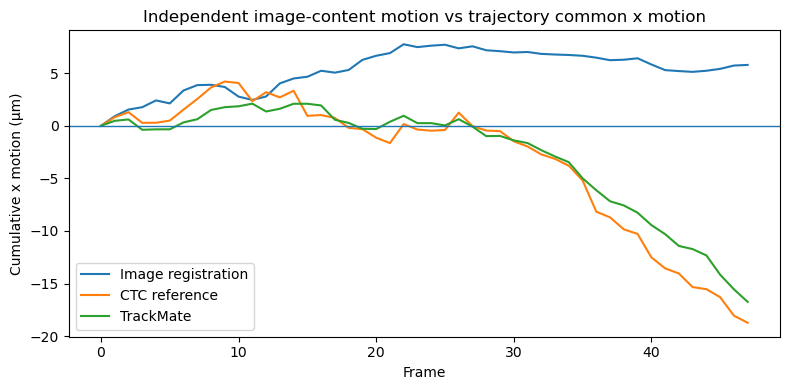

In [121]:
plt.figure(
    figsize=(8, 4)
)

plt.plot(
    image_cumulative_comparison["frame"],
    image_cumulative_comparison["image_x_um"],
    label="Image registration",
)

plt.plot(
    image_cumulative_comparison["frame"],
    image_cumulative_comparison["ctc_x_um"],
    label="CTC reference",
)

plt.plot(
    image_cumulative_comparison["frame"],
    image_cumulative_comparison["trackmate_x_um"],
    label="TrackMate",
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xlabel("Frame")
plt.ylabel("Cumulative x motion (µm)")
plt.title(
    "Independent image-content motion vs trajectory common x motion"
)
plt.legend()
plt.tight_layout()
plt.show()

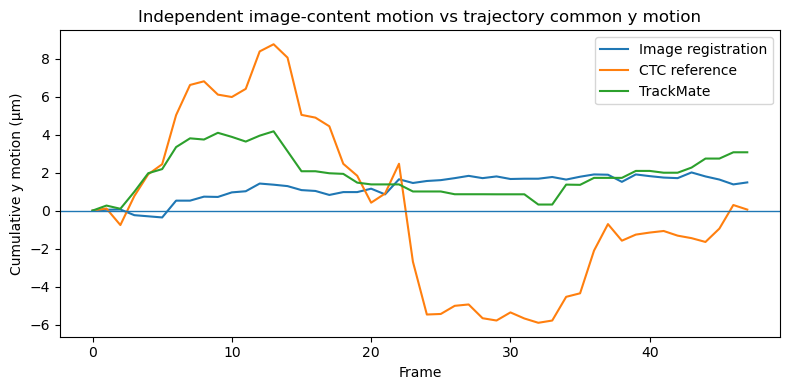

In [122]:
plt.figure(
    figsize=(8, 4)
)

plt.plot(
    image_cumulative_comparison["frame"],
    image_cumulative_comparison["image_y_um"],
    label="Image registration",
)

plt.plot(
    image_cumulative_comparison["frame"],
    image_cumulative_comparison["ctc_y_um"],
    label="CTC reference",
)

plt.plot(
    image_cumulative_comparison["frame"],
    image_cumulative_comparison["trackmate_y_um"],
    label="TrackMate",
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xlabel("Frame")
plt.ylabel("Cumulative y motion (µm)")
plt.title(
    "Independent image-content motion vs trajectory common y motion"
)
plt.legend()
plt.tight_layout()
plt.show()

### Independent image-motion diagnostic

A limited whole-image phase-correlation analysis was performed as an
independent diagnostic of apparent global image translation.

The image-registration sign convention was first validated on a synthetic
translated image before being applied to the microscopy sequence.

The frame-to-frame image-motion estimates showed only modest correlations with
the trajectory-derived population common motion.

More importantly, cumulative image motion did not reproduce the strong
negative-x trajectory trend.

At the final frame:

- image-registration cumulative x motion was approximately +5.79 µm;
- CTC trajectory common x motion was approximately -18.74 µm;
- TrackMate trajectory common x motion was approximately -16.75 µm.

The cumulative x correlations between image registration and the two tracking
sources were negative rather than strongly positive.

Therefore, the trajectory-derived negative-x common motion is **not
independently reproduced as a simple rigid whole-image translation**.

This weakens a simple microscope/stage-drift interpretation of the trajectory
signal.

However, the result does not establish that the common trajectory motion is
necessarily biological. The fluorescence images are dominated by moving and
deforming cells, and whole-image phase correlation may itself be an imperfect
estimator of technical stage translation in such data.

The appropriate conclusion is therefore:

**negative-x population common motion is highly robust across two independent
trajectory reconstructions, but its physical origin remains unresolved and is
not independently validated as microscope/stage drift by whole-image
registration.**

In [123]:
phase8a_final_numeric_summary = pd.DataFrame(
    [
        {
            "analysis": "Phase 5 CTC tau=1",
            "raw_value": 0.946288,
            "comoving_value": 0.640837,
            "interpretation": "raw > co-moving",
        },
        {
            "analysis": "Phase 5 CTC tau=2",
            "raw_value": 1.013269,
            "comoving_value": 0.684427,
            "interpretation": "raw > co-moving",
        },
        {
            "analysis": "Phase 5 CTC tau=4",
            "raw_value": 1.278303,
            "comoving_value": 0.688485,
            "interpretation": "raw > co-moving",
        },
        {
            "analysis": "Phase 6 CTC reduced features",
            "raw_value": 0.090433,
            "comoving_value": 0.090019,
            "interpretation": "neither above null q95",
        },
        {
            "analysis": "Phase 7 CTC logistic",
            "raw_value": 0.659320,
            "comoving_value": 0.415218,
            "interpretation": "raw above paired null only",
        },
        {
            "analysis": "Phase 7 CTC RBF",
            "raw_value": 0.655819,
            "comoving_value": 0.442893,
            "interpretation": "raw above paired null only",
        },
        {
            "analysis": "Final cumulative x motion",
            "raw_value": float(
                final_image_motion[
                    "image_x_um"
                ]
            ),
            "comoving_value": float(
                final_image_motion[
                    "ctc_x_um"
                ]
            ),
            "interpretation":
                "image registration vs CTC common motion",
        },
    ]
)

display(
    phase8a_final_numeric_summary
)

,analysis,raw_value,comoving_value,interpretation
0,Phase 5 CTC tau=1,0.946288,0.640837,raw > co-moving
1,Phase 5 CTC tau=2,1.013269,0.684427,raw > co-moving
2,Phase 5 CTC tau=4,1.278303,0.688485,raw > co-moving
3,Phase 6 CTC reduced features,0.090433,0.090019,neither above null q95
4,Phase 7 CTC logistic,0.659320,0.415218,raw above paired null only
5,Phase 7 CTC RBF,0.655819,0.442893,raw above paired null only
6,Final cumulative x motion,5.790000,-18.735017,image registration vs CTC common motion


In [124]:
# --------------------------------------------------
# Phase 5
# --------------------------------------------------

phase8a_phase5_ordering = (
    phase5_common_motion_effect.loc[
        phase5_common_motion_effect[
            "tracking_source"
        ].eq("CTC reference"),
        "raw_minus_comoving",
    ]
    > 0
)

assert phase8a_phase5_ordering.all()


# --------------------------------------------------
# Phase 6
# --------------------------------------------------

assert (
    ~ctc_sequence_null_comparison[
        "above_null_q95"
    ]
).all()


# --------------------------------------------------
# Phase 7 logistic
# --------------------------------------------------

ctc_logistic_raw_above_null = bool(
    ctc_logistic_null_comparison.loc[
        ctc_logistic_null_comparison[
            "representation"
        ].eq("raw"),
        "above_null_q95",
    ].iloc[0]
)

ctc_logistic_comoving_above_null = bool(
    ctc_logistic_null_comparison.loc[
        ctc_logistic_null_comparison[
            "representation"
        ].eq("comoving"),
        "above_null_q95",
    ].iloc[0]
)

assert ctc_logistic_raw_above_null
assert not ctc_logistic_comoving_above_null


# --------------------------------------------------
# Phase 7 reversal decomposition
# --------------------------------------------------

even_auc_values = (
    ctc_parity_logistic_results.loc[
        ctc_parity_logistic_results[
            "feature_space"
        ].eq("even_step_difference"),
        "mean_roc_auc",
    ]
)

assert np.allclose(
    even_auc_values,
    0.5,
    atol=1e-12,
)

assert (
    np.abs(
        ctc_full_vs_odd_comparison[
            "full_minus_odd_auc"
        ]
    )
    < 0.01
).all()


# --------------------------------------------------
# Phase 7 nonlinear full-vs-odd contrast
# --------------------------------------------------

assert (
    ~ctc_rbf_contrast_summary[
        "above_null_q95"
    ]
).all()


# --------------------------------------------------
# Image diagnostic
# --------------------------------------------------

assert np.isfinite(
    image_tracking_agreement[
        [
            "pearson_r",
            "mae_um",
            "median_abs_error_um",
            "mean_difference_um",
        ]
    ].to_numpy()
).all()

assert np.isfinite(
    image_cumulative_comparison[
        [
            "image_x_um",
            "image_y_um",
            "ctc_x_um",
            "ctc_y_um",
            "trackmate_x_um",
            "trackmate_y_um",
        ]
    ].to_numpy()
).all()


print(
    "Phase 8A integrated scientific validation: PASSED"
)

Phase 8A integrated scientific validation: PASSED


## Final Phase 8A scientific synthesis

### Phase 8A — CTC Gold-Reference Tracking Validation

Phase 8A tested whether the major motion and time-direction findings obtained
from TrackMate trajectories depended critically on the TrackMate trajectory
reconstruction.

The CTC `01_GT/TRA` annotations were used as an independent gold/reference
tracking source. They were treated as a tracking reference, not as absolute
physical ground truth for cell position, microscope drift, or irreversibility.

### 1. Tracking reconstruction is not identical

The CTC annotations produced 15 continuous reference tracks and 428
track-frame observations.

Comparison with TrackMate showed substantial correspondence but also
fragmentation/restart behavior, track-source differences in temporal coverage,
and localization differences.

Therefore, TrackMate and CTC do not represent identical trajectory
reconstructions of the same images.

### 2. The broad negative-x population motion is tracking-source robust

Despite these reconstruction differences, CTC and TrackMate independently
produced a very similar cumulative negative-x population common-motion signal.

This demonstrates that the broad directional-x structure is not merely created
by TrackMate fragmentation or one particular trajectory-linking algorithm.

The y component was substantially less reproducible across tracking sources.

### 3. Common-motion correction affects displacement asymmetry in both sources

The Phase 5 single-displacement spatial-inversion analysis was reproduced using
the exact historical estimator.

For CTC, raw asymmetry exceeded co-moving asymmetry at τ = 1, 2, and 4.

This ordering remained stable under:

- common cross-source bandwidths;
- 0.5×, 1×, and 2× KDE bandwidth sensitivity;
- and paired track-level bootstrap resampling.

Thus, the conclusion that population-level common motion contributes strongly
to displacement inversion asymmetry is tracking-source robust.

However, absolute asymmetry magnitudes and some null-calibrated residual
co-moving results differed between TrackMate and CTC.

Therefore, the direction of the common-motion effect is robust, while the
exact estimator magnitude is tracking-source sensitive.

### 4. Reduced two-step temporal asymmetry remains a null result

The exact Phase 6 two-step analysis was reproduced on CTC.

CTC provided 398 exact consecutive two-step sequences. The paired valid-turn
analysis contained 392 sequences from all 15 reference tracks.

Neither raw nor co-moving reduced-feature sequence asymmetry exceeded its
time-reversal-symmetrized null 95th percentile.

Therefore, the central null-calibrated Phase 6 conclusion survives independent
tracking reconstruction:

**no detectable two-step time-reversal asymmetry beyond the tested
finite-sample/KDE background was found in the reduced representation.**

This does not prove that the underlying cellular dynamics are time reversible.

### 5. The raw Phase 7 classifier signal also reproduces, but it is directional

The full four-dimensional raw CTC sequence produced above-null
forward-versus-reversed logistic classification performance, while the
co-moving representation did not.

This reproduces the central TrackMate pattern.

However, reversal-parity decomposition showed that the full classifier was
essentially identical to an odd-only classifier based on

`d1 + d2 = r(t+2) - r(t)`,

the net two-frame displacement.

The reversal-even component was exactly chance-level.

The single pre-specified RBF-SVM sensitivity analysis reached the same
conclusion. The complete four-dimensional sequence did not outperform the
odd-only representation relative to the paired null.

Therefore, the reproducible raw classification signal is best explained by
net directional displacement rather than additional internal two-step sequence
ordering.

### 6. Whole-image registration does not validate a simple stage-drift model

A limited phase-correlation analysis estimated apparent frame-to-frame motion
directly from the microscopy images.

The cumulative image-registration motion did not reproduce the strong
negative-x trajectory common-motion trend.

Thus, the negative-x trajectory signal is robust across tracking algorithms
but is not independently reproduced as a simple rigid translation of the
whole fluorescence image.

This weakens a simple microscope/stage-drift interpretation.

However, the physical origin remains unresolved because fluorescence images
are dominated by moving and deforming cells, making whole-image registration
an imperfect discriminator between technical translation and collective
biological motion.

### Overall Phase 8A conclusion

The major scientific conclusions through Phases 5–7 are not artifacts of the
TrackMate trajectory reconstruction.

The strongest tracking-source-robust findings are:

1. a broad negative-x population directional component exists in both
   TrackMate and CTC trajectory reconstructions;
2. removing common population motion reduces single-displacement spatial
   inversion asymmetry;
3. the reduced two-step sequence analysis remains null-calibrated negative;
4. raw forward/reverse classifier information is reproducible but is explained
   by reversal-odd net displacement;
5. there is no convincing evidence, in the tested two-step representations,
   for additional sequence-order time-direction information beyond directional
   motion.

Tracking-source-sensitive quantities include exact asymmetry magnitudes,
residual co-moving null results, classifier magnitudes, and the y component of
population common motion.

The physical origin of the shared directional component remains unresolved.

Phase 8A therefore strengthens confidence that the project's principal
qualitative conclusions do not depend on TrackMate reconstruction while also
placing tighter limits on claims about intrinsic temporal irreversibility and
microscope drift.

In [125]:
print(
    "Phase 8A — CTC Gold-Reference Tracking Validation"
)

print(
    "Scientific analyses completed:"
)

print(
    "- CTC trajectory reconstruction and validation"
)

print(
    "- CTC vs TrackMate tracking comparison"
)

print(
    "- common-motion comparison"
)

print(
    "- Phase 5 replication and robustness"
)

print(
    "- Phase 6 replication and null calibration"
)

print(
    "- limited Phase 7 logistic/RBF diagnostic"
)

print(
    "- independent whole-image motion diagnostic"
)

print()

print(
    "Phase 8A scientific analysis: COMPLETE"
)

Phase 8A — CTC Gold-Reference Tracking Validation
Scientific analyses completed:
- CTC trajectory reconstruction and validation
- CTC vs TrackMate tracking comparison
- common-motion comparison
- Phase 5 replication and robustness
- Phase 6 replication and null calibration
- limited Phase 7 logistic/RBF diagnostic
- independent whole-image motion diagnostic

Phase 8A scientific analysis: COMPLETE
